In [1]:
from pathlib import Path
from scipy.io import loadmat
import sys
import os

# Use the actual notebook working directory
nb_dir = Path.cwd()
print(f"Current notebook path: {nb_dir}")

# Optionally add the notebook dir (for local-only imports)
if str(nb_dir) not in sys.path:
    sys.path.insert(0, str(nb_dir))
    print(f"Added {nb_dir} to sys.path")

# Critically: add the repository root so top-level packages like 'utils' are importable
# Notebook path: /home/luky/skola/KalmanNet-main/navigation NCLT dataset/linear_velocity_integration
# Repo root is two levels up: /home/luky/skola/KalmanNet-main
repo_root = nb_dir.parents[1]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    print(f"Added {repo_root} to sys.path")

Current notebook path: /home/luky/skola/KalmanNet-main/navigation NCLT dataset/NCLT_linear_model_test
Added /home/luky/skola/KalmanNet-main/navigation NCLT dataset/NCLT_linear_model_test to sys.path
Added /home/luky/skola/KalmanNet-main to sys.path


In [2]:
import torch
import matplotlib.pyplot as plt
from utils import trainer
from utils import utils
from Systems import DynamicSystem
import Filters
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


Načítám data z: ../preprocessed_NCLT_trajectory-2012-01-22-angle-update...
✅ Data úspěšně načtena.
  -> Celkový počet vzorků: 5208
  -> Input Shape (Měření): torch.Size([5208, 4]) ... [GPS_X, ODO_VX, GPS_Y, ODO_VY]
  -> Target Shape (GT):    torch.Size([5208, 4]) ... [PX, VX, PY, VY]


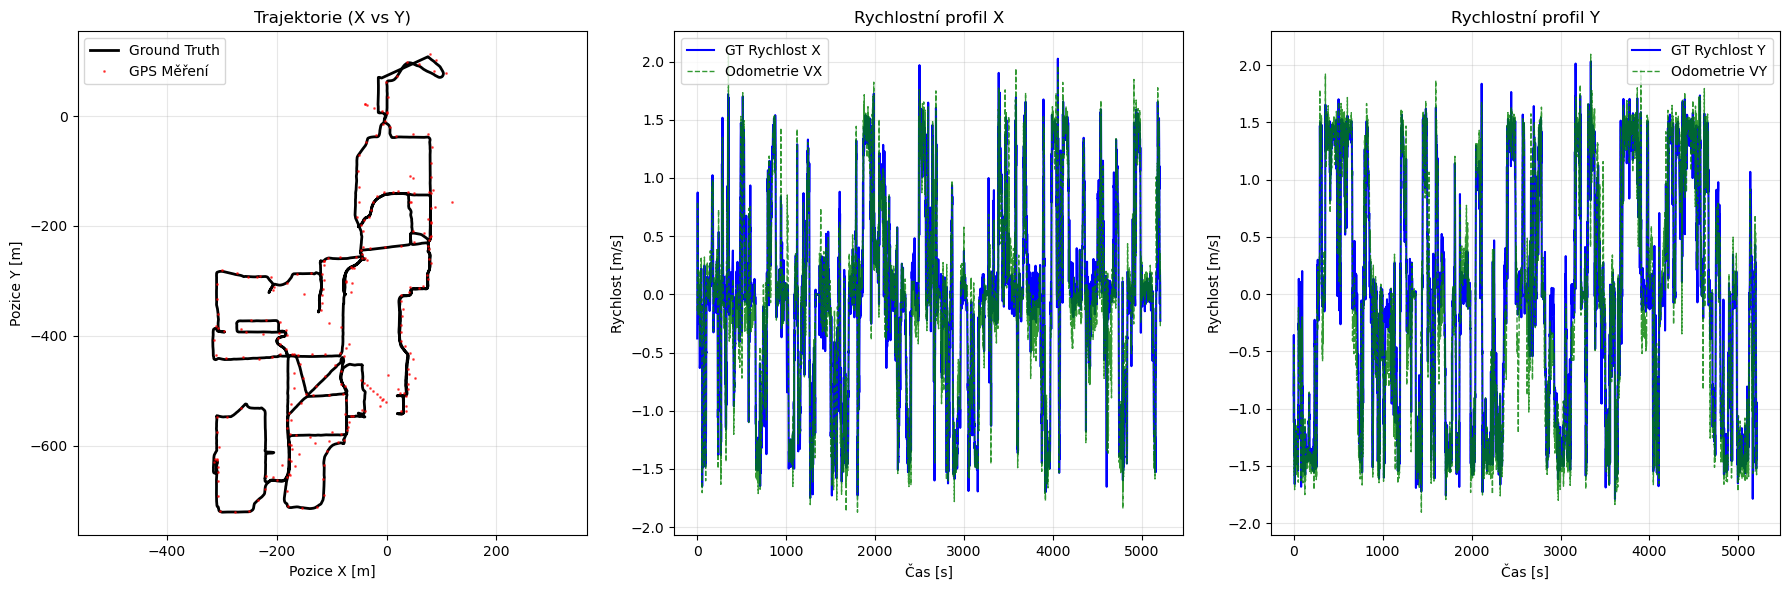

In [3]:
import torch
import matplotlib.pyplot as plt
import os
import numpy as np

# === 1. KONFIGURACE ===
# Cesta k adresáři, který vytvořil preprocess skript
data_dir = '../preprocessed_NCLT_trajectory-2012-01-22-angle-update'

print(f"Načítám data z: {data_dir}...")

try:
    # === 2. NAČTENÍ DAT (.pt soubory) ===
    # Data jsou uložena jako list slovníků [{'ground_truth': ..., 'filtered_gps': ...}]
    # filtered_gps zde ale obsahuje náš 4D vektor [GPS_X, ODO_VX, GPS_Y, ODO_VY]
    
    train_data = torch.load(os.path.join(data_dir, 'train.pt'))
    val_data = torch.load(os.path.join(data_dir, 'val.pt'))
    test_data = torch.load(os.path.join(data_dir, 'test.pt'))

    # Extrakce tensorů (předpokládáme 1 trajektorii v listu)
    X_train, Y_train = train_data[0]['ground_truth'], train_data[0]['filtered_gps']
    X_val, Y_val     = val_data[0]['ground_truth'],   val_data[0]['filtered_gps']
    X_test, Y_test   = test_data[0]['ground_truth'],  test_data[0]['filtered_gps']

    # Spojení zpět do jedné sekvence pro vizualizaci celé trajektorie
    X_full = torch.cat([X_train, X_val, X_test], dim=0)
    Y_full = torch.cat([Y_train, Y_val, Y_test], dim=0)

    print(f"✅ Data úspěšně načtena.")
    print(f"  -> Celkový počet vzorků: {X_full.shape[0]}")
    print(f"  -> Input Shape (Měření): {Y_full.shape} ... [GPS_X, ODO_VX, GPS_Y, ODO_VY]")
    print(f"  -> Target Shape (GT):    {X_full.shape} ... [PX, VX, PY, VY]")

    # === 3. VIZUALIZACE ===
    # Převedeme na numpy pro matplotlib
    gt_np = X_full.numpy()
    meas_np = Y_full.numpy()
    time_steps = np.arange(len(gt_np)) # Předpoklad 1Hz (DT=1.0)

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    # --- A) Trajektorie (X-Y) ---
    # Ground Truth (Sloupce 0 a 2 v Targetu)
    ax[0].plot(gt_np[:, 0], gt_np[:, 2], 'k-', linewidth=2, label='Ground Truth')
    
    # GPS Měření (Sloupce 0 a 2 v Inputu)
    # Vykreslíme jen každý 20. bod, aby graf nebyl přeplácaný
    ax[0].plot(meas_np[::20, 0], meas_np[::20, 2], 'r.', markersize=2, alpha=0.6, label='GPS Měření')

    ax[0].set_title('Trajektorie (X vs Y)')
    ax[0].set_xlabel('Pozice X [m]')
    ax[0].set_ylabel('Pozice Y [m]')
    ax[0].axis('equal')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # --- B) Rychlost X (VX) ---
    # GT Rychlost (Sloupec 1 v Targetu)
    ax[1].plot(time_steps, gt_np[:, 1], 'b-', linewidth=1.5, label='GT Rychlost X')
    # ODO Rychlost (Sloupec 1 v Inputu)
    ax[1].plot(time_steps, meas_np[:, 1], 'g--', linewidth=1, alpha=0.8, label='Odometrie VX')

    ax[1].set_title('Rychlostní profil X')
    ax[1].set_xlabel('Čas [s]')
    ax[1].set_ylabel('Rychlost [m/s]')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    # --- C) Rychlost Y (VY) ---
    # GT Rychlost (Sloupec 3 v Targetu)
    ax[2].plot(time_steps, gt_np[:, 3], 'b-', linewidth=1.5, label='GT Rychlost Y')
    # ODO Rychlost (Sloupec 3 v Inputu)
    ax[2].plot(time_steps, meas_np[:, 3], 'g--', linewidth=1, alpha=0.8, label='Odometrie VY')

    ax[2].set_title('Rychlostní profil Y')
    ax[2].set_xlabel('Čas [s]')
    ax[2].set_ylabel('Rychlost [m/s]')
    ax[2].legend()
    ax[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"❌ CHYBA: Adresář '{data_dir}' nebo soubory .pt nenalezeny.")
    print("Spustil jsi předtím skript 'preprocess_NCLT_trajectory_linear_test.py'?")
except Exception as e:
    print(f"❌ CHYBA: {e}")

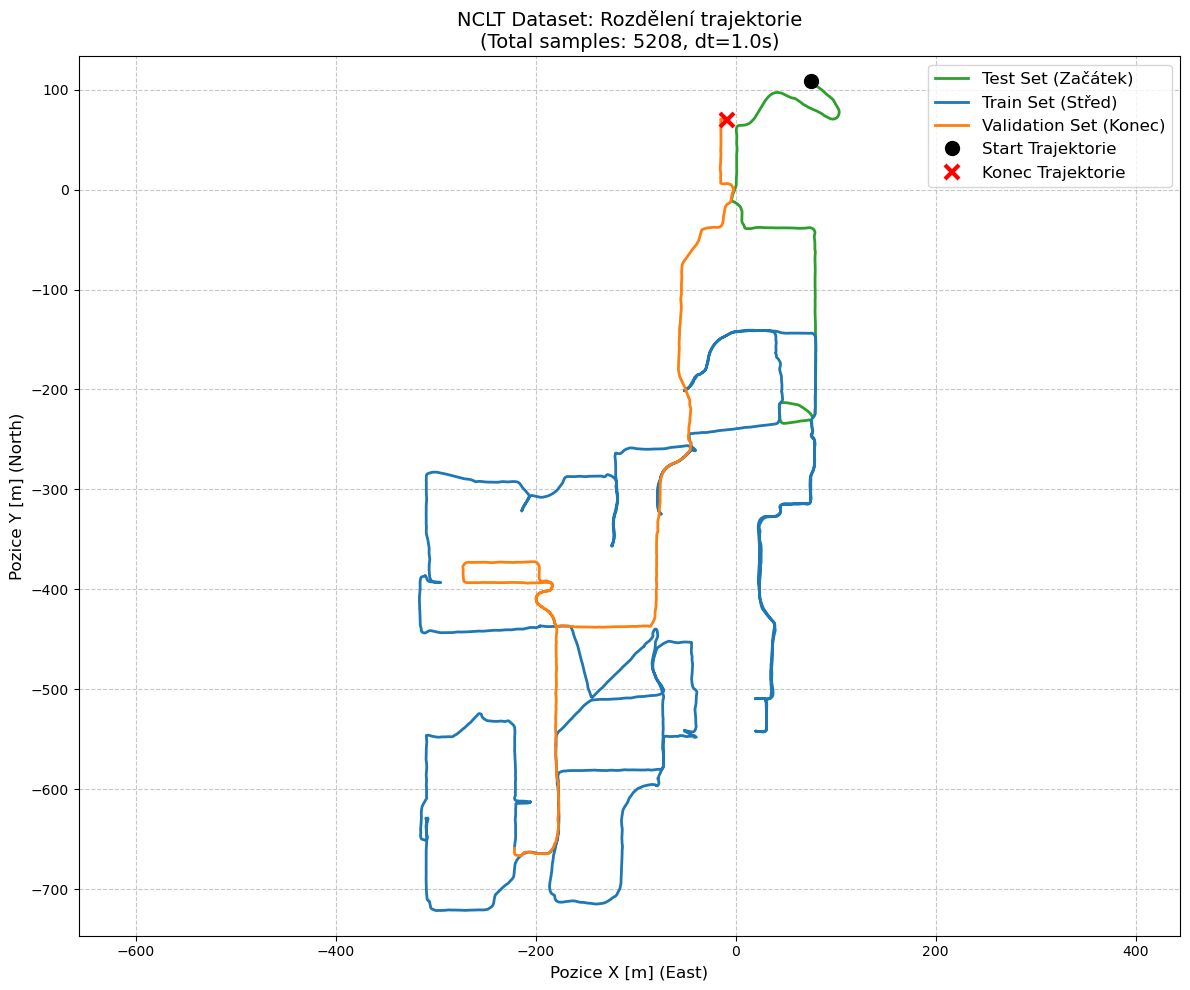

In [4]:
import matplotlib.pyplot as plt

# === VIZUALIZACE ROZDĚLENÍ DATASETU ===

plt.figure(figsize=(12, 10))

# Používáme proměnné z předchozího kroku: X_train, X_val, X_test
# Konverze .numpy() funguje, pokud jsou tensory na CPU (což po načtení torch.load obvykle jsou)

# 1. Testovací část (Podle tvého 'save_splits' je Test na začátku - prvních cca 10%)
plt.plot(X_test[:, 0].numpy(), 
         X_test[:, 2].numpy(), 
         label='Test Set (Začátek)', color='#2ca02c', linewidth=2) # Zelená

# 2. Trénovací část (Navazuje na Test - středních 70%)
plt.plot(X_train[:, 0].numpy(), 
         X_train[:, 2].numpy(), 
         label='Train Set (Střed)', color='#1f77b4', linewidth=2) # Modrá

# 3. Validační část (Navazuje na Train - koncových 20%)
plt.plot(X_val[:, 0].numpy(), 
         X_val[:, 2].numpy(), 
         label='Validation Set (Konec)', color='#ff7f0e', linewidth=2) # Oranžová

# Zvýraznění začátku a konce celé trajektorie
# Začátek je v prvním bodě Testovací sady
plt.plot(X_test[0, 0], X_test[0, 2], 'ko', markersize=10, label='Start Trajektorie')

# Konec je v posledním bodě Validační sady
plt.plot(X_val[-1, 0], X_val[-1, 2], 'rx', markersize=10, markeredgewidth=3, label='Konec Trajektorie')

# Formátování grafu
# N_samples a DT vezmeme z kontextu předchozího cellu nebo definujeme
N_samples = X_full.shape[0] 
DT = 1.0 

plt.title(f'NCLT Dataset: Rozdělení trajektorie\n(Total samples: {N_samples}, dt={DT}s)', fontsize=14)
plt.xlabel('Pozice X [m] (East)', fontsize=12)
plt.ylabel('Pozice Y [m] (North)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')  # Důležité: Aby mapa nebyla deformovaná

plt.tight_layout()
plt.show()

# Model definition

In [5]:
import torch
import math
import Systems 

# Nastavení zařízení
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################
### Design Parameters ###
### (OPTIMALIZOVANÉ)  ###
#########################

# 1. Rozměry
# Stav: [px, vx, py, vy]
m = 4 
n = 4 
delta_t = 1.0 

# 2. Dynamika (F)
# x_{t+1} = x_t + v_t * dt
F_dim = torch.tensor([[1.0, delta_t],
                      [0.0, 1.0]])

F_design = torch.block_diag(F_dim, F_dim).float()

# 3. Měření (H)
H_design = torch.eye(n).float()

# ==========================================
# 4. Šum procesu (Q) - OPTIMALIZOVÁNO
# ==========================================
# Hodnota z Optuny (MSE ~760)
# q_scale = 0.00006806
# q_scale = 0.00013203

# grid search:
q_scale = 0.00012224

# Používáme kinematický model (Discrete White Noise Acceleration), 
# který byl použit v optimalizačním skriptu.
# Blok pro jednu dimenzi (pozice + rychlost):
Q_block_val = torch.tensor([
    [(delta_t**3)/3, (delta_t**2)/2],
    [(delta_t**2)/2,  delta_t      ]
]) * q_scale

# Výsledná Q pro [px, vx, py, vy]
Q_design = torch.block_diag(Q_block_val, Q_block_val).float()


# ==========================================
# 5. Šum měření (R) - OPTIMALIZOVÁNO
# ==========================================
# Hodnoty z Optuny
# var_gps = 38.370833  # Vysoká nedůvěra v GPS (odpovídá realitě NCLT)
# var_odo = 0.000560   # Extrémní důvěra v Odometrii
# var_gps = 39.321669
# var_odo = 0.00057
#grid search:
var_gps = 39.275433
var_odo = 0.000566


# Pořadí stavů: [Pos_X, Vel_X, Pos_Y, Vel_Y]
# Takže střídáme: [GPS, ODO, GPS, ODO]
R_design = torch.tensor([
    [var_gps, 0.0,     0.0,     0.0],
    [0.0,     var_odo, 0.0,     0.0],
    [0.0,     0.0,     var_gps, 0.0],
    [0.0,     0.0,     0.0,     var_odo]
]).float()

# 6. Počáteční podmínky
m1x_0 = torch.zeros(m, 1).float()
m2x_0 = torch.diag(torch.tensor([10.0, 1.0, 10.0, 1.0])) # Velká nejistota v pozici, menší v rychlosti

print("\nInicializuji systém dle OPTIMALIZOVANÝCH parametrů (NCLT)...")
print(f"Dimenze stavu: {m}, Dimenze měření: {n}")
print(f"Q scale: {q_scale}")
print(f"R diagonal: {torch.diagonal(R_design)}")

# === INICIALIZACE SYSTÉMŮ ===

sys_true = Systems.DynamicSystem(
    state_dim=m, obs_dim=n,
    Ex0=m1x_0, P0=m2x_0,
    Q=Q_design, R=R_design,
    F=F_design, H=H_design,
    device=device
)

sys_model = Systems.DynamicSystem(
    state_dim=m, obs_dim=n,
    Ex0=m1x_0, P0=m2x_0,
    Q=Q_design, R=R_design,
    F=F_design, H=H_design,
    device=device
)

print("... Systémy inicializovány.")
print("POZOR: Tento model očekává pořadí stavů [px, vx, py, vy].")


Inicializuji systém dle OPTIMALIZOVANÝCH parametrů (NCLT)...
Dimenze stavu: 4, Dimenze měření: 4
Q scale: 0.00012224
R diagonal: tensor([3.9275e+01, 5.6600e-04, 3.9275e+01, 5.6600e-04])
... Systémy inicializovány.
POZOR: Tento model očekává pořadí stavů [px, vx, py, vy].


In [6]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# === 1. KONFIGURACE ===
# Dynamicky zjistíme délku testovací sady z proměnné X_test (kterou máme z minula)
# Pokud by X_test neexistovalo, kód spadne, ale to by znamenalo, že jsi nenačetl data.
TEST_SEQ_LEN = X_test.shape[0] 

TRAIN_SEQ_LEN = 50    # Délka sekvence pro trénink (krátká okna)
VAL_SEQ_LEN = 200     # Validace po delších úsecích
STRIDE = 10           # Posun okna (překryv)
BATCH_SIZE = 128      # Velikost dávky

def create_sequences(X, Y, seq_len, stride=1):
    """
    Rozseká dlouhé tenzory [Total_Len, Dim] na sekvence [N_seq, Seq_Len, Dim].
    """
    xs = []
    ys = []
    num_samples = X.shape[0]
    
    # Pokud je seq_len větší než data (např. u testu), vezmeme prostě to, co máme
    if seq_len > num_samples:
        seq_len = num_samples
    
    for i in range(0, num_samples - seq_len + 1, stride):
        x_seq = X[i : i+seq_len, :]
        y_seq = Y[i : i+seq_len, :]
        xs.append(x_seq)
        ys.append(y_seq)
        
    if len(xs) == 0:
        # Fallback: Pokud by data byla kratší než seq_len, vrátíme prázdné nebo 1 kus
        return X.unsqueeze(0), Y.unsqueeze(0)
        
    return torch.stack(xs), torch.stack(ys)

def clean_sequences(X_seq, Y_seq, name="Dataset"):
    """
    Filtruje sekvence, které obsahují jakékoliv NaN nebo Inf hodnoty.
    """
    if X_seq.numel() == 0:
        print(f"⚠️ {name}: Prázdný vstup!")
        return X_seq, Y_seq

    # Zkontrolujeme NaN/Inf pro každou sekvenci zvlášť
    is_nan_x = torch.isnan(X_seq).reshape(X_seq.shape[0], -1).any(dim=1)
    is_inf_x = torch.isinf(X_seq).reshape(X_seq.shape[0], -1).any(dim=1)
    
    is_nan_y = torch.isnan(Y_seq).reshape(Y_seq.shape[0], -1).any(dim=1)
    is_inf_y = torch.isinf(Y_seq).reshape(Y_seq.shape[0], -1).any(dim=1)
    
    invalid_mask = is_nan_x | is_inf_x | is_nan_y | is_inf_y
    valid_mask = ~invalid_mask
    
    X_clean = X_seq[valid_mask]
    Y_clean = Y_seq[valid_mask]
    
    n_dropped = invalid_mask.sum().item()
    if n_dropped > 0:
        print(f"⚠️ {name}: Odstraněno {n_dropped} vadných sekvencí (NaN/Inf). Zbývá: {len(X_clean)}")
    else:
        print(f"✅ {name}: Data jsou čistá. ({len(X_clean)} sekvencí)")
        
    return X_clean, Y_clean

print("--- ZPRACOVÁNÍ DAT ---")

# === 2. TVORBA SEKVENCÍ A PŘETYPOVÁNÍ ===
# OPRAVA PROMĚNNÝCH: Používáme X_train, Y_train atd. místo train_target/input
# X = Ground Truth, Y = Měření (Input)
print(f"Generuji sekvence (Test délka: {TEST_SEQ_LEN})...")

# Train: Krátká okna s překryvem
train_X_raw, train_Y_raw = create_sequences(X_train.float(), Y_train.float(), TRAIN_SEQ_LEN, STRIDE)

# Val: Delší okna (bez překryvu)
val_X_raw, val_Y_raw = create_sequences(X_val.float(), Y_val.float(), VAL_SEQ_LEN, VAL_SEQ_LEN)

# Test: Jedna dlouhá sekvence (pro kontinuální vyhodnocení)
# Stride = TEST_SEQ_LEN zajistí, že dostaneme právě jeden (nebo málo) dlouhých kusů
test_X_raw, test_Y_raw = create_sequences(X_test.float(), Y_test.float(), TEST_SEQ_LEN, TEST_SEQ_LEN)

# === 3. ČIŠTĚNÍ DAT (NAN/INF FILTER) ===
print("\nFiltruji NaN hodnoty...")
train_X_seq, train_Y_seq = clean_sequences(train_X_raw, train_Y_raw, "Train")
val_X_seq, val_Y_seq = clean_sequences(val_X_raw, val_Y_raw, "Val")
test_X_seq, test_Y_seq = clean_sequences(test_X_raw, test_Y_raw, "Test")

# === 4. VYTVOŘENÍ DATALOADERŮ ===
print("\nVytvářím DataLoadery...")
# Train: Shuffle=True (Důležité pro trénink)
train_dataset = TensorDataset(train_X_seq, train_Y_seq)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Val/Test: Shuffle=False (Abychom viděli průběh)
val_dataset = TensorDataset(val_X_seq, val_Y_seq)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(test_X_seq, test_Y_seq)
# Pro test batch_size=1, protože máme jednu obří sekvenci (nebo pár velkých)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"\n✅ HOTOVO. Připraveno k tréninku.")
print(f"Train batches: {len(train_loader)} (Batch shape: {next(iter(train_loader))[0].shape})")
print(f"Test batches:  {len(test_loader)} (Seq len: {test_X_seq.shape[1]})")

--- ZPRACOVÁNÍ DAT ---
Generuji sekvence (Test délka: 522)...

Filtruji NaN hodnoty...
✅ Train: Data jsou čistá. (360 sekvencí)
✅ Val: Data jsou čistá. (5 sekvencí)
✅ Test: Data jsou čistá. (1 sekvencí)

Vytvářím DataLoadery...

✅ HOTOVO. Připraveno k tréninku.
Train batches: 3 (Batch shape: torch.Size([128, 50, 4]))
Test batches:  1 (Seq len: 522)


In [7]:
import torch
import numpy as np
from MDM.MDM_functions import MDM_nullO_LTI, pinv, Ksi_fun, baseMatrix_fun, Upsilon_2_fun, kron2_vec, kron2_mat

from tqdm import tqdm

class KalmanFilter:
    """
    Kalmanův filtr pro t-invaritantní systém s lineární dynamikou.
    (Původní implementace beze změn)
    """
    def __init__(self,model):
        self.device = model.Q.device
        self.model = model
        self.Ex0 = model.Ex0
        self.P0 = model.P0
        self.F = model.F
        self.H = model.H
        self.Q = model.Q
        self.R = model.R
        self.state_dim = self.F.shape[0]
        self.obs_dim = self.H.shape[0]

        # Interní stav pro online použití
        self.x_predict_current = None
        self.P_predict_current = None
        self.reset(model.Ex0, model.P0)

    def reset(self, Ex0, P0):
        self.x_predict_current = Ex0.clone().detach().reshape(self.state_dim, 1)
        self.P_predict_current = P0.clone().detach()

    def predict_step(self, x_filtered, P_filtered):
        x_predict = self.F @ x_filtered
        P_predict = self.F @ P_filtered @ self.F.T + self.Q
        return x_predict, P_predict

    def update_step(self, x_predict, y_t, P_predict):
        y_t = y_t.reshape(self.obs_dim, 1)
        innovation = self.compute_innovation(y_t, x_predict)
        K = self.compute_kalman_gain(P_predict)
        x_filtered = x_predict + K @ innovation
        I = torch.eye(self.state_dim, device=self.device)
        P_filtered = (I - K @ self.H) @ P_predict @ (I - K @ self.H).T + K @ self.R @ K.T 
        return x_filtered, P_filtered, K, innovation

    def compute_kalman_gain(self, P_predict):
        return P_predict @ self.H.T @ torch.linalg.inv(self.H @ P_predict @ self.H.T + self.R)
    
    def compute_innovation(self, y_t, x_predict):
        return y_t - self.H @ x_predict
    
    def step(self, y_t):
        x_filtered, P_filtered, _, _ = self.update_step(self.x_predict_current, y_t, self.P_predict_current)
        x_predict_next, P_predict_next = self.predict_step(x_filtered, P_filtered)
        self.x_predict_current = x_predict_next
        self.P_predict_current = P_predict_next
        return x_filtered, P_filtered

    def process_sequence(self, y_seq, Ex0=None, P0=None):
            seq_len = y_seq.shape[0]
            x_filtered_history = torch.zeros(seq_len, self.state_dim, device=self.device)
            P_filtered_history = torch.zeros(seq_len, self.state_dim, self.state_dim, device=self.device)
            kalman_gain_history = torch.zeros(seq_len, self.state_dim, self.obs_dim, device=self.device)
            innovation_history = torch.zeros(seq_len, self.obs_dim, device=self.device)

            if Ex0 is None: Ex0 = self.Ex0
            if P0 is None: P0 = self.P0
            x_predict_k = Ex0.clone().detach().reshape(self.state_dim, 1)
            P_predict_k = P0.clone().detach()
            
            for k in range(seq_len):
                x_filtered, P_filtered, K, innovation = self.update_step(x_predict_k, y_seq[k], P_predict_k)
                x_predict_k_plus_1, P_predict_k_plus_1 = self.predict_step(x_filtered, P_filtered)
                x_predict_k = x_predict_k_plus_1
                P_predict_k = P_predict_k_plus_1
                x_filtered_history[k] = x_filtered.squeeze()
                P_filtered_history[k] = P_filtered
                kalman_gain_history[k] = K
                innovation_history[k] = innovation.squeeze()

            return {
                'x_filtered': x_filtered_history,
                'P_filtered': P_filtered_history,
                'Kalman_gain': kalman_gain_history,
                'innovation': innovation_history
            }

class AdaptiveKalmanFilter_online:
    def __init__(self, model, mdm_L=4, mdm_version=1, lambda_rls=0.995, q_init=1e-3, init_sigma_rls_value=10.0, alpha_nom=None):
        """
        Adaptivní KF (Semi-weighted Recursive verze - Sw-Re).
        Tato třída provádí online identifikaci matic Q a R.
        """
        self.kf = KalmanFilter(model)
        self.device = model.Q.device
        
        self.mdm_L = mdm_L
        self.mdm_version = mdm_version
        self.lambda_rls = lambda_rls
        self.q_init_val = q_init
        self.init_sigma_val = init_sigma_rls_value
        self.alpha_nom_val = alpha_nom
        self.nw = self.kf.F.shape[0] # Dimenze stavového šumu (W)
        self.nv = self.kf.H.shape[0] # Dimenze šumu měření (V)
        
        self.T = T = 1.0
        T2 = (T**2) / 2.0
        T3 = (T**3) / 3.0
        
        self.Q_template = np.array([
            [T3, T2, 0,  0],
            [T2, T,  0,  0],
            [0,  0,  T3, T2],
            [0,  0,  T2, T]
        ])
        self.vec_Q_template = self.Q_template[np.triu_indices(self.nw)][:, np.newaxis]
        self.n_params_Q_full = (self.nw * (self.nw + 1)) // 2 
        self.n_params_R_full = (self.nv * (self.nv + 1)) // 2
        self.n_params_R_reduced = 2
        
        self.T_R_matrix = np.zeros((self.n_params_R_full, self.n_params_R_reduced))
        self.T_R_matrix[0, 0] = 1.0 
        self.T_R_matrix[7, 0] = 1.0 
        self.T_R_matrix[4, 1] = 1.0 
        self.T_R_matrix[9, 1] = 1.0 
        
        # 3. INICIALIZACE RLS
        self.n_params = 1 + self.n_params_R_reduced

        self.q_init = self.q_init_val
        
        R0 = model.R.cpu().numpy()
        r1_init = R0[0,0]
        r2_init = R0[1,1]
        
        self.alpha_est = np.array([self.q_init, r1_init, r2_init], dtype=np.float64)
        
        # BEZPEČNÉ NAČTENÍ alpha_nom (Zůstáváme u 1D pole)
        if self.alpha_nom_val is not None:
            self.alpha_nom = np.array(self.alpha_nom_val, dtype=np.float64)
        else:
            self.alpha_nom = np.copy(self.alpha_est)

        # P_RLS
        sigma_q  = (self.alpha_nom[0] * self.init_sigma_val)**2 + 1e-12
        sigma_r1 = (self.alpha_nom[1] * self.init_sigma_val)**2 + 1e-12
        sigma_r2 = (self.alpha_nom[2] * self.init_sigma_val)**2 + 1e-12
        self.Sigma_RLS = np.diag([sigma_q, sigma_r1, sigma_r2])
        # Buffery
        self.z_buffer = []
        self.u_buffer = []
        self.Upsilon_2 = None

    def _get_upsilon(self):
        """
        Pomocná funkce pro získání matice Upsilon.
        Tato matice je čistě strukturální (záleží jen na dimenzích) a slouží
        k manipulaci s Kroneckerovými součiny v rámci MDM teorie.
        Počítá se jen jednou.
        """
        if self.Upsilon_2 is None:
            w2b = [baseMatrix_fun(self.nw, 1)] 
            v2b = [baseMatrix_fun(self.nv, 1)] 
            self.Upsilon_2 = Upsilon_2_fun(w2b, v2b, self.mdm_L)
        return self.Upsilon_2

    def _reconstruct_qr_from_alpha2(self, alpha_2):
        """
        KLÍČOVÁ FUNKCE: Převod vektoru parametrů zpět na matice.
        
        Vstup: alpha_2 (vektor délky n_params)
        Výstup: Matice Q a R
        
        Logika:
        1. Rozdělí vektor alpha na část pro Q a část pro R.
        2. Vytvoří prázdné matice.
        3. Vyplní horní trojúhelník (triu) hodnotami z vektoru.
        4. Zkopíruje hodnoty i do dolního trojúhelníku (symetrizace),
           protože kovarianční matice musí být symetrická (Q_ij = Q_ji).
        """
        # Kolik prvků patří matici Q?
        q_len = (self.nw * (self.nw + 1)) // 2
        
        # Rozdělení vektoru
        alpha_q = alpha_2[:q_len]
        alpha_r = alpha_2[q_len:]
        
        # Rekonstrukce Q
        Q_est = np.zeros((self.nw, self.nw))
        i, j = np.triu_indices(self.nw)
        # Vyplnění horního trojúhelníku
        Q_est[i, j] = alpha_q
        # Symetrizace: Q[j, i] = Q[i, j]
        # Tímto říkáme, že kovariance mezi stavem 1 a 2 je stejná jako mezi 2 a 1.
        Q_est[j, i] = alpha_q
        
        # Rekonstrukce R (stejný princip)
        R_est = np.zeros((self.nv, self.nv))
        i, j = np.triu_indices(self.nv)
        R_est[i, j] = alpha_r
        R_est[j, i] = alpha_r
        
        return Q_est, R_est

    def step_adaptive(self, y_t, u_t=None):
        """
        Jeden krok adaptivního filtru s UNWEIGHTED RLS.
        """
        # --- 1. Update Bufferu (Posuvné okno) ---
        y_np = y_t.cpu().numpy().squeeze()
        if y_np.ndim == 0: y_np = np.expand_dims(y_np, axis=0)
        
        if u_t is not None:
            u_np = u_t.cpu().numpy().squeeze()
            if u_np.ndim == 0: u_np = np.expand_dims(u_np, axis=0)
        else:
            u_np = np.zeros(1)

        self.z_buffer.append(y_np)
        self.u_buffer.append(u_np)
        
        # Udržování fixní délky okna L (FIFO fronta)
        if len(self.z_buffer) > self.mdm_L:
            self.z_buffer.pop(0)
            self.u_buffer.pop(0)

        # --- 2. Identifikace Q a R (RLS) ---
        # Spustí se pouze, pokud je buffer plný (dost dat pro MDM)
        if len(self.z_buffer) == self.mdm_L:
            try:
                z_window = np.array(self.z_buffer)
                u_window = np.array(self.u_buffer)
                
                # Získání matic systému
                F_np = self.kf.F.cpu().numpy()
                H_np = self.kf.H.cpu().numpy()
                G_np = np.zeros((self.nw, u_window.shape[1])) # matice pro vstup u 
                E_np = np.eye(self.nw) # matice pro šum w
                D_np = np.eye(self.nv) # matice pro šum v
                nz_np = np.array([self.nv])

                # MDM: Výpočet rezidua a regresoru
                # r_k: Vektor reziduí, který nese informaci o šumu v datech
                # Awv_matrix: Pomocná matice popisující dynamiku systému v okně
                r_list, Awv_matrix = MDM_nullO_LTI(
                    self.mdm_L, F_np, G_np, E_np, nz_np, H_np, D_np, 
                    z_window, u_window, self.mdm_version
                )
                r_k = r_list[0]
                
                nr = r_k.shape[0]
                Ksi = Ksi_fun(nr) # Unifikační matice (vybírá unikátní prvky ze symetrické matice)
                
                # Pozorování pro RLS (y_rls):
                # Vychází z vnějšího součinu rezidua (r_k * r_k^T), což je "okamžitá kovariance".
                # kron2_vec to převede na vektor a Ksi vybere unikátní prvky.
                # OPRAVA TADY: Zploštění y_rls
                y_rls = (Ksi @ kron2_vec(r_k)).flatten()
                
                # Regresní matice (H_rls):
                # Popisuje lineární vztah mezi parametry (Q, R) a pozorováním (kovariancí rezidua).
                Upsilon = self._get_upsilon()
                H_full = Ksi @ kron2_mat(Awv_matrix) @ Upsilon

                # 1. Rozdělení na Q část a R část
                H_Q_part_full = H_full[:, :self.n_params_Q_full] 
                H_R_part_full = H_full[:, self.n_params_Q_full:]
                
                # 2. Transformace Q (10 sloupců -> 1 sloupec)
                h_q_new = H_Q_part_full @ self.vec_Q_template

                # 3. NOVÉ: Transformace R (10 sloupců -> 2 sloupce)
                # Výsledek má tvar [N, 2]. První sloupec je citlivost na r1, druhý na r2.
                H_R_new = H_R_part_full @ self.T_R_matrix

                # 4. Sestavení finálního H_rls
                H_rls = np.hstack([h_q_new, H_R_new])
                
                # =========================================================
                # VÁŽENÉ RLS PŘES NORMALIZACI DAT (Stabilní a fungující)
                # =========================================================
                
                # 2. Výpočet vah na základě nominálních hodnot (Zploštění)
                y_expected_nom = np.abs(H_rls @ self.alpha_nom).flatten()
                weights = y_expected_nom + 1e-8
                
                # 3. Normalizace rovnic (vydělení vahami)
                y_rls_norm = y_rls / weights
                H_rls_norm = H_rls / weights[:, np.newaxis]
                
                # 4. RLS Update na znormalizovaných datech (Omega je teď Identita)
                dim_obs_rls = H_rls_norm.shape[0]
                Omega_norm = np.eye(dim_obs_rls)

                S = H_rls_norm @ self.Sigma_RLS @ H_rls_norm.T + Omega_norm
                
                # S je nyní skvěle podmíněná, pinv funguje perfektně
                K_gain = self.Sigma_RLS @ H_rls_norm.T @ np.linalg.pinv(S)
                
                error = y_rls_norm - H_rls_norm @ self.alpha_est
                self.alpha_est = self.alpha_est + K_gain @ error
                
                I_p = np.eye(self.n_params)
                self.Sigma_RLS = (I_p - K_gain @ H_rls_norm) @ self.Sigma_RLS / self.lambda_rls
                # =========================================================
                
                # --- REKONSTRUKCE MATIC ---
                
                q_est = self.alpha_est[0]
                # Q nesmí klesnout pod 1e-5, jinak KF přestane naslouchat odometrii!
                q_safe = max(q_est, 1e-5) 
                Q_new = q_safe * self.Q_template
                
                # 2. R_GPS (Ať si klidně letí nahoru, ale nesmí klesnout pod realitu)
                # Dle grafů je minimální slušné R kolem 10-20. 
                r1_est = max(self.alpha_est[1], 10.0) 
                
                # 3. R_ODO (Zabránění nedůvěře k odometrii)
                r2_est = self.alpha_est[2]
                r2_est = max(r2_est, 1e-4) # Spodní hranice (aby se nedělilo nulou)
                # DŮLEŽITÉ: Strop! Dle grafů je nejhorší chyba odo 2 m/s (variance 4). 
                # Nedovolte filtru odhadnout R_ODO vyšší než např. 0.5, jinak odometrii odřízne!
                r2_est = min(r2_est, 0.005) 
                
                R_new = np.diag([r1_est, r2_est, r1_est, r2_est])
                
                # Update KF
                self.kf.Q = torch.from_numpy(Q_new).float().to(self.device)
                self.kf.R = torch.from_numpy(R_new).float().to(self.device)
                
            except Exception as e:
                import traceback
                print(f"Chyba v RLS aktualizaci:")
                traceback.print_exc()
                pass

        # --- 3. Filtrace ---
        # Provedeme standardní krok Kalmanova filtru s aktuálními Q a R
        x_filt, P_filt = self.kf.step(y_t)
        return x_filt, P_filt, self.kf.Q, self.kf.R

    def process_sequence_adaptively(self, y_seq, u_seq=None, Ex0=None, P0=None):
        """
        Pomocná metoda pro simulaci běhu na celé sekvenci dat.
        """
        seq_len = y_seq.shape[0]
        
        # 1. Kompletní reset (zapomeneme vše z předchozích běhů)
        self.__init__(
            self.kf.model, 
            self.mdm_L, 
            self.mdm_version, 
            self.lambda_rls,
            q_init=self.q_init_val,                # <--- Předat dál
            init_sigma_rls_value=self.init_sigma_val,
            alpha_nom=self.alpha_nom_val # <--- TOTO CHYBĚLO: Předat parametr při resetu!
        )

        # 2. Nastavení počátečních podmínek
        if Ex0 is None: Ex0 = self.kf.model.Ex0
        if P0 is None: P0 = self.kf.model.P0

        # 3. Reset vnitřního KF
        self.kf.reset(Ex0, P0)
        
        self.z_buffer = []
        self.u_buffer = []

        x_hist = torch.zeros(seq_len, self.kf.state_dim, device=self.device)
        P_hist = torch.zeros(seq_len, self.kf.state_dim, self.kf.state_dim, device=self.device)
        Q_hist = []
        R_hist = []

        for k in tqdm(range(0,seq_len), desc="Processing sequence adaptively"):
            y_t = y_seq[k]
            u_t = u_seq[k] if u_seq is not None else None
            
            x, P, Q_curr, R_curr = self.step_adaptive(y_t, u_t)
            
            x_hist[k] = x.squeeze()
            P_hist[k] = P
            Q_hist.append(Q_curr.clone().detach())
            R_hist.append(R_curr.clone().detach())
            
        results_dict = {
            'x_filtered': x_hist,
            'P_filtered': P_hist
        }
        
        return results_dict, Q_hist, R_hist

Běžím na zařízení: cpu

--- NAČÍTÁNÍ DAT ---
Hledám čisté úseky (bez outlierů) v trénovacích datech...
VAROVÁNÍ: Nenašel se úsek. Zkusím uvolnit kritéria (max_error=5.0, min_length=200)...
Nalezeno 1 vhodných úseků pro trénink.

--- FÁZE 1: UČENÍ NOMINÁLNÍCH PARAMETRŮ (ITERATIVNÍ RLS) ---
Trénuji na úseku 1 (délka 398 kroků)...


Processing sequence adaptively: 100%|██████████| 398/398 [00:12<00:00, 32.75it/s]


  -> Výsledek pro úsek 1: q=0.000132, r_gps=8.54, r_odo=0.000570

🌟 ZLATÝ STANDARD (Baseline) NALEZEN 🌟
Q (scale): 0.000132
R (GPS):   8.5400
R (ODO):   0.000570

--- FÁZE 2: TESTOVÁNÍ NA OSTRÉ TRAJEKTORII (Délka: 522) ---
Spouštím KF True (s původními Grid-Search parametry)...


Spouštím Standardní KF (s naučenými Baseline parametry)...


Spouštím AKF MDM...


Processing sequence adaptively: 100%|██████████| 522/522 [00:15<00:00, 33.89it/s]



VÝSLEDKY NA TESTOVACÍ TRAJEKTORII:
KF True (Grid-Search parametry) -> MSE: 144.9760 | RMSE: 12.0406 m
Standardní KF (Baseline)        -> MSE: 81.0268 | RMSE: 9.0015 m
AKF MDM (Adaptivní)             -> MSE: 54.1639 | RMSE: 7.3596 m


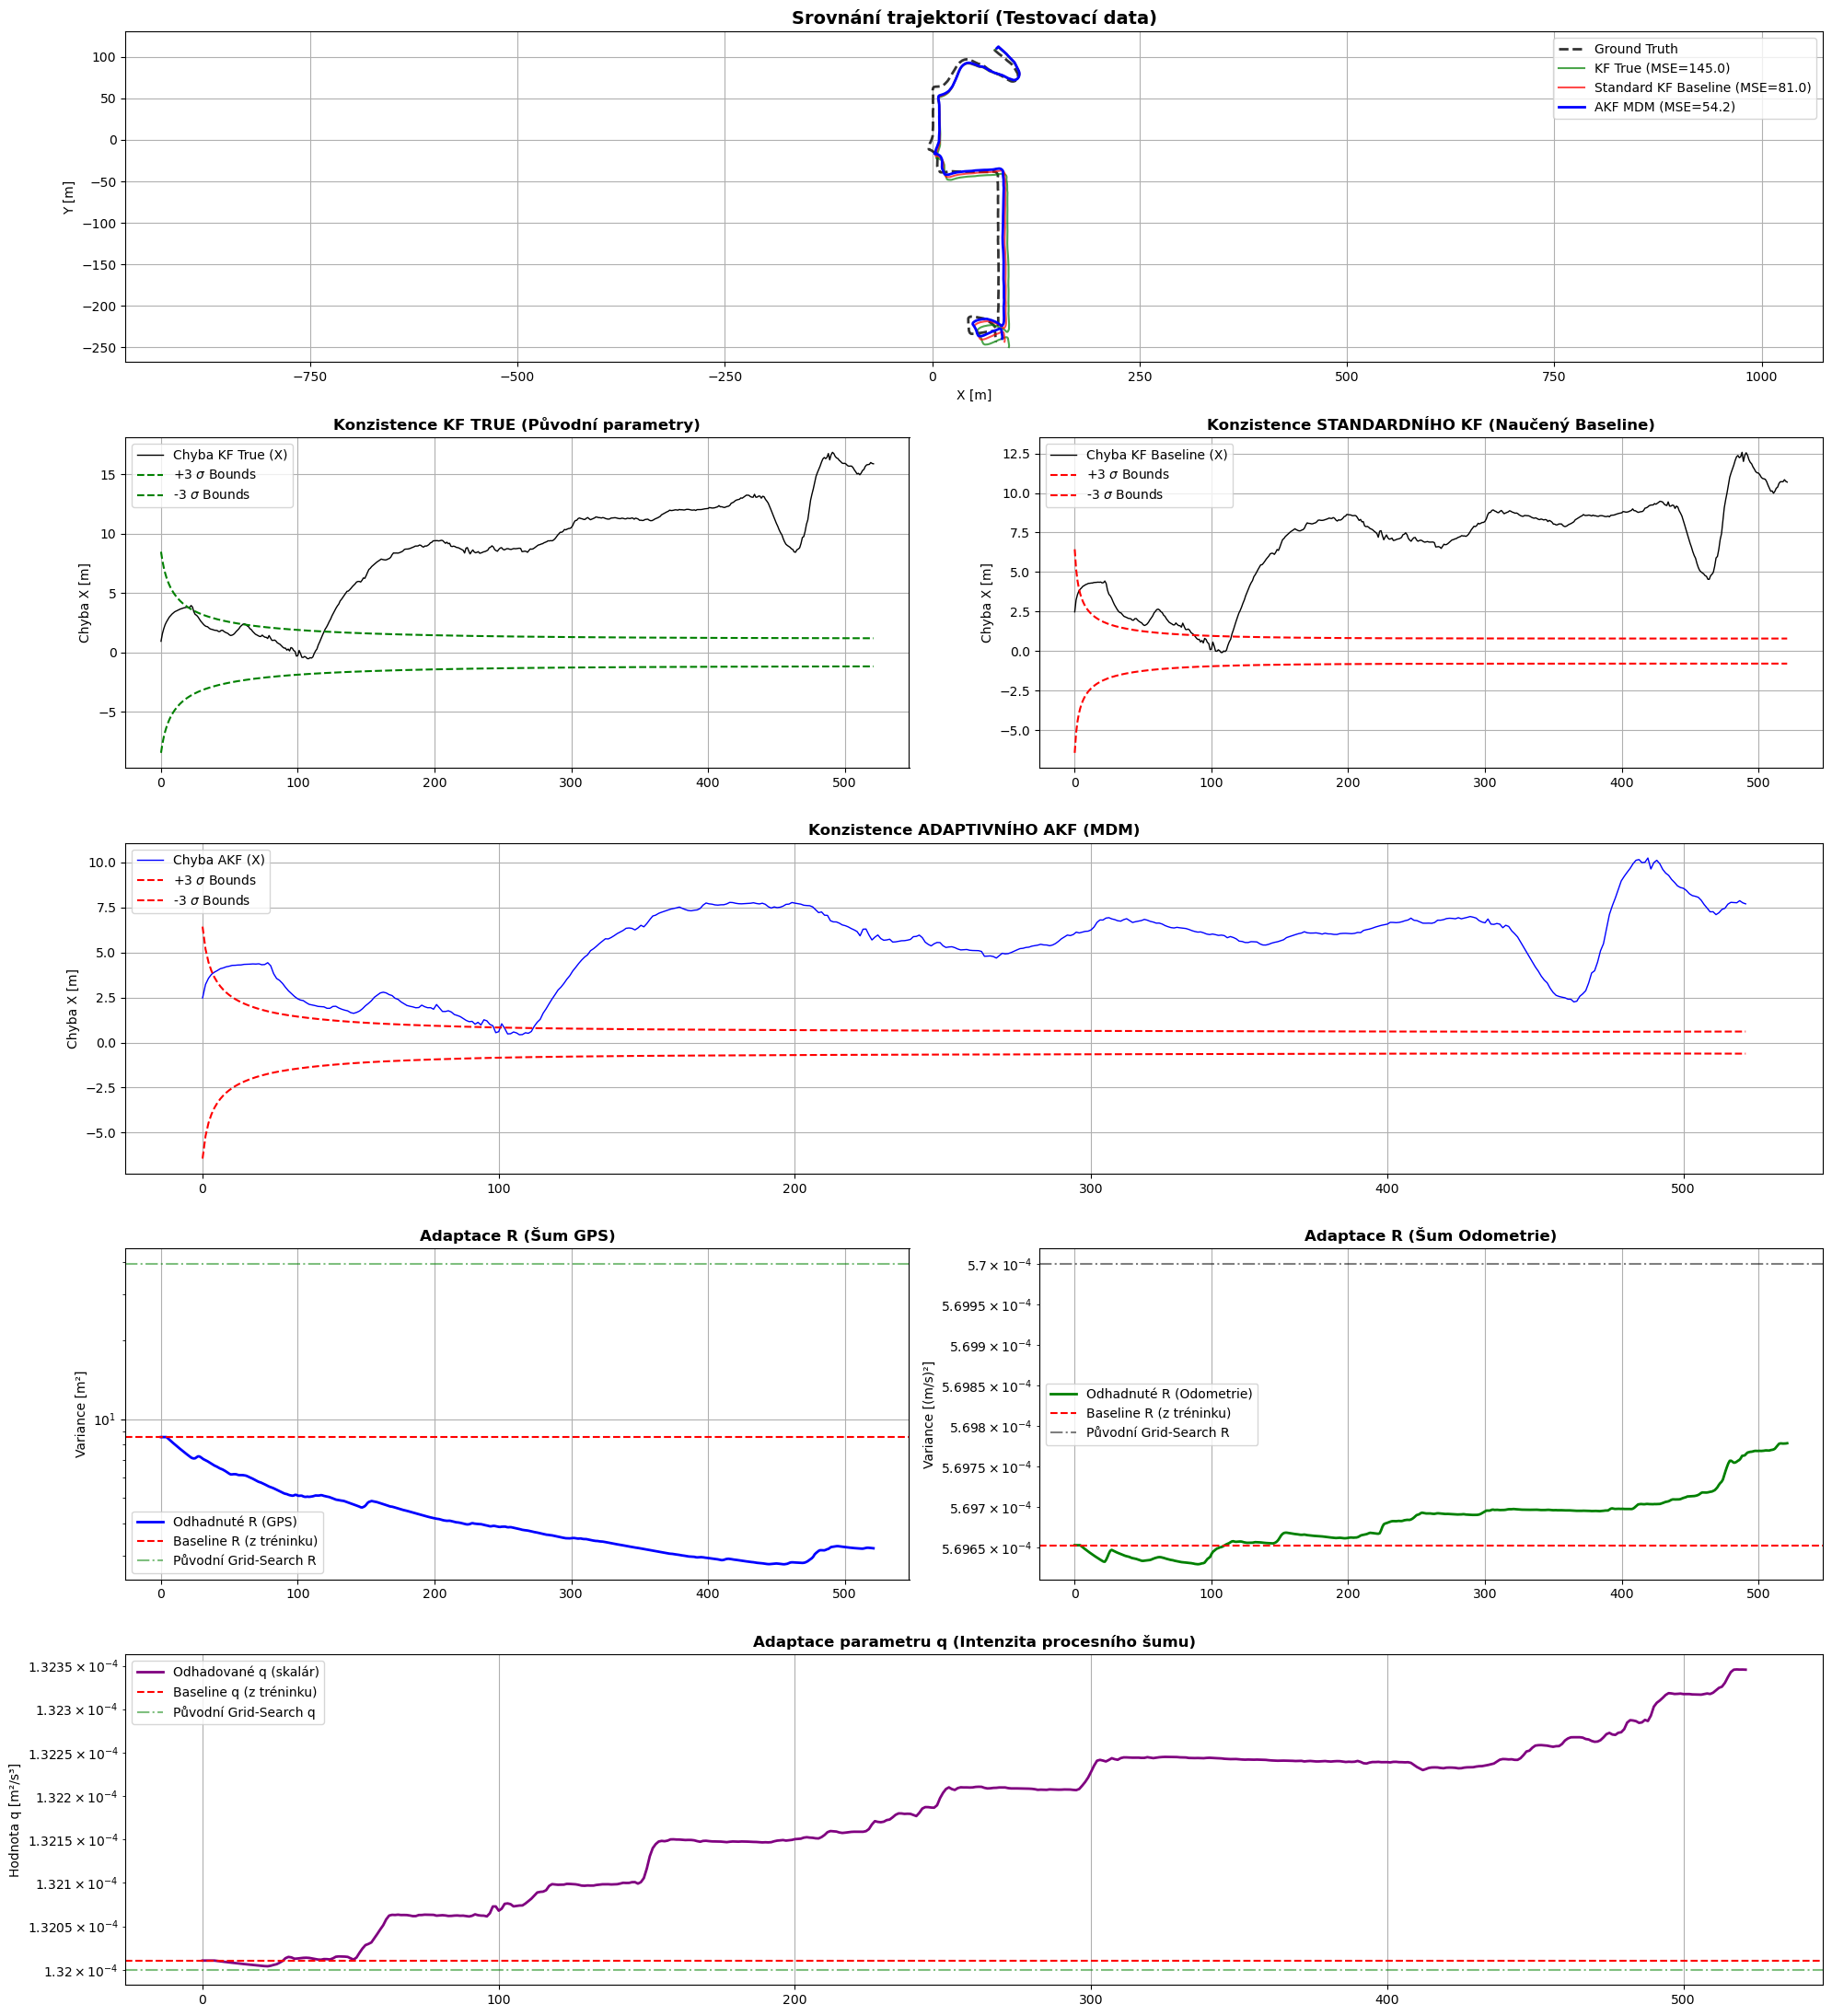

In [21]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt
import copy
import Systems
import Filters  # Tvůj modul s filtry
from tqdm import tqdm

# Vynutíme CPU pro absolutně všechno!
device = torch.device("cpu")
print(f"Běžím na zařízení: {device}")

#########################
### Design Parameters ###
#########################
m = 4 
n = 4 
delta_t = 1.0 

# Dynamika (F) a Měření (H)
F_dim = torch.tensor([[1.0, delta_t], [0.0, 1.0]], dtype=torch.float64)
F_design = torch.block_diag(F_dim, F_dim).to(device)
H_design = torch.eye(n, dtype=torch.float64).to(device)

# Úvodní hrubý nástřel šumů (Q a R) - např. z Grid Searche
q_scale_init = 0.000132
Q_block_val = torch.tensor([[(delta_t**3)/3, (delta_t**2)/2], [(delta_t**2)/2,  delta_t]], dtype=torch.float64) * q_scale_init
Q_design = torch.block_diag(Q_block_val, Q_block_val).to(device)

var_gps_init = 39.32
var_odo_init = 0.00057
R_design = torch.tensor([
    [var_gps_init, 0.0, 0.0, 0.0],
    [0.0, var_odo_init, 0.0, 0.0],
    [0.0, 0.0, var_gps_init, 0.0],
    [0.0, 0.0, 0.0, var_odo_init]
], dtype=torch.float64).to(device)

# Pevné počáteční podmínky všude
m1x_0 = torch.zeros(m, 1, dtype=torch.float64).to(device)
m2x_0 = torch.diag(torch.tensor([10.0, 1.0, 10.0, 1.0], dtype=torch.float64)).to(device)

# === INICIALIZACE SYSTÉMŮ ===
# 1. sys_true: Tento systém drží původní parametry (z Grid-Searche) a nebude se měnit
sys_true = Systems.DynamicSystem(
    state_dim=m, obs_dim=n, Ex0=m1x_0, P0=m2x_0,
    Q=Q_design.clone(), R=R_design.clone(), F=F_design, H=H_design, device=device
)

# 2. sys_model: Tento systém se ve Fázi 2 přepíše vytěženým Baseline šumem
sys_model = Systems.DynamicSystem(
    state_dim=m, obs_dim=n, Ex0=m1x_0, P0=m2x_0,
    Q=Q_design.clone(), R=R_design.clone(), F=F_design, H=H_design, device=device
)

# ==============================================================================
# 1. NAČTENÍ DAT A DETEKCE ČISTÝCH ÚSEKŮ (DATA MINING)
# ==============================================================================
print("\n--- NAČÍTÁNÍ DAT ---")
train_path = '../preprocessed_NCLT_trajectory-2012-01-22-angle-update/train.pt' 
test_path = '../preprocessed_NCLT_trajectory-2012-01-22-angle-update/test.pt' 

train_dataset = torch.load(train_path)[0]
test_dataset = torch.load(test_path)[0]

train_gt = train_dataset['ground_truth'].to(device).double()
train_meas = train_dataset['filtered_gps'].to(device).double()

test_gt = test_dataset['ground_truth'].to(device).double()
test_meas = test_dataset['filtered_gps'].to(device).double()

def find_clean_segments(gt, meas, max_error=2.0, min_length=500):
    error = torch.sqrt((meas[:, 0] - gt[:, 0])**2 + (meas[:, 2] - gt[:, 2])**2)
    valid_mask = error < max_error
    
    segments = []
    current_seg = []
    for i, is_valid in enumerate(valid_mask):
        if is_valid.item():
            current_seg.append(i)
        else:
            if len(current_seg) >= min_length:
                segments.append(current_seg)
            current_seg = []
            
    if len(current_seg) >= min_length:
        segments.append(current_seg)
        
    return segments

print("Hledám čisté úseky (bez outlierů) v trénovacích datech...")
clean_segments = find_clean_segments(train_gt, train_meas, max_error=3.0, min_length=500)

if len(clean_segments) == 0:
    print("VAROVÁNÍ: Nenašel se úsek. Zkusím uvolnit kritéria (max_error=5.0, min_length=200)...")
    clean_segments = find_clean_segments(train_gt, train_meas, max_error=5.0, min_length=200)
    
if len(clean_segments) == 0:
    print("VAROVÁNÍ: Stále nic. Zkusím extrémní uvolnění (max_error=10.0, min_length=100)...")
    clean_segments = find_clean_segments(train_gt, train_meas, max_error=10.0, min_length=100)

if len(clean_segments) == 0:
    print("KRITICKÁ CHYBA: Data jsou příliš zašuměná. Použijeme fake úsek a Grid-Search hodnoty.")
    clean_segments = [[0, 1]] 
    baseline_q, baseline_r_gps, baseline_r_odo = q_scale_init, var_gps_init, var_odo_init
    learned_params = [[baseline_q, baseline_r_gps, baseline_r_odo]]
else:
    print(f"Nalezeno {len(clean_segments)} vhodných úseků pro trénink.")

# ==============================================================================
# 2. FÁZE TRÉNINKU (ZÍSKÁNÍ NOMINÁLNÍCH PARAMETRŮ - ITERATIVNĚ)
# ==============================================================================
print("\n--- FÁZE 1: UČENÍ NOMINÁLNÍCH PARAMETRŮ (ITERATIVNÍ RLS) ---")
learned_params = []
T_sampling = 1.0
template_val_00 = (T_sampling**3) / 3.0

NUM_EPOCHS = 5 

for idx, seg in enumerate(clean_segments[:5]):
    print(f"Trénuji na úseku {idx+1} (délka {len(seg)} kroků)...")
    y_seg = train_meas[seg].double()
    init_state = train_gt[seg[0]].unsqueeze(1).double()
    current_alpha = [q_scale_init, var_gps_init, var_odo_init]
    
    for epoch in range(NUM_EPOCHS):
        akf_train = Filters.AdaptiveKalmanFilter_online(
            sys_model, mdm_L=6, lambda_rls=1.0, init_sigma_rls_value=0.01,
            alpha_nom=current_alpha
        )
        # Použití explicitních počátečních podmínek
        res_train, Q_hist_tr, R_hist_tr = akf_train.process_sequence_adaptively(y_seg, Ex0=init_state, P0=m2x_0)
        
        q_final = Q_hist_tr[-1][0, 0].item() / template_val_00
        r_gps_final = R_hist_tr[-1][0, 0].item()
        r_odo_final = R_hist_tr[-1][1, 1].item()
        
        current_alpha = [q_final, r_gps_final, r_odo_final]

    learned_params.append(current_alpha)
    print(f"  -> Výsledek pro úsek {idx+1}: q={q_final:.6f}, r_gps={r_gps_final:.2f}, r_odo={r_odo_final:.6f}")

avg_params = np.mean(learned_params, axis=0)
baseline_q, baseline_r_gps, baseline_r_odo = avg_params

print("\n🌟 ZLATÝ STANDARD (Baseline) NALEZEN 🌟")
print(f"Q (scale): {baseline_q:.6f}")
print(f"R (GPS):   {baseline_r_gps:.4f}")
print(f"R (ODO):   {baseline_r_odo:.6f}")


# ==============================================================================
# 3. PŘÍPRAVA NA TESTOVÁNÍ (AKTUALIZACE MODELU)
# ==============================================================================
Q_block_new = torch.tensor([[(delta_t**3)/3, (delta_t**2)/2], [(delta_t**2)/2,  delta_t]], dtype=torch.float64) * baseline_q
sys_model.Q = torch.block_diag(Q_block_new, Q_block_new).to(device)

sys_model.R = torch.tensor([
    [baseline_r_gps, 0.0, 0.0, 0.0],
    [0.0, baseline_r_odo, 0.0, 0.0],
    [0.0, 0.0, baseline_r_gps, 0.0],
    [0.0, 0.0, 0.0, baseline_r_odo]
], dtype=torch.float64).to(device)
exact_x0_test = test_gt[0].unsqueeze(1).double()
# ==============================================================================
# 4. FÁZE TESTOVÁNÍ NA OSTRÝCH DATECH (S OUTLIERY)
# ==============================================================================
print(f"\n--- FÁZE 2: TESTOVÁNÍ NA OSTRÉ TRAJEKTORII (Délka: {len(test_meas)}) ---")

print("Spouštím KF True (s původními Grid-Search parametry)...")
kf_true_filter = Filters.KalmanFilter(sys_true)
res_kf_true = kf_true_filter.process_sequence(test_meas.double(), Ex0=exact_x0_test, P0=m2x_0)

print("Spouštím Standardní KF (s naučenými Baseline parametry)...")
kf_filter = Filters.KalmanFilter(sys_model)
res_kf = kf_filter.process_sequence(test_meas.double(), Ex0=exact_x0_test, P0=m2x_0)

print("Spouštím AKF MDM...")
akf_filter = Filters.AdaptiveKalmanFilter_online(
    sys_model, 
    mdm_L=6, 
    mdm_version=1,
    lambda_rls=1.0,
    init_sigma_rls_value=0.01,
    alpha_nom=avg_params.tolist() 
)
res_akf, Q_hist_test, R_hist_test = akf_filter.process_sequence_adaptively(test_meas.double(), Ex0=exact_x0_test, P0=m2x_0)

# ==============================================================================
# 5. VYHODNOCENÍ METRIK
# ==============================================================================
x_est_kf_true = res_kf_true['x_filtered'].detach().cpu().numpy()
x_est_kf = res_kf['x_filtered'].detach().cpu().numpy()
x_est_akf = res_akf['x_filtered'].detach().cpu().numpy()
gt_test_np = test_gt.detach().cpu().numpy()

def calc_metrics(est, gt):
    mse_x = np.mean((est[:, 0] - gt[:, 0])**2)
    mse_y = np.mean((est[:, 2] - gt[:, 2])**2)
    total_mse = mse_x + mse_y
    rmse = np.sqrt(total_mse)
    return total_mse, rmse

mse_kf_true, rmse_kf_true = calc_metrics(x_est_kf_true, gt_test_np)
mse_kf, rmse_kf = calc_metrics(x_est_kf, gt_test_np)
mse_akf, rmse_akf = calc_metrics(x_est_akf, gt_test_np)

print("\n" + "="*60)
print(f"VÝSLEDKY NA TESTOVACÍ TRAJEKTORII:")
print(f"KF True (Grid-Search parametry) -> MSE: {mse_kf_true:.4f} | RMSE: {rmse_kf_true:.4f} m")
print(f"Standardní KF (Baseline)        -> MSE: {mse_kf:.4f} | RMSE: {rmse_kf:.4f} m")
print(f"AKF MDM (Adaptivní)             -> MSE: {mse_akf:.4f} | RMSE: {rmse_akf:.4f} m")
print("="*60)

# ==============================================================================
# 6. VIZUALIZACE 
# ==============================================================================
q_est_values = np.array([q[0, 0].item() for q in Q_hist_test]) / template_val_00
r_gps_hist = np.array([r[0, 0].item() for r in R_hist_test]) 
r_odo_hist = np.array([r[1, 1].item() for r in R_hist_test]) 

t_full = np.arange(len(test_meas))
t_akf = t_full[-len(r_gps_hist):] 

P_est_kf_true = res_kf_true['P_filtered'].detach().cpu().numpy()
P_est_kf = res_kf['P_filtered'].detach().cpu().numpy()
P_est_akf = res_akf['P_filtered'].detach().cpu().numpy()

error_x_kf_true = x_est_kf_true[:, 0] - gt_test_np[:, 0]
sigma_x_kf_true = np.sqrt(P_est_kf_true[:, 0, 0])

error_x_kf = x_est_kf[:, 0] - gt_test_np[:, 0]
sigma_x_kf = np.sqrt(P_est_kf[:, 0, 0])

error_x_akf = x_est_akf[:, 0] - gt_test_np[:, 0]
sigma_x_akf = np.sqrt(P_est_akf[:, 0, 0])

# Vytvoření mřížky pro grafy
fig = plt.figure(figsize=(20, 22))
gs = fig.add_gridspec(5, 2)

# A) Trajektorie
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(gt_test_np[:, 0], gt_test_np[:, 2], 'k--', label='Ground Truth', linewidth=2, alpha=0.8)
ax1.plot(x_est_kf_true[:, 0], x_est_kf_true[:, 2], 'g-', label=f'KF True (MSE={mse_kf_true:.1f})', linewidth=1.5, alpha=0.7)
ax1.plot(x_est_kf[:, 0], x_est_kf[:, 2], 'r-', label=f'Standard KF Baseline (MSE={mse_kf:.1f})', linewidth=1.5, alpha=0.7)
ax1.plot(x_est_akf[:, 0], x_est_akf[:, 2], 'b-', label=f'AKF MDM (MSE={mse_akf:.1f})', linewidth=2)
ax1.set_title(f'Srovnání trajektorií (Testovací data)', fontweight='bold', fontsize=14)
ax1.set_xlabel('X [m]')
ax1.set_ylabel('Y [m]')
ax1.legend()
ax1.axis('equal')
ax1.grid(True)

# B1) Konzistence KF True
ax2_kf_true = fig.add_subplot(gs[1, 0])
ax2_kf_true.plot(t_full, error_x_kf_true, 'k-', label='Chyba KF True (X)', linewidth=1)
ax2_kf_true.plot(t_full, 3*sigma_x_kf_true, 'g--', label='+3 $\sigma$ Bounds')
ax2_kf_true.plot(t_full, -3*sigma_x_kf_true, 'g--', label='-3 $\sigma$ Bounds')
ax2_kf_true.set_title('Konzistence KF TRUE (Původní parametry)', fontweight='bold')
ax2_kf_true.set_ylabel('Chyba X [m]')
ax2_kf_true.legend()
ax2_kf_true.grid(True)

# B2) Konzistence Standardní KF (Baseline)
ax2_kf = fig.add_subplot(gs[1, 1])
ax2_kf.plot(t_full, error_x_kf, 'k-', label='Chyba KF Baseline (X)', linewidth=1)
ax2_kf.plot(t_full, 3*sigma_x_kf, 'r--', label='+3 $\sigma$ Bounds')
ax2_kf.plot(t_full, -3*sigma_x_kf, 'r--', label='-3 $\sigma$ Bounds')
ax2_kf.set_title('Konzistence STANDARDNÍHO KF (Naučený Baseline)', fontweight='bold')
ax2_kf.set_ylabel('Chyba X [m]')
ax2_kf.legend()
ax2_kf.grid(True)

# B3) Konzistence AKF (MDM) - roztažený na celou šířku
ax2_akf = fig.add_subplot(gs[2, :])
ax2_akf.plot(t_full, error_x_akf, 'b-', label='Chyba AKF (X)', linewidth=1)
ax2_akf.plot(t_full, 3*sigma_x_akf, 'r--', label='+3 $\sigma$ Bounds')
ax2_akf.plot(t_full, -3*sigma_x_akf, 'r--', label='-3 $\sigma$ Bounds')
ax2_akf.set_title('Konzistence ADAPTIVNÍHO AKF (MDM)', fontweight='bold')
ax2_akf.set_ylabel('Chyba X [m]')
ax2_akf.legend()
ax2_akf.grid(True)

# C) Adaptace R
ax3 = fig.add_subplot(gs[3, 0])
ax3.plot(t_akf, r_gps_hist, 'b-', label='Odhadnuté R (GPS)', linewidth=2)
ax3.axhline(baseline_r_gps, color='r', linestyle='--', label='Baseline R (z tréninku)')
ax3.axhline(var_gps_init, color='g', linestyle='-.', alpha=0.5, label='Původní Grid-Search R')
ax3.set_title('Adaptace R (Šum GPS)', fontweight='bold')
ax3.set_ylabel('Variance [m²]')
ax3.set_yscale('log') 
ax3.legend()
ax3.grid(True)

ax4 = fig.add_subplot(gs[3, 1])
ax4.plot(t_akf, r_odo_hist, 'g-', label='Odhadnuté R (Odometrie)', linewidth=2)
ax4.axhline(baseline_r_odo, color='r', linestyle='--', label='Baseline R (z tréninku)')
ax4.axhline(var_odo_init, color='k', linestyle='-.', alpha=0.5, label='Původní Grid-Search R')
ax4.set_title('Adaptace R (Šum Odometrie)', fontweight='bold')
ax4.set_ylabel('Variance [(m/s)²]')
ax4.set_yscale('log')
ax4.legend()
ax4.grid(True)

# D) Adaptace q
ax5 = fig.add_subplot(gs[4, :])
ax5.plot(t_akf, q_est_values, 'purple', label='Odhadované q (skalár)', linewidth=2)
ax5.axhline(baseline_q, color='r', linestyle='--', label=f'Baseline q (z tréninku)')
ax5.axhline(q_scale_init, color='g', linestyle='-.', alpha=0.5, label='Původní Grid-Search q')
ax5.set_title('Adaptace parametru q (Intenzita procesního šumu)', fontweight='bold')
ax5.set_ylabel('Hodnota q [m²/s³]') 
ax5.set_yscale('log')
ax5.legend()
ax5.grid(True)

plt.tight_layout()
plt.show()

# Test s ignorováním velkých inovací

In [9]:
class KalmanFilterGated:
    def __init__(self, model):
        self.device = model.Q.device
        self.dtype = model.F.dtype
        self.model = model
        self.F, self.H, self.Q, self.R = model.F, model.H, model.Q, model.R
        self.state_dim = self.F.shape[0]
        self.obs_dim = self.H.shape[0]
        self.I = torch.eye(self.state_dim, device=self.device, dtype=self.dtype)
        self.reset(model.Ex0, model.P0)

    def reset(self, Ex0, P0):
        self.x_predict_current = Ex0.clone().detach().reshape(self.state_dim, 1)
        self.P_predict_current = P0.clone().detach()

    def step(self, y_t, gate_threshold=9.21): # 9.21 je 99% Chi-Square pro 2 stupně volnosti
        rejected = False
        if y_t is not None:
            y_t_vec = y_t.reshape(self.obs_dim, 1)
            inov = y_t_vec - self.H @ self.x_predict_current
            S = self.H @ self.P_predict_current @ self.H.T + self.R
            S_inv = torch.linalg.inv(S)
            
            # --- KOUZLO: Gating POUZE na pozici (GPS) ---
            # Vytáhneme inovace pro X a Y (indexy 0 a 2)
            inov_gps = torch.cat([inov[0:1], inov[2:3]], dim=0) # Tvar [2, 1]
            
            # Vytáhneme příslušnou submatici S pro X a Y
            S_gps = torch.zeros((2, 2), device=self.device, dtype=self.dtype)
            S_gps[0, 0] = S[0, 0]; S_gps[0, 1] = S[0, 2]
            S_gps[1, 0] = S[2, 0]; S_gps[1, 1] = S[2, 2]
            
            S_gps_inv = torch.linalg.inv(S_gps)
            mah_sq_gps = (inov_gps.T @ S_gps_inv @ inov_gps).item()
            
            # Zahazujeme pouze pokud ustřelí GPS
            if mah_sq_gps > gate_threshold:
                rejected = True

        if y_t is None or rejected:
            # PREDICT ONLY
            x_filtered = self.x_predict_current
            P_filtered = self.P_predict_current
            K = torch.zeros((self.state_dim, self.obs_dim), device=self.device, dtype=self.dtype)
        else:
            # STANDARD UPDATE
            K = self.P_predict_current @ self.H.T @ S_inv
            x_filtered = self.x_predict_current + K @ inov
            I_KH = self.I - K @ self.H
            P_filtered = I_KH @ self.P_predict_current @ I_KH.T + K @ self.R @ K.T

        # PREDICT PRO DALŠÍ KROK
        x_predict_next = self.F @ x_filtered
        P_predict_next = self.F @ P_filtered @ self.F.T + self.Q
        
        self.x_predict_current = x_predict_next
        self.P_predict_current = P_predict_next

        return x_filtered, P_filtered, K, rejected

    def process_sequence(self, y_seq, Ex0, P0, gate_threshold=50.0):
        seq_len = y_seq.shape[0]
        self.reset(Ex0, P0)
        x_hist = torch.zeros(seq_len, self.state_dim, device=self.device, dtype=self.dtype)
        P_hist = torch.zeros(seq_len, self.state_dim, self.state_dim, device=self.device, dtype=self.dtype)
        
        for k in tqdm(range(seq_len), desc="Standard KF Gated", leave=False):
            x_f, P_f, _, _ = self.step(y_seq[k], gate_threshold)
            x_hist[k] = x_f.squeeze()
            P_hist[k] = P_f
            
        return {'x_filtered': x_hist, 'P_filtered': P_hist}


--- DIAGNOSTIKA DAT (Analýza Mahalanobisovy vzdálenosti pro GPS) ---


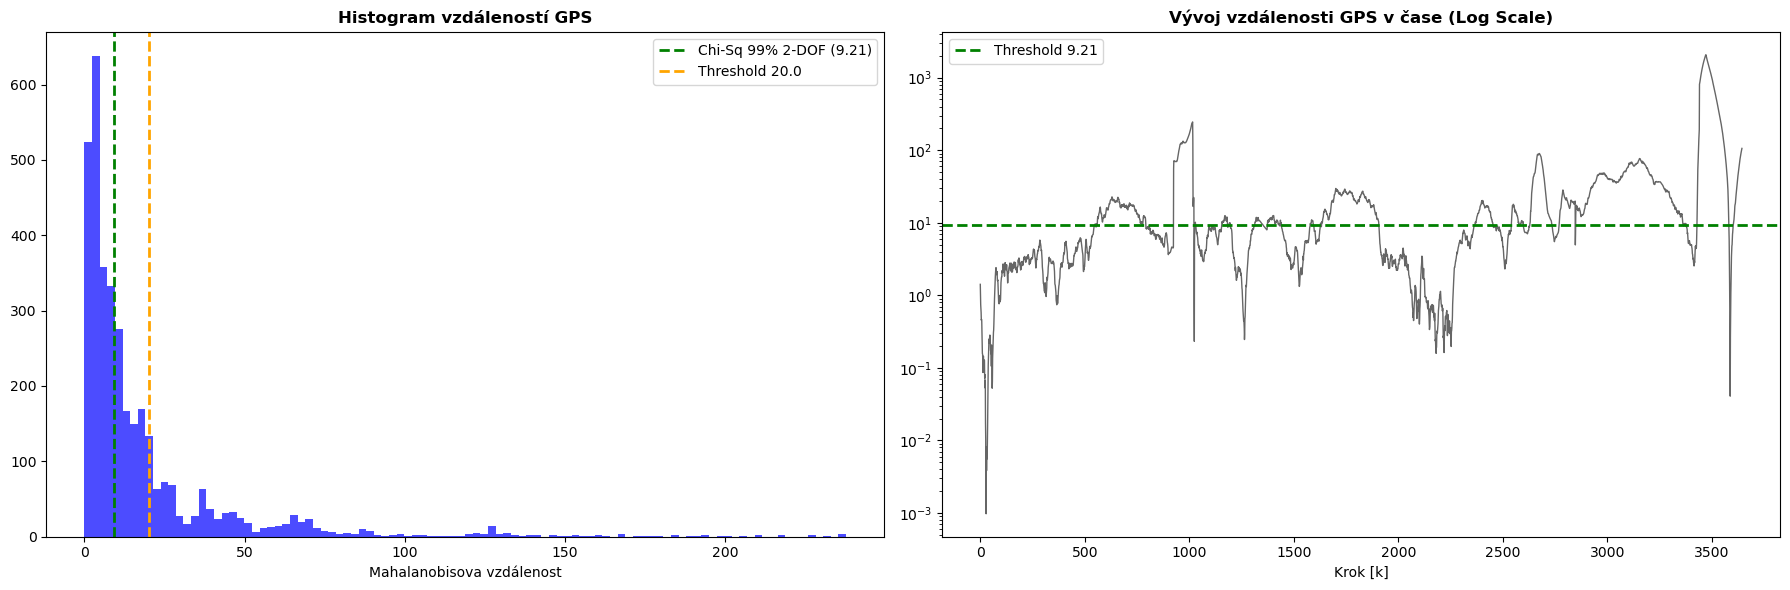


Statistika zahozených dat při různých tresholdech:
Při thresholdu 9.21 (Teorie): Zahodí se 50.21% dat
Při thresholdu 15.0:          Zahodí se 35.69% dat
Při thresholdu 20.0:          Zahodí se 26.64% dat


In [10]:
# ==============================================================================
# DIAGNOSTIKA DAT PRO SPRÁVNÉ NASTAVENÍ GATING THRESHOLDU (OPRAVENO)
# ==============================================================================
import scipy.stats as stats

print("\n--- DIAGNOSTIKA DAT (Analýza Mahalanobisovy vzdálenosti pro GPS) ---")
# Zásadní oprava: Začínáme na správných souřadnicích (train_gt[0])
diag_sys = Systems.DynamicSystem(state_dim=m, obs_dim=n, Ex0=train_gt[0].unsqueeze(1), P0=m2x_0, Q=Q_design, R=R_design, F=F_design, H=H_design, device=device)
diag_kf = KalmanFilterGated(diag_sys)

seq_len_diag = train_meas.shape[0]
mah_distances = []
TEST_THRESH = 1000000.0 

for k in tqdm(range(seq_len_diag), desc="Sběr metrik pro Gating", leave=False):
    y_t = train_meas[k].reshape(n, 1)
    inov = y_t - diag_kf.H @ diag_kf.x_predict_current
    S = diag_kf.H @ diag_kf.P_predict_current @ diag_kf.H.T + diag_kf.R
    
    # Extrakce pouze GPS částí!
    inov_gps = torch.cat([inov[0:1], inov[2:3]], dim=0)
    S_gps = torch.zeros((2, 2), device=device, dtype=diag_kf.dtype)
    S_gps[0, 0] = S[0, 0]; S_gps[0, 1] = S[0, 2]
    S_gps[1, 0] = S[2, 0]; S_gps[1, 1] = S[2, 2]
    
    S_gps_inv = torch.linalg.inv(S_gps)
    mah_sq_gps = (inov_gps.T @ S_gps_inv @ inov_gps).item()
    mah_distances.append(mah_sq_gps)
    
    diag_kf.step(train_meas[k], gate_threshold=TEST_THRESH)

mah_distances = np.array(mah_distances)

# Vizualizace
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

max_hist_val = np.percentile(mah_distances, 95) 
axs[0].hist(mah_distances[mah_distances < max_hist_val * 2], bins=100, color='blue', alpha=0.7)
axs[0].axvline(9.21, color='green', linestyle='--', lw=2, label='Chi-Sq 99% 2-DOF (9.21)')
axs[0].axvline(20.0, color='orange', linestyle='--', lw=2, label='Threshold 20.0')
axs[0].set_title('Histogram vzdáleností GPS', fontweight='bold')
axs[0].set_xlabel('Mahalanobisova vzdálenost')
axs[0].legend()

axs[1].plot(mah_distances, 'k-', lw=1, alpha=0.6)
axs[1].axhline(9.21, color='green', linestyle='--', lw=2, label='Threshold 9.21')
axs[1].set_yscale('log') 
axs[1].set_title('Vývoj vzdálenosti GPS v čase (Log Scale)', fontweight='bold')
axs[1].set_xlabel('Krok [k]')
axs[1].legend()

plt.tight_layout()
plt.show()

print("\nStatistika zahozených dat při různých tresholdech:")
print(f"Při thresholdu 9.21 (Teorie): Zahodí se {(mah_distances > 9.21).mean() * 100:.2f}% dat")
print(f"Při thresholdu 15.0:          Zahodí se {(mah_distances > 15.0).mean() * 100:.2f}% dat")
print(f"Při thresholdu 20.0:          Zahodí se {(mah_distances > 20.0).mean() * 100:.2f}% dat")

Běžím na zařízení: cpu

--- FÁZE 1: UČENÍ NA KOMPLETNÍCH DATECH (Díky Gatingu bez rizika) ---
Epocha 1/5...


Epocha 2/5...


Epocha 3/5...


Epocha 4/5...


Epocha 5/5...



🌟 ZLATÝ STANDARD NALEZEN PŘÍMO Z HRUBÝCH DAT 🌟
Q (scale): 0.007656
R (GPS):   2.8848
R (ODO):   0.061148

--- FÁZE 2: TESTOVÁNÍ NA OSTRÉ TRAJEKTORII ---
Spouštím Standardní KF Baseline (s Gatingem)...


Spouštím AKF MDM (s Gatingem)...



VÝSLEDKY NA TESTOVACÍ TRAJEKTORII:
Standardní KF Gated (Baseline)  -> MSE: 37.1752 | RMSE: 6.0971 m
AKF MDM Gated (Adaptivní)       -> MSE: 38.1520 | RMSE: 6.1767 m


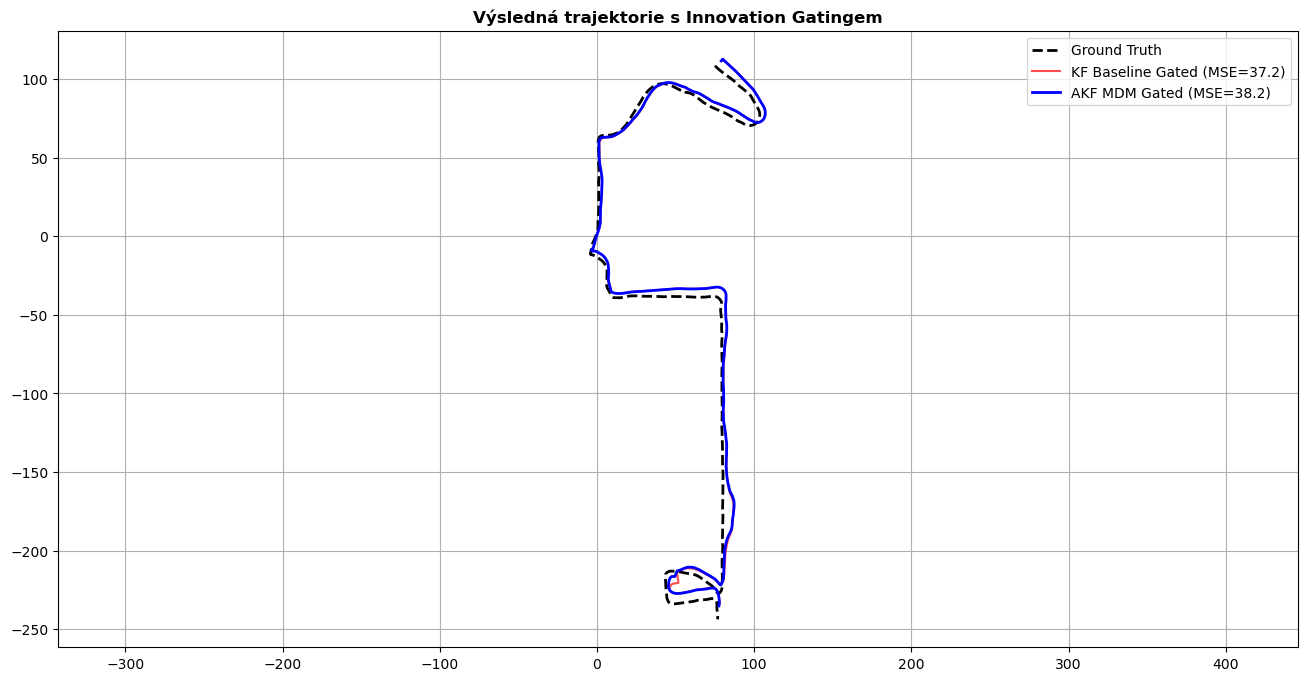

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from MDM.MDM_functions import MDM_nullO_LTI, Ksi_fun, baseMatrix_fun, Upsilon_2_fun, kron2_vec, kron2_mat

# Vynutíme CPU
device = torch.device("cpu")
print(f"Běžím na zařízení: {device}")

# ==============================================================================
# 0. UPRAVENÉ TŘÍDY FILTRŮ PŘÍMO VE SKRIPTU (S PARCIÁLNÍM INNOVATION GATINGEM)
# ==============================================================================
class KalmanFilterGated:
    def __init__(self, model):
        self.device = model.Q.device
        self.dtype = model.F.dtype
        self.model = model
        self.F, self.H, self.Q, self.R = model.F, model.H, model.Q, model.R
        self.state_dim = self.F.shape[0]
        self.obs_dim = self.H.shape[0]
        self.I = torch.eye(self.state_dim, device=self.device, dtype=self.dtype)
        self.reset(model.Ex0, model.P0)

    def reset(self, Ex0, P0):
        # Ex0 je nyní dynamicky předáváno na začátku každé sekvence
        self.x_predict_current = Ex0.clone().detach().reshape(self.state_dim, 1)
        self.P_predict_current = P0.clone().detach()

    def step(self, y_t, gate_threshold=9.21): # 9.21 = Chi-Sq 99% limit pro 2 DOF
        rejected = False
        if y_t is not None:
            y_t_vec = y_t.reshape(self.obs_dim, 1)
            inov = y_t_vec - self.H @ self.x_predict_current
            S = self.H @ self.P_predict_current @ self.H.T + self.R
            S_inv = torch.linalg.inv(S)
            
            # --- PARCIÁLNÍ GATING (Pouze na pozici X a Y) ---
            # X je index 0, Y je index 2
            inov_gps = torch.cat([inov[0:1], inov[2:3]], dim=0) # [2, 1]
            
            S_gps = torch.zeros((2, 2), device=self.device, dtype=self.dtype)
            S_gps[0, 0] = S[0, 0]; S_gps[0, 1] = S[0, 2]
            S_gps[1, 0] = S[2, 0]; S_gps[1, 1] = S[2, 2]
            
            S_gps_inv = torch.linalg.inv(S_gps)
            mah_sq_gps = (inov_gps.T @ S_gps_inv @ inov_gps).item()
            
            if mah_sq_gps > gate_threshold:
                rejected = True

        if y_t is None or rejected:
            # PREDICT ONLY (Měření zahozeno nebo chybí)
            x_filtered = self.x_predict_current
            P_filtered = self.P_predict_current
            K = torch.zeros((self.state_dim, self.obs_dim), device=self.device, dtype=self.dtype)
        else:
            # STANDARD UPDATE
            K = self.P_predict_current @ self.H.T @ S_inv
            x_filtered = self.x_predict_current + K @ inov
            I_KH = self.I - K @ self.H
            P_filtered = I_KH @ self.P_predict_current @ I_KH.T + K @ self.R @ K.T

        # PREDICT PRO DALŠÍ KROK
        x_predict_next = self.F @ x_filtered
        P_predict_next = self.F @ P_filtered @ self.F.T + self.Q
        
        self.x_predict_current = x_predict_next
        self.P_predict_current = P_predict_next

        return x_filtered, P_filtered, K, rejected

    def process_sequence(self, y_seq, Ex0, P0, gate_threshold=9.21):
        seq_len = y_seq.shape[0]
        self.reset(Ex0, P0)
        x_hist = torch.zeros(seq_len, self.state_dim, device=self.device, dtype=self.dtype)
        P_hist = torch.zeros(seq_len, self.state_dim, self.state_dim, device=self.device, dtype=self.dtype)
        
        for k in tqdm(range(seq_len), desc="Standard KF Gated", leave=False):
            x_f, P_f, _, _ = self.step(y_seq[k], gate_threshold)
            x_hist[k] = x_f.squeeze()
            P_hist[k] = P_f
            
        return {'x_filtered': x_hist, 'P_filtered': P_hist}


class AdaptiveKalmanFilter_online_Gated:
    def __init__(self, model, mdm_L=6, mdm_version=1, lambda_rls=0.99, init_sigma_rls_value=0.1, alpha_nom=None):
        self.kf = KalmanFilterGated(model)
        self.device, self.dtype = model.Q.device, model.Q.dtype
        self.np_dtype = np.float32 if self.dtype == torch.float32 else np.float64
        self.mdm_L, self.mdm_version, self.lambda_rls = mdm_L, mdm_version, lambda_rls
        self.nw, self.nv = self.kf.F.shape[0], self.kf.H.shape[0]
        
        self.F_np = self.kf.F.cpu().numpy().astype(self.np_dtype)
        self.H_np = self.kf.H.cpu().numpy().astype(self.np_dtype)
        self.E_np = np.eye(self.nw, dtype=self.np_dtype)
        self.D_np = np.eye(self.nv, dtype=self.np_dtype)
        self.nz_np = np.array([self.nv])
        
        self.Ksi, self.H_rls_norm, self.weights, self.HTH, self.HT = None, None, None, None, None
        
        T = 1.0
        self.Q_template = np.array([[T**3/3, T**2/2, 0, 0], [T**2/2, T, 0, 0], [0, 0, T**3/3, T**2/2], [0, 0, T**2/2, T]], dtype=self.np_dtype)
        self.vec_Q_template = self.Q_template[np.triu_indices(self.nw)][:, np.newaxis]
        self.n_params_Q_full, self.n_params_Q_reduced = (self.nw * (self.nw + 1)) // 2, 1
        self.n_params_R_full, self.n_params_R_reduced = (self.nv * (self.nv + 1)) // 2, 2
        
        self.T_R_matrix = np.zeros((self.n_params_R_full, self.n_params_R_reduced), dtype=self.np_dtype)
        self.T_R_matrix[0, 0] = self.T_R_matrix[7, 0] = self.T_R_matrix[4, 1] = self.T_R_matrix[9, 1] = 1.0 
        
        Q0, R0 = model.Q.cpu().numpy(), model.R.cpu().numpy()
        self.alpha_est = np.array([Q0[0,0] / self.Q_template[0,0], R0[0,0], R0[1,1]], dtype=self.np_dtype)
        self.alpha_nom = np.array(alpha_nom, dtype=self.np_dtype)

        sigma_q = (self.alpha_nom[0] * init_sigma_rls_value)**2 + 1e-12
        sigma_r1 = (self.alpha_nom[1] * init_sigma_rls_value)**2 + 1e-12
        sigma_r2 = (self.alpha_nom[2] * init_sigma_rls_value)**2 + 1e-12
        self.Sigma_RLS = np.diag([sigma_q, sigma_r1, sigma_r2]).astype(self.np_dtype)
        
        self.z_buffer, self.u_buffer = [], []
        self.Upsilon_2 = None

    def _get_upsilon(self):
        if self.Upsilon_2 is None:
            w2b, v2b = [baseMatrix_fun(self.nw, 1)], [baseMatrix_fun(self.nv, 1)]
            self.Upsilon_2 = Upsilon_2_fun(w2b, v2b, self.mdm_L)
        return self.Upsilon_2

    def step_adaptive(self, y_t, gate_threshold=9.21):
        x_filt, P_filt, K, rejected = self.kf.step(y_t, gate_threshold)
        
        if rejected:
            # Měření je OUTLIER. Vymažeme buffer, neadaptujeme se.
            self.z_buffer = []
            self.u_buffer = []
            return x_filt, P_filt, K, self.kf.Q, self.kf.R

        y_np = y_t.cpu().numpy().squeeze()
        if y_np.ndim == 0: y_np = np.expand_dims(y_np, axis=0)
        u_np = np.zeros(1, dtype=self.np_dtype)

        self.z_buffer.append(y_np)
        self.u_buffer.append(u_np)
        
        if len(self.z_buffer) > self.mdm_L:
            self.z_buffer.pop(0)
            self.u_buffer.pop(0)

        if len(self.z_buffer) == self.mdm_L:
            try:
                z_window = np.array(self.z_buffer, dtype=self.np_dtype)
                u_window = np.array(self.u_buffer, dtype=self.np_dtype)
                G_np = np.zeros((self.nw, 1), dtype=self.np_dtype)

                r_list, Awv_matrix = MDM_nullO_LTI(self.mdm_L, self.F_np, G_np, self.E_np, self.nz_np, self.H_np, self.D_np, z_window, u_window, self.mdm_version)
                r_k = r_list[0]
                
                if self.H_rls_norm is None:
                    self.Ksi = Ksi_fun(r_k.shape[0])
                    H_full = self.Ksi @ kron2_mat(Awv_matrix) @ self._get_upsilon()
                    H_rls = np.hstack([H_full[:, :self.n_params_Q_full] @ self.vec_Q_template, H_full[:, self.n_params_Q_full:] @ self.T_R_matrix])
                    self.weights = np.abs(H_rls @ self.alpha_nom).flatten() + 1e-12
                    self.H_rls_norm = H_rls / self.weights[:, np.newaxis]
                    self.HT = self.H_rls_norm.T
                    self.HTH = self.HT @ self.H_rls_norm

                y_rls_norm = (self.Ksi @ kron2_vec(r_k)).flatten() / self.weights
                
                P_next_unscaled = np.linalg.inv(np.linalg.inv(self.Sigma_RLS) + self.HTH)
                self.Sigma_RLS = P_next_unscaled / self.lambda_rls
                self.alpha_est += (P_next_unscaled @ self.HT) @ (y_rls_norm - self.H_rls_norm @ self.alpha_est)
                
                Q_new = max(self.alpha_est[0], 1e-10) * self.Q_template
                r1, r2 = max(self.alpha_est[1], 1e-10), max(self.alpha_est[2], 1e-10)
                R_new = np.diag([r1, r2, r1, r2])
                
                self.kf.Q = torch.from_numpy(Q_new).to(self.device).to(self.dtype)
                self.kf.R = torch.from_numpy(R_new).to(self.device).to(self.dtype)
                
            except Exception as e:
                pass

        return x_filt, P_filt, K, self.kf.Q, self.kf.R

    def process_sequence_adaptively(self, y_seq, Ex0, P0, gate_threshold=9.21):
        seq_len = y_seq.shape[0]
        self.kf.reset(Ex0, P0)
        self.z_buffer, self.u_buffer = [], []
        x_hist = torch.zeros(seq_len, self.nw, device=self.device, dtype=self.dtype)
        P_hist = torch.zeros(seq_len, self.nw, self.nw, device=self.device, dtype=self.dtype)
        Q_hist, R_hist = [], []

        for k in tqdm(range(seq_len), desc="AKF MDM Gated", leave=False):
            x, P, K, Q_curr, R_curr = self.step_adaptive(y_seq[k], gate_threshold)
            x_hist[k], P_hist[k] = x.squeeze(), P
            Q_hist.append(Q_curr.clone().detach())
            R_hist.append(R_curr.clone().detach())
            
        return {'x_filtered': x_hist, 'P_filtered': P_hist}, Q_hist, R_hist

# ==============================================================================
# 1. DEFINICE SYSTÉMU A NAČTENÍ DAT
# ==============================================================================
import Systems

m = 4; n = 4; delta_t = 1.0 
F_dim = torch.tensor([[1.0, delta_t], [0.0, 1.0]], dtype=torch.float64)
F_design = torch.block_diag(F_dim, F_dim).to(device)
H_design = torch.eye(n, dtype=torch.float64).to(device)

q_scale_init, var_gps_init, var_odo_init = 0.000132, 39.32, 0.00057
Q_block_val = torch.tensor([[(delta_t**3)/3, (delta_t**2)/2], [(delta_t**2)/2,  delta_t]], dtype=torch.float64) * q_scale_init
Q_design = torch.block_diag(Q_block_val, Q_block_val).to(device)
R_design = torch.diag(torch.tensor([var_gps_init, var_odo_init, var_gps_init, var_odo_init], dtype=torch.float64)).to(device)

# P0 je stále stejné (malá, ale nenulová počáteční nejistota)
m2x_0 = torch.diag(torch.tensor([10.0, 1.0, 10.0, 1.0], dtype=torch.float64)).to(device)

# Upravte cesty
train_path = '../preprocessed_NCLT_trajectory-2012-01-22-angle-update/train.pt' 
test_path = '../preprocessed_NCLT_trajectory-2012-01-22-angle-update/test.pt' 

train_gt = torch.load(train_path)[0]['ground_truth'].to(device).double()
train_meas = torch.load(train_path)[0]['filtered_gps'].to(device).double()
test_gt = torch.load(test_path)[0]['ground_truth'].to(device).double()
test_meas = torch.load(test_path)[0]['filtered_gps'].to(device).double()

# ZDE JE ZMĚNA: m1x_0 odpovídá skutečnému prvnímu stavu z Ground Truth!
m1x_0_train = train_gt[0].unsqueeze(1)
m1x_0_test = test_gt[0].unsqueeze(1)

sys_model = Systems.DynamicSystem(state_dim=m, obs_dim=n, Ex0=m1x_0_train, P0=m2x_0, Q=Q_design, R=R_design, F=F_design, H=H_design, device=device)

# ==============================================================================
# 2. FÁZE TRÉNINKU (NA CELÉ TRÉNOVACÍ SADĚ VČETNĚ OUTLIERŮ!)
# ==============================================================================
print("\n--- FÁZE 1: UČENÍ NA KOMPLETNÍCH DATECH (Díky Gatingu bez rizika) ---")
T_sampling = 1.0
template_val_00 = (T_sampling**3) / 3.0
NUM_EPOCHS = 5 
current_alpha = [q_scale_init, var_gps_init, var_odo_init]

for epoch in range(NUM_EPOCHS):
    print(f"Epocha {epoch+1}/{NUM_EPOCHS}...")
    akf_train = AdaptiveKalmanFilter_online_Gated(
        sys_model, mdm_L=6, lambda_rls=0.999, init_sigma_rls_value=0.1, alpha_nom=current_alpha
    )
    
    # Použijeme parciální gating threshold 9.21 pro GPS a m1x_0_train
    _, Q_hist_tr, R_hist_tr = akf_train.process_sequence_adaptively(train_meas, Ex0=m1x_0_train, P0=m2x_0, gate_threshold=50.0)
    
    current_alpha = [
        Q_hist_tr[-1][0, 0].item() / template_val_00,
        R_hist_tr[-1][0, 0].item(),
        R_hist_tr[-1][1, 1].item()
    ]

baseline_q, baseline_r_gps, baseline_r_odo = current_alpha
print("\n🌟 ZLATÝ STANDARD NALEZEN PŘÍMO Z HRUBÝCH DAT 🌟")
print(f"Q (scale): {baseline_q:.6f}")
print(f"R (GPS):   {baseline_r_gps:.4f}")
print(f"R (ODO):   {baseline_r_odo:.6f}")

# Přepis modelu
Q_block_new = torch.tensor([[(delta_t**3)/3, (delta_t**2)/2], [(delta_t**2)/2,  delta_t]], dtype=torch.float64) * baseline_q
sys_model.Q = torch.block_diag(Q_block_new, Q_block_new).to(device)
sys_model.R = torch.diag(torch.tensor([baseline_r_gps, baseline_r_odo, baseline_r_gps, baseline_r_odo], dtype=torch.float64)).to(device)

# ==============================================================================
# 3. FÁZE TESTOVÁNÍ NA OSTRÝCH DATECH 
# ==============================================================================
print("\n--- FÁZE 2: TESTOVÁNÍ NA OSTRÉ TRAJEKTORII ---")

# a) Standardní KF s Gatingem (Baseline)
print("Spouštím Standardní KF Baseline (s Gatingem)...")
kf_baseline = KalmanFilterGated(sys_model)
# Používáme m1x_0_test
res_kf = kf_baseline.process_sequence(test_meas, Ex0=m1x_0_test, P0=m2x_0, gate_threshold=9.21)

# b) AKF MDM s Gatingem
print("Spouštím AKF MDM (s Gatingem)...")
akf_filter = AdaptiveKalmanFilter_online_Gated(
    sys_model, mdm_L=6, lambda_rls=1.0, init_sigma_rls_value=0.01, alpha_nom=current_alpha
)
# Používáme m1x_0_test
res_akf, Q_hist_test, R_hist_test = akf_filter.process_sequence_adaptively(test_meas, Ex0=m1x_0_test, P0=m2x_0, gate_threshold=9.21)

# ==============================================================================
# 4. VYHODNOCENÍ A VIZUALIZACE
# ==============================================================================
x_est_kf = res_kf['x_filtered'].detach().cpu().numpy()
x_est_akf = res_akf['x_filtered'].detach().cpu().numpy()
gt_test_np = test_gt.detach().cpu().numpy()

def calc_metrics(est, gt):
    mse_total = np.mean((est[:, 0] - gt[:, 0])**2 + (est[:, 2] - gt[:, 2])**2)
    return mse_total, np.sqrt(mse_total)

mse_kf, rmse_kf = calc_metrics(x_est_kf, gt_test_np)
mse_akf, rmse_akf = calc_metrics(x_est_akf, gt_test_np)

print("\n" + "="*60)
print(f"VÝSLEDKY NA TESTOVACÍ TRAJEKTORII:")
print(f"Standardní KF Gated (Baseline)  -> MSE: {mse_kf:.4f} | RMSE: {rmse_kf:.4f} m")
print(f"AKF MDM Gated (Adaptivní)       -> MSE: {mse_akf:.4f} | RMSE: {rmse_akf:.4f} m")
print("="*60)

# Kreslení 
fig = plt.figure(figsize=(16, 8))
plt.plot(gt_test_np[:, 0], gt_test_np[:, 2], 'k--', label='Ground Truth', linewidth=2)
plt.plot(x_est_kf[:, 0], x_est_kf[:, 2], 'r-', label=f'KF Baseline Gated (MSE={mse_kf:.1f})', alpha=0.7)
plt.plot(x_est_akf[:, 0], x_est_akf[:, 2], 'b-', label=f'AKF MDM Gated (MSE={mse_akf:.1f})', linewidth=2)
plt.title('Výsledná trajektorie s Innovation Gatingem', fontweight='bold')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

## MDM bez treninku na testovac itrajektorii


Běžím na zařízení: cpu

--- FÁZE 2: TESTOVÁNÍ NA OSTRÉ TRAJEKTORII ---
Spouštím Standardní KF Baseline (s Gatingem)...
Spouštím AKF MDM (s Gatingem)...


Processing sequence adaptively: 100%|██████████| 522/522 [00:18<00:00, 28.17it/s]



VÝSLEDKY NA TESTOVACÍ TRAJEKTORII:
Standardní KF Gated (Baseline)  -> MSE: 144.9760 | RMSE: 12.0406 m
AKF MDM Gated (Adaptivní)       -> MSE: 51.9268 | RMSE: 7.2060 m


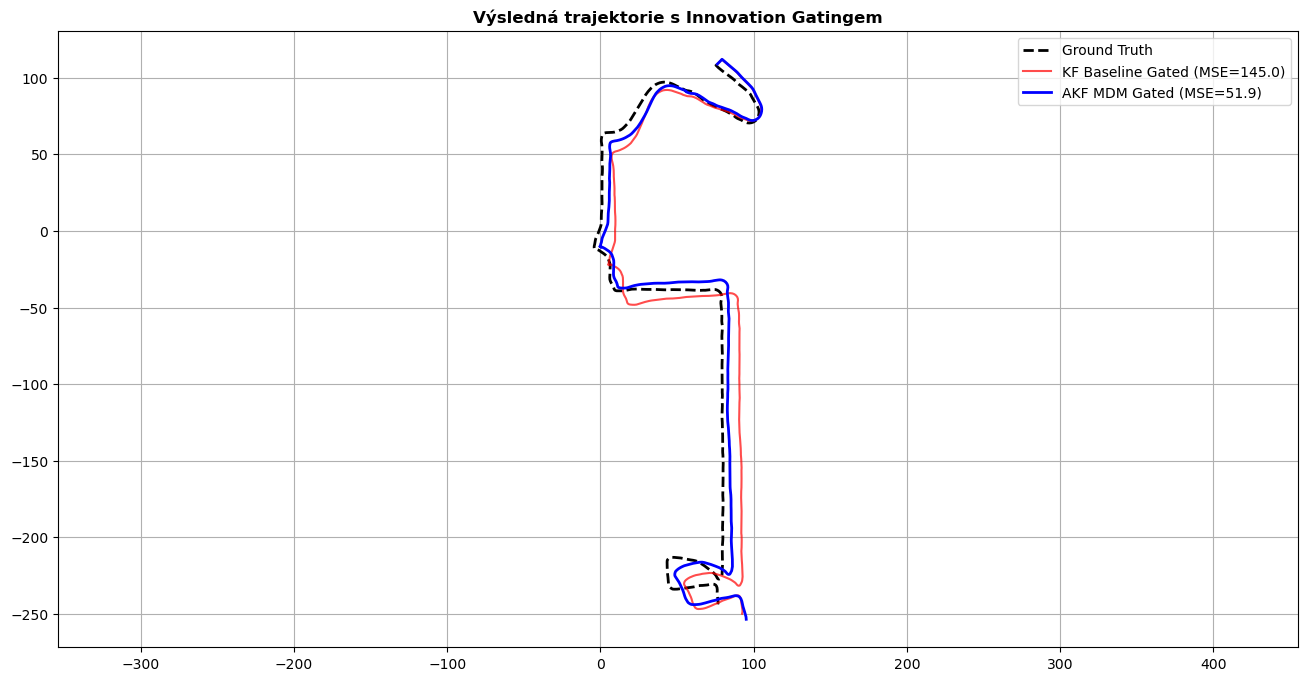

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from MDM.MDM_functions import MDM_nullO_LTI, Ksi_fun, baseMatrix_fun, Upsilon_2_fun, kron2_vec, kron2_mat

# Vynutíme CPU
device = torch.device("cpu")
print(f"Běžím na zařízení: {device}")

# ==============================================================================
# 1. DEFINICE SYSTÉMU A NAČTENÍ DAT
# ==============================================================================
import Systems

m = 4; n = 4; delta_t = 1.0 
F_dim = torch.tensor([[1.0, delta_t], [0.0, 1.0]], dtype=torch.float64)
F_design = torch.block_diag(F_dim, F_dim).to(device)
H_design = torch.eye(n, dtype=torch.float64).to(device)

q_scale_init, var_gps_init, var_odo_init = 0.000132, 39.32, 0.00057
Q_block_val = torch.tensor([[(delta_t**3)/3, (delta_t**2)/2], [(delta_t**2)/2,  delta_t]], dtype=torch.float64) * q_scale_init
Q_design = torch.block_diag(Q_block_val, Q_block_val).to(device)
R_design = torch.diag(torch.tensor([var_gps_init, var_odo_init, var_gps_init, var_odo_init], dtype=torch.float64)).to(device)

# P0 je stále stejné (malá, ale nenulová počáteční nejistota)
m2x_0 = torch.diag(torch.tensor([10.0, 1.0, 10.0, 1.0], dtype=torch.float64)).to(device)

# Upravte cesty
test_path = '../preprocessed_NCLT_trajectory-2012-01-22-angle-update/test.pt' 

test_gt = torch.load(test_path)[0]['ground_truth'].to(device).double()
test_meas = torch.load(test_path)[0]['filtered_gps'].to(device).double()

m1x_0_test = test_gt[0].unsqueeze(1)

sys_model = Systems.DynamicSystem(state_dim=m, obs_dim=n, Ex0=m1x_0_test, P0=m2x_0, Q=Q_design, R=R_design, F=F_design, H=H_design, device=device)

# ==============================================================================
# 3. FÁZE TESTOVÁNÍ NA OSTRÝCH DATECH 
# ==============================================================================
print("\n--- FÁZE 2: TESTOVÁNÍ NA OSTRÉ TRAJEKTORII ---")

# a) Standardní KF s Gatingem (Baseline)
print("Spouštím Standardní KF Baseline (s Gatingem)...")
kf_baseline = KalmanFilter(sys_model)
# Používáme m1x_0_test
res_kf = kf_baseline.process_sequence(test_meas, Ex0=m1x_0_test, P0=m2x_0)

# b) AKF MDM s Gatingem
print("Spouštím AKF MDM (s Gatingem)...")
akf_filter = Filters.AdaptiveKalmanFilter_online(
    sys_model, mdm_L=6, lambda_rls=1.0, init_sigma_rls_value=0.01, alpha_nom=current_alpha
)
# Používáme m1x_0_test
res_akf, Q_hist_test, R_hist_test = akf_filter.process_sequence_adaptively(test_meas, Ex0=m1x_0_test, P0=m2x_0)

# ==============================================================================
# 4. VYHODNOCENÍ A VIZUALIZACE
# ==============================================================================
x_est_kf = res_kf['x_filtered'].detach().cpu().numpy()
x_est_akf = res_akf['x_filtered'].detach().cpu().numpy()
gt_test_np = test_gt.detach().cpu().numpy()

def calc_metrics(est, gt):
    mse_total = np.mean((est[:, 0] - gt[:, 0])**2 + (est[:, 2] - gt[:, 2])**2)
    return mse_total, np.sqrt(mse_total)

mse_kf, rmse_kf = calc_metrics(x_est_kf, gt_test_np)
mse_akf, rmse_akf = calc_metrics(x_est_akf, gt_test_np)

print("\n" + "="*60)
print(f"VÝSLEDKY NA TESTOVACÍ TRAJEKTORII:")
print(f"Standardní KF Gated (Baseline)  -> MSE: {mse_kf:.4f} | RMSE: {rmse_kf:.4f} m")
print(f"AKF MDM Gated (Adaptivní)       -> MSE: {mse_akf:.4f} | RMSE: {rmse_akf:.4f} m")
print("="*60)

# Kreslení 
fig = plt.figure(figsize=(16, 8))
plt.plot(gt_test_np[:, 0], gt_test_np[:, 2], 'k--', label='Ground Truth', linewidth=2)
plt.plot(x_est_kf[:, 0], x_est_kf[:, 2], 'r-', label=f'KF Baseline Gated (MSE={mse_kf:.1f})', alpha=0.7)
plt.plot(x_est_akf[:, 0], x_est_akf[:, 2], 'b-', label=f'AKF MDM Gated (MSE={mse_akf:.1f})', linewidth=2)
plt.title('Výsledná trajektorie s Innovation Gatingem', fontweight='bold')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

# celá trajektorie

## Standardní MDM s parametry získanými z tréninku

Běžím na zařízení: cpu

--- NAČÍTÁNÍ KOMPLETNÍ TRAJEKTORIE ---
Délka sekvence: 5208 kroků

--- SPUŠTĚNÍ FILTRŮ NA PLNÉ TRAJEKTORII ---
1. Spouštím KF True (Grid-Search)...


2. Spouštím Standardní KF (Baseline)...


3. Spouštím AKF MDM (Adaptivní)...


Processing sequence adaptively: 100%|██████████| 5208/5208 [03:37<00:00, 23.90it/s]
/tmp/ipykernel_16746/733388447.py:151: RuntimeWarning: invalid value encountered in sqrt
  sigma_x_akf = np.sqrt(P_est_akf[:, 0, 0])



VÝSLEDKY NA KOMPLETNÍ TRAJEKTORII (5208 kroků):
KF True (Grid-Search parametry) -> MSE: 834.4072 | RMSE: 28.8861 m
Standardní KF (Baseline)        -> MSE: 1659.7366 | RMSE: 40.7399 m
AKF MDM (Adaptivní)             -> MSE: 1699.2287 | RMSE: 41.2217 m


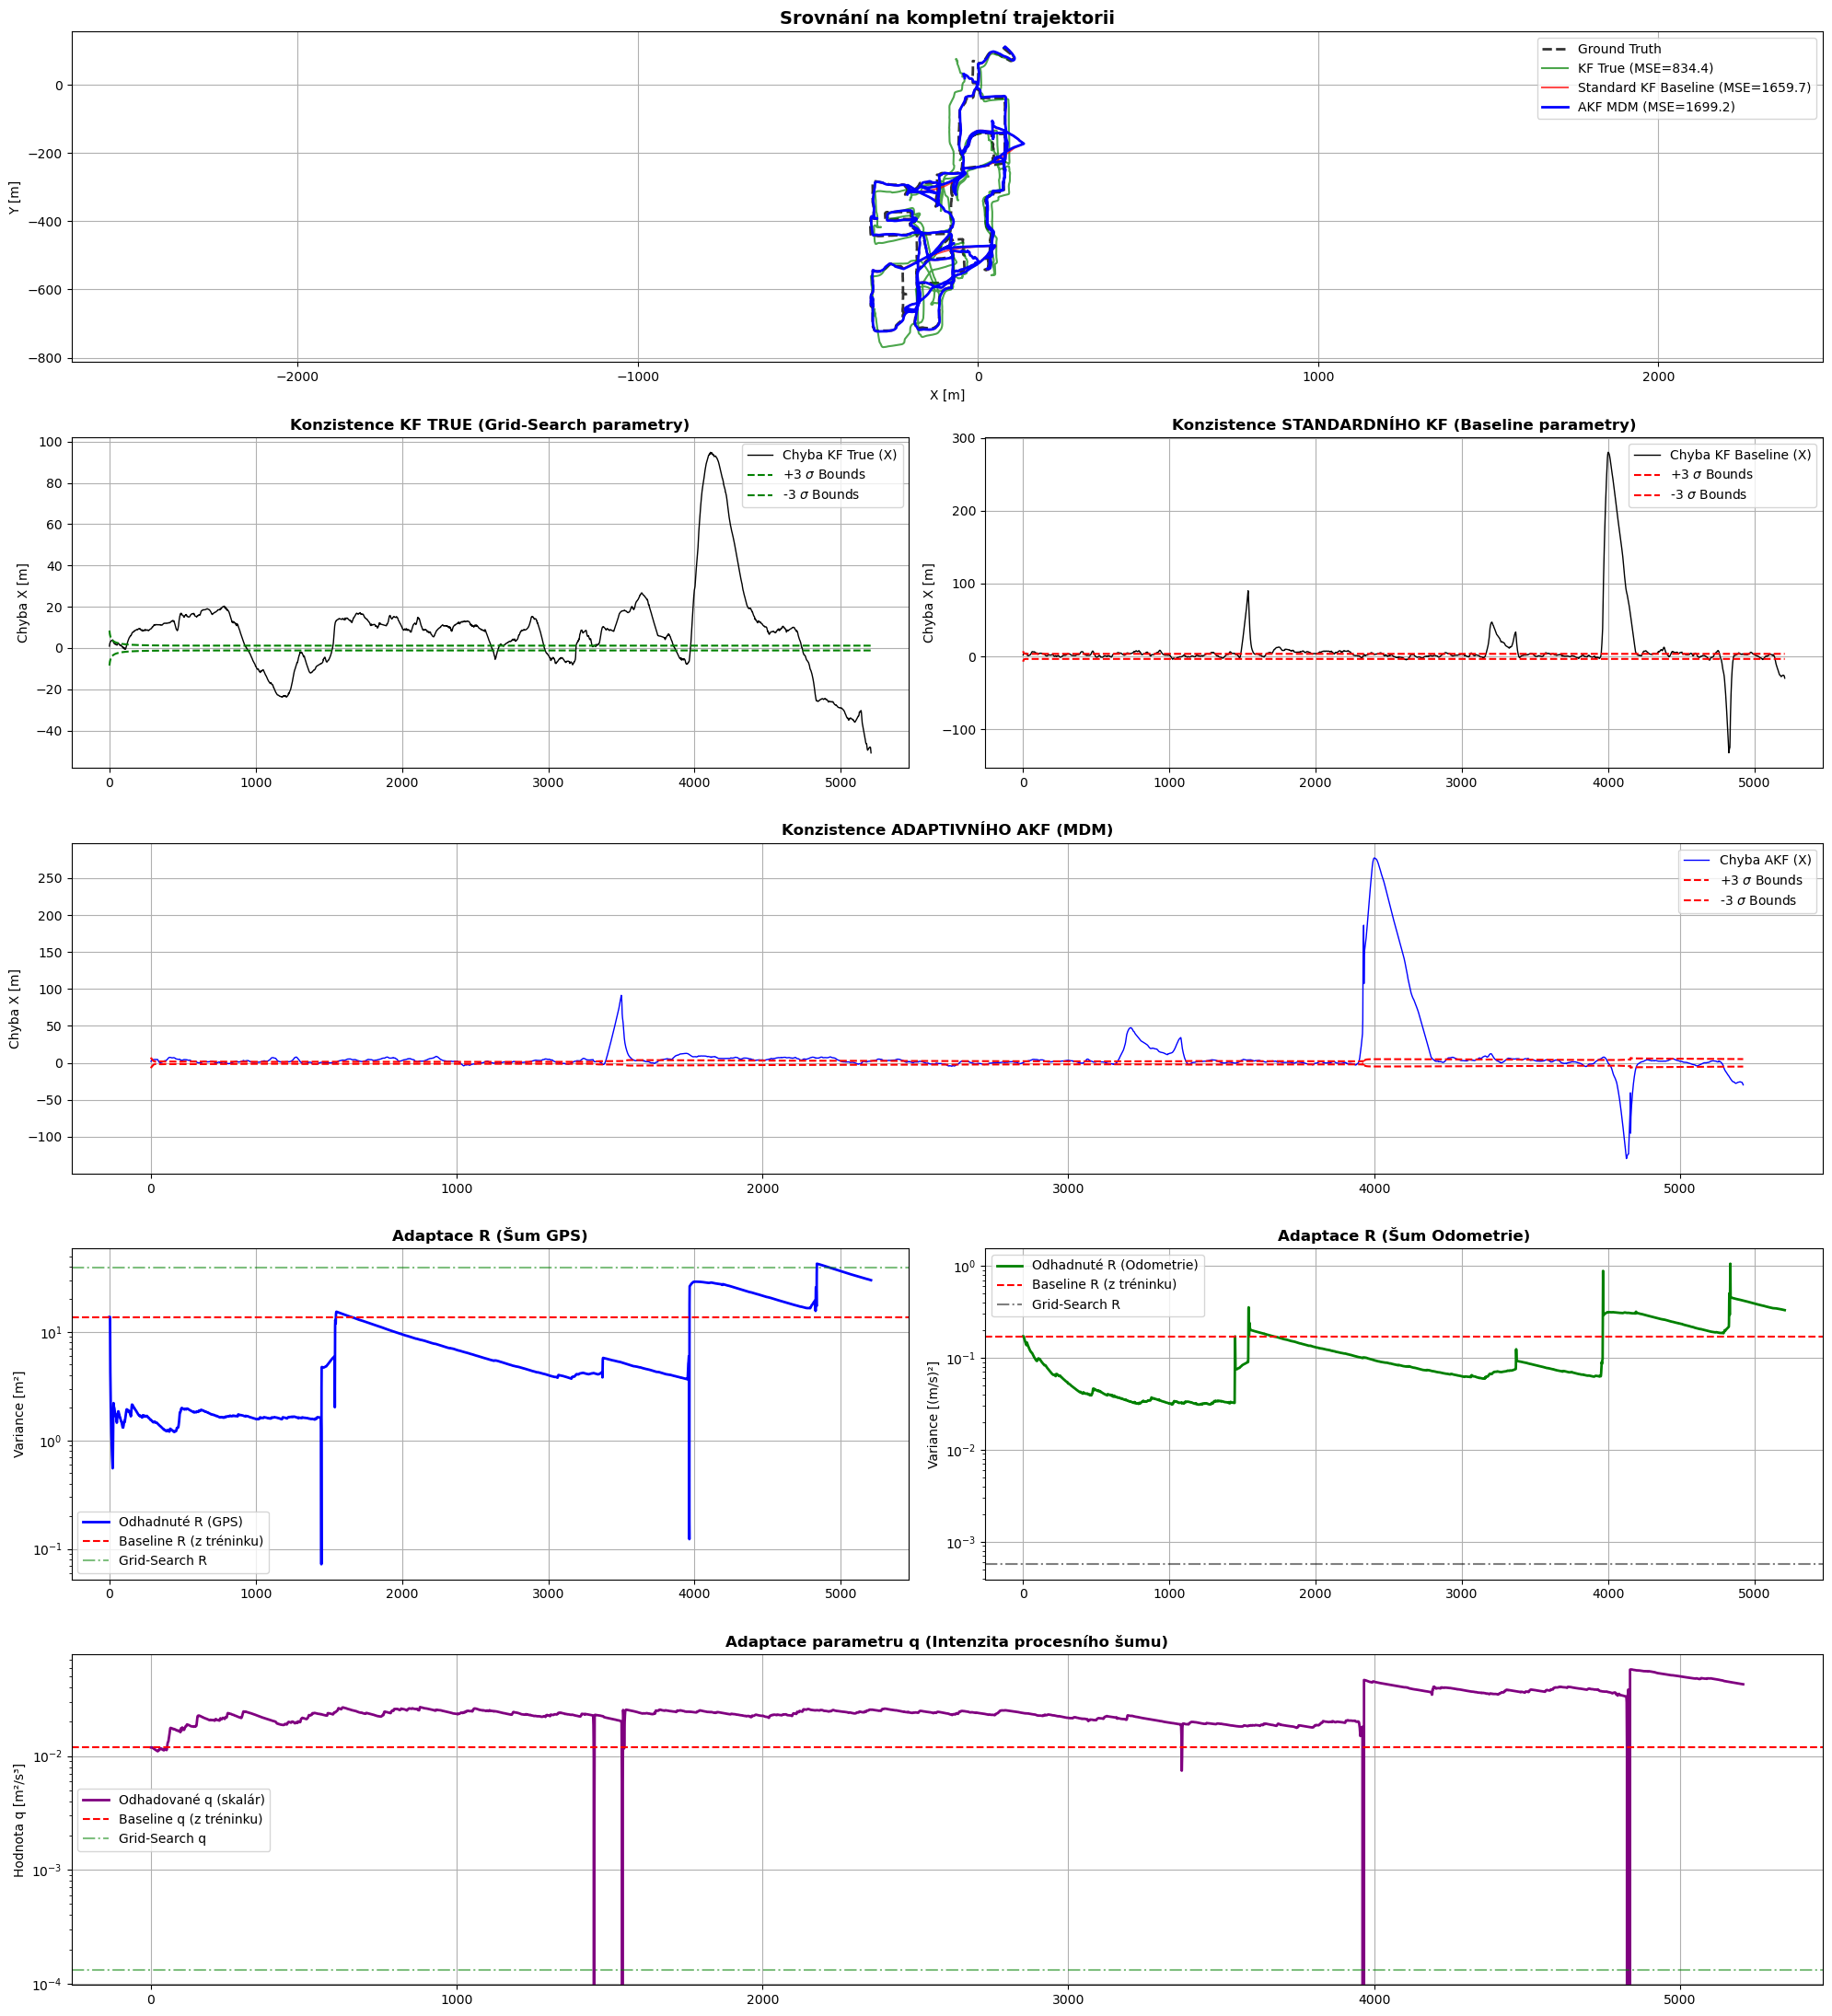

In [13]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt
import Systems
import Filters  # Tvůj modul s filtry
from tqdm import tqdm

# Vynutíme CPU
device = torch.device("cpu")
print(f"Běžím na zařízení: {device}")

#########################
### Design Parameters ###
#########################
m = 4 
n = 4 
delta_t = 1.0 

# Dynamika (F) a Měření (H)
F_dim = torch.tensor([[1.0, delta_t], [0.0, 1.0]], dtype=torch.float64)
F_design = torch.block_diag(F_dim, F_dim).to(device)
H_design = torch.eye(n, dtype=torch.float64).to(device)

# ==============================================================================
# ZADANÉ PARAMETRY (Z tréninku / Grid-Searche)
# ==============================================================================
# Původní Grid-Search parametry (Pro KF True)
q_scale_init = 0.000132
var_gps_init = 39.32
var_odo_init = 0.00057

# Vaše "Zlaté" Baseline parametry z tréninku
baseline_q = 0.011913
baseline_r_gps = 13.7453
baseline_r_odo = 0.170883

# Sestavení matic pro KF True
Q_block_true = torch.tensor([[(delta_t**3)/3, (delta_t**2)/2], [(delta_t**2)/2,  delta_t]], dtype=torch.float64) * q_scale_init
Q_true = torch.block_diag(Q_block_true, Q_block_true).to(device)
R_true = torch.diag(torch.tensor([var_gps_init, var_odo_init, var_gps_init, var_odo_init], dtype=torch.float64)).to(device)

# Sestavení matic pro Baseline KF a AKF MDM
Q_block_base = torch.tensor([[(delta_t**3)/3, (delta_t**2)/2], [(delta_t**2)/2,  delta_t]], dtype=torch.float64) * baseline_q
Q_base = torch.block_diag(Q_block_base, Q_block_base).to(device)
R_base = torch.diag(torch.tensor([baseline_r_gps, baseline_r_odo, baseline_r_gps, baseline_r_odo], dtype=torch.float64)).to(device)

# ==============================================================================
# NAČTENÍ KOMPLETNÍ TRAJEKTORIE
# ==============================================================================
print("\n--- NAČÍTÁNÍ KOMPLETNÍ TRAJEKTORIE ---")
full_traj_path = '../preprocessed_NCLT_FULL/test_full_trajectory.pt' 
full_dataset = torch.load(full_traj_path)[0]

full_gt = full_dataset['ground_truth'].to(device).double()
full_meas = full_dataset['filtered_gps'].to(device).double()
seq_len = full_meas.shape[0]
print(f"Délka sekvence: {seq_len} kroků")

# Počáteční podmínky (Startujeme ze skutečné pozice)
m1x_0 = full_gt[0].unsqueeze(1)
m2x_0 = torch.diag(torch.tensor([10.0, 1.0, 10.0, 1.0], dtype=torch.float64)).to(device)

# === INICIALIZACE SYSTÉMŮ ===
sys_true = Systems.DynamicSystem(
    state_dim=m, obs_dim=n, Ex0=m1x_0, P0=m2x_0,
    Q=Q_true, R=R_true, F=F_design, H=H_design, device=device
)

sys_model = Systems.DynamicSystem(
    state_dim=m, obs_dim=n, Ex0=m1x_0, P0=m2x_0,
    Q=Q_base, R=R_base, F=F_design, H=H_design, device=device
)

# ==============================================================================
# SPUŠTĚNÍ FILTRŮ
# ==============================================================================
print("\n--- SPUŠTĚNÍ FILTRŮ NA PLNÉ TRAJEKTORII ---")

# 1. KF True (s původními Grid-Search parametry)
print("1. Spouštím KF True (Grid-Search)...")
kf_true_filter = Filters.KalmanFilter(sys_true) # Předpokládám, že používáte svou původní implementaci bez Gatingu
res_kf_true = kf_true_filter.process_sequence(full_meas, Ex0=m1x_0, P0=m2x_0)

# 2. Standardní KF (s naučenými Baseline parametrami)
print("2. Spouštím Standardní KF (Baseline)...")
kf_filter = Filters.KalmanFilter(sys_model) 
res_kf = kf_filter.process_sequence(full_meas, Ex0=m1x_0, P0=m2x_0)

# 3. AKF MDM
print("3. Spouštím AKF MDM (Adaptivní)...")
akf_filter = Filters.AdaptiveKalmanFilter_online(
    sys_model, 
    mdm_L=6, 
    mdm_version=1,
    lambda_rls=0.999,
    init_sigma_rls_value=0.1,
    alpha_nom=[baseline_q, baseline_r_gps, baseline_r_odo] 
)
res_akf, Q_hist_test, R_hist_test = akf_filter.process_sequence_adaptively(full_meas, Ex0=m1x_0, P0=m2x_0)

# ==============================================================================
# VYHODNOCENÍ METRIK
# ==============================================================================
x_est_kf_true = res_kf_true['x_filtered'].detach().cpu().numpy()
x_est_kf = res_kf['x_filtered'].detach().cpu().numpy()
x_est_akf = res_akf['x_filtered'].detach().cpu().numpy()
gt_np = full_gt.detach().cpu().numpy()

def calc_metrics(est, gt):
    mse_x = np.mean((est[:, 0] - gt[:, 0])**2)
    mse_y = np.mean((est[:, 2] - gt[:, 2])**2)
    total_mse = mse_x + mse_y
    rmse = np.sqrt(total_mse)
    return total_mse, rmse

mse_kf_true, rmse_kf_true = calc_metrics(x_est_kf_true, gt_np)
mse_kf, rmse_kf = calc_metrics(x_est_kf, gt_np)
mse_akf, rmse_akf = calc_metrics(x_est_akf, gt_np)

print("\n" + "="*60)
print(f"VÝSLEDKY NA KOMPLETNÍ TRAJEKTORII ({seq_len} kroků):")
print(f"KF True (Grid-Search parametry) -> MSE: {mse_kf_true:.4f} | RMSE: {rmse_kf_true:.4f} m")
print(f"Standardní KF (Baseline)        -> MSE: {mse_kf:.4f} | RMSE: {rmse_kf:.4f} m")
print(f"AKF MDM (Adaptivní)             -> MSE: {mse_akf:.4f} | RMSE: {rmse_akf:.4f} m")
print("="*60)

# ==============================================================================
# VIZUALIZACE 
# ==============================================================================
T_sampling = 1.0
template_val_00 = (T_sampling**3) / 3.0
q_est_values = np.array([q[0, 0].item() for q in Q_hist_test]) / template_val_00
r_gps_hist = np.array([r[0, 0].item() for r in R_hist_test]) 
r_odo_hist = np.array([r[1, 1].item() for r in R_hist_test]) 

t_full = np.arange(seq_len)
t_akf = t_full[-len(r_gps_hist):] 

P_est_kf_true = res_kf_true['P_filtered'].detach().cpu().numpy()
P_est_kf = res_kf['P_filtered'].detach().cpu().numpy()
P_est_akf = res_akf['P_filtered'].detach().cpu().numpy()

error_x_kf_true = x_est_kf_true[:, 0] - gt_np[:, 0]
sigma_x_kf_true = np.sqrt(P_est_kf_true[:, 0, 0])

error_x_kf = x_est_kf[:, 0] - gt_np[:, 0]
sigma_x_kf = np.sqrt(P_est_kf[:, 0, 0])

error_x_akf = x_est_akf[:, 0] - gt_np[:, 0]
sigma_x_akf = np.sqrt(P_est_akf[:, 0, 0])

fig = plt.figure(figsize=(20, 22))
gs = fig.add_gridspec(5, 2)

# A) Trajektorie
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(gt_np[:, 0], gt_np[:, 2], 'k--', label='Ground Truth', linewidth=2, alpha=0.8)
ax1.plot(x_est_kf_true[:, 0], x_est_kf_true[:, 2], 'g-', label=f'KF True (MSE={mse_kf_true:.1f})', linewidth=1.5, alpha=0.7)
ax1.plot(x_est_kf[:, 0], x_est_kf[:, 2], 'r-', label=f'Standard KF Baseline (MSE={mse_kf:.1f})', linewidth=1.5, alpha=0.7)
ax1.plot(x_est_akf[:, 0], x_est_akf[:, 2], 'b-', label=f'AKF MDM (MSE={mse_akf:.1f})', linewidth=2)
ax1.set_title(f'Srovnání na kompletní trajektorii', fontweight='bold', fontsize=14)
ax1.set_xlabel('X [m]')
ax1.set_ylabel('Y [m]')
ax1.legend()
ax1.axis('equal')
ax1.grid(True)

# B1) Konzistence KF True
ax2_kf_true = fig.add_subplot(gs[1, 0])
ax2_kf_true.plot(t_full, error_x_kf_true, 'k-', label='Chyba KF True (X)', linewidth=1)
ax2_kf_true.plot(t_full, 3*sigma_x_kf_true, 'g--', label='+3 $\sigma$ Bounds')
ax2_kf_true.plot(t_full, -3*sigma_x_kf_true, 'g--', label='-3 $\sigma$ Bounds')
ax2_kf_true.set_title('Konzistence KF TRUE (Grid-Search parametry)', fontweight='bold')
ax2_kf_true.set_ylabel('Chyba X [m]')
ax2_kf_true.legend()
ax2_kf_true.grid(True)

# B2) Konzistence Standardní KF (Baseline)
ax2_kf = fig.add_subplot(gs[1, 1])
ax2_kf.plot(t_full, error_x_kf, 'k-', label='Chyba KF Baseline (X)', linewidth=1)
ax2_kf.plot(t_full, 3*sigma_x_kf, 'r--', label='+3 $\sigma$ Bounds')
ax2_kf.plot(t_full, -3*sigma_x_kf, 'r--', label='-3 $\sigma$ Bounds')
ax2_kf.set_title('Konzistence STANDARDNÍHO KF (Baseline parametry)', fontweight='bold')
ax2_kf.set_ylabel('Chyba X [m]')
ax2_kf.legend()
ax2_kf.grid(True)

# B3) Konzistence AKF (MDM) 
ax2_akf = fig.add_subplot(gs[2, :])
ax2_akf.plot(t_full, error_x_akf, 'b-', label='Chyba AKF (X)', linewidth=1)
ax2_akf.plot(t_full, 3*sigma_x_akf, 'r--', label='+3 $\sigma$ Bounds')
ax2_akf.plot(t_full, -3*sigma_x_akf, 'r--', label='-3 $\sigma$ Bounds')
ax2_akf.set_title('Konzistence ADAPTIVNÍHO AKF (MDM)', fontweight='bold')
ax2_akf.set_ylabel('Chyba X [m]')
ax2_akf.legend()
ax2_akf.grid(True)

# C) Adaptace R
ax3 = fig.add_subplot(gs[3, 0])
ax3.plot(t_akf, r_gps_hist, 'b-', label='Odhadnuté R (GPS)', linewidth=2)
ax3.axhline(baseline_r_gps, color='r', linestyle='--', label='Baseline R (z tréninku)')
ax3.axhline(var_gps_init, color='g', linestyle='-.', alpha=0.5, label='Grid-Search R')
ax3.set_title('Adaptace R (Šum GPS)', fontweight='bold')
ax3.set_ylabel('Variance [m²]')
ax3.set_yscale('log') 
ax3.legend()
ax3.grid(True)

ax4 = fig.add_subplot(gs[3, 1])
ax4.plot(t_akf, r_odo_hist, 'g-', label='Odhadnuté R (Odometrie)', linewidth=2)
ax4.axhline(baseline_r_odo, color='r', linestyle='--', label='Baseline R (z tréninku)')
ax4.axhline(var_odo_init, color='k', linestyle='-.', alpha=0.5, label='Grid-Search R')
ax4.set_title('Adaptace R (Šum Odometrie)', fontweight='bold')
ax4.set_ylabel('Variance [(m/s)²]')
ax4.set_yscale('log')
ax4.legend()
ax4.grid(True)

# D) Adaptace q
ax5 = fig.add_subplot(gs[4, :])
ax5.plot(t_akf, q_est_values, 'purple', label='Odhadované q (skalár)', linewidth=2)
ax5.axhline(baseline_q, color='r', linestyle='--', label=f'Baseline q (z tréninku)')
ax5.axhline(q_scale_init, color='g', linestyle='-.', alpha=0.5, label='Grid-Search q')
ax5.set_title('Adaptace parametru q (Intenzita procesního šumu)', fontweight='bold')
ax5.set_ylabel('Hodnota q [m²/s³]') 
ax5.set_yscale('log')
ax5.legend()
ax5.grid(True)

plt.tight_layout()
plt.show()

## gated MDM s parametry získanými z tréninku

Běžím na zařízení: cpu

--- NAČÍTÁNÍ KOMPLETNÍ TRAJEKTORIE ---
Délka sekvence: 5208 kroků

--- SPUŠTĚNÍ FILTRŮ NA PLNÉ TRAJEKTORII (S GATINGEM 9.21) ---
1. Spouštím KF True Gated (Grid-Search)...
2. Spouštím Standardní KF Gated (Baseline)...


3. Spouštím AKF MDM Gated (Adaptivní)...



VÝSLEDKY NA KOMPLETNÍ TRAJEKTORII (5208 kroků):
KF True (Grid-Search parametry) -> MSE: 834.4072 | RMSE: 28.8861 m
Standardní KF (Baseline)        -> MSE: 1396.8311 | RMSE: 37.3742 m
AKF MDM (Adaptivní)             -> MSE: 1428.6308 | RMSE: 37.7972 m


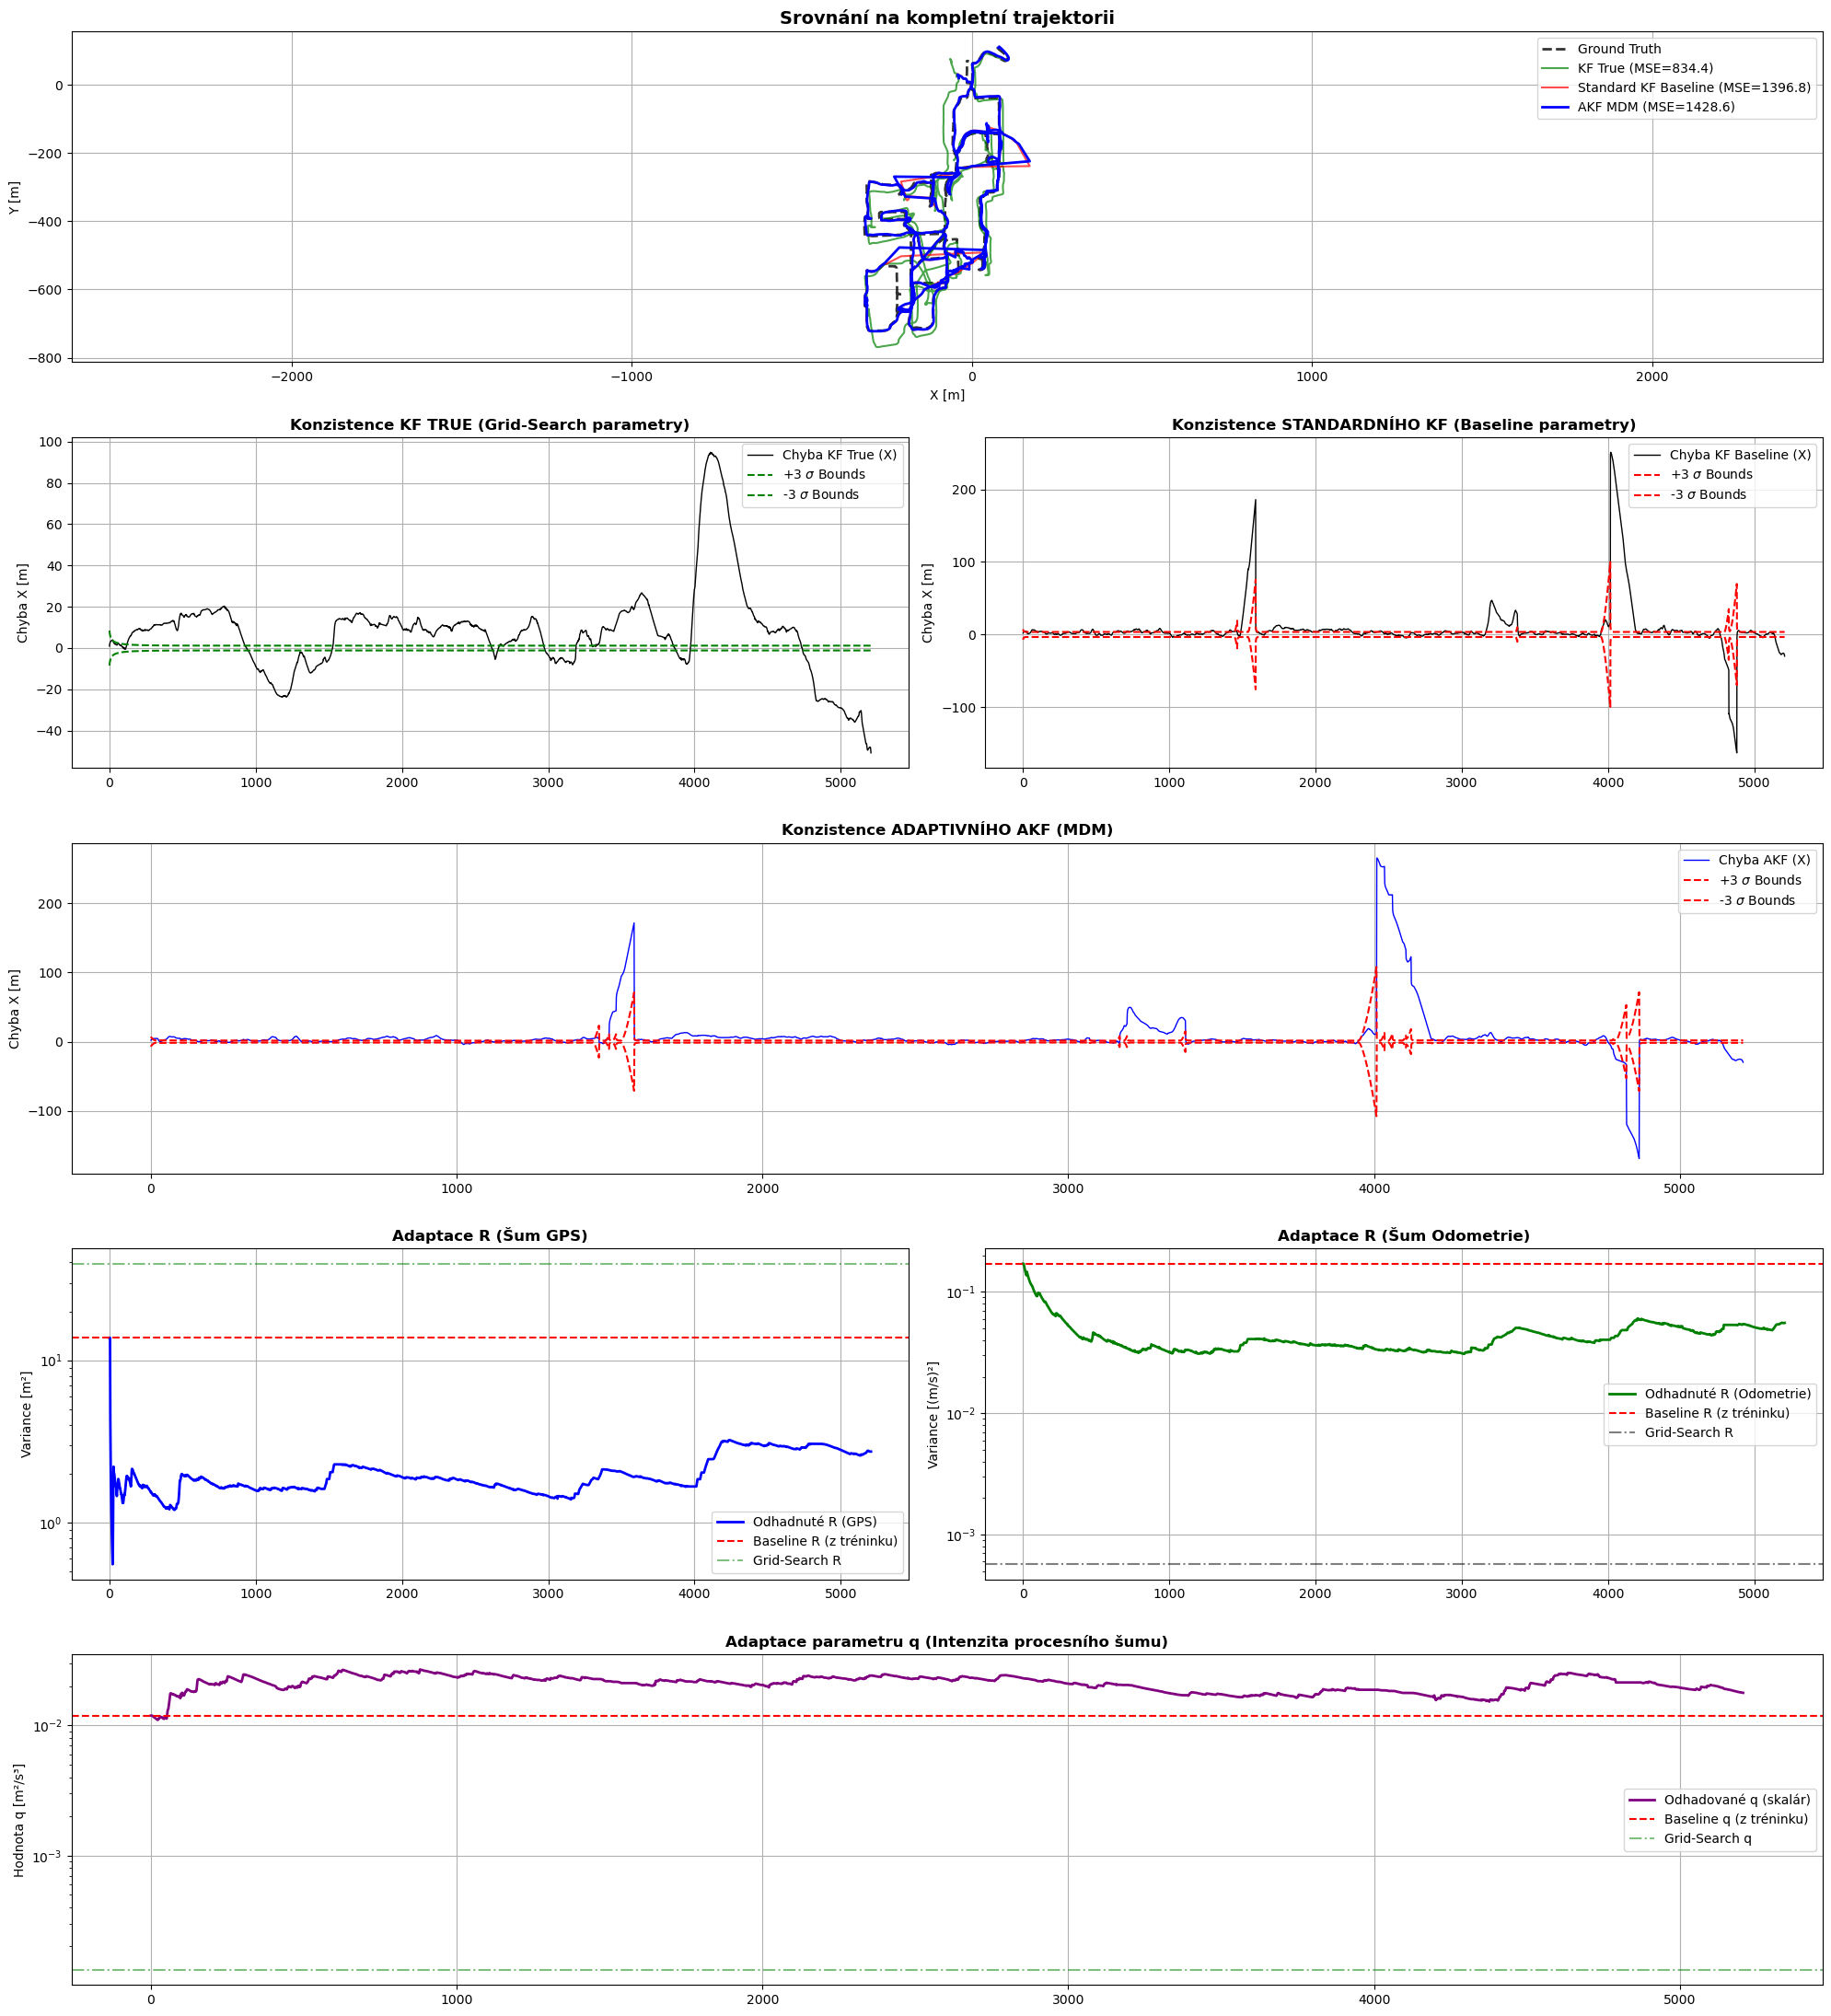

In [14]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt
import Systems
from tqdm import tqdm
from MDM.MDM_functions import MDM_nullO_LTI, Ksi_fun, baseMatrix_fun, Upsilon_2_fun, kron2_vec, kron2_mat

# Vynutíme CPU
device = torch.device("cpu")
print(f"Běžím na zařízení: {device}")

# ==============================================================================
# 0. TŘÍDY FILTRŮ S PARCIÁLNÍM GATINGEM (Ochrana proti 50m outierům)
# ==============================================================================
class KalmanFilterGated:
    def __init__(self, model):
        self.device = model.Q.device
        self.dtype = model.F.dtype
        self.model = model
        self.F, self.H, self.Q, self.R = model.F, model.H, model.Q, model.R
        self.state_dim = self.F.shape[0]
        self.obs_dim = self.H.shape[0]
        self.I = torch.eye(self.state_dim, device=self.device, dtype=self.dtype)
        self.reset(model.Ex0, model.P0)

    def reset(self, Ex0, P0):
        self.x_predict_current = Ex0.clone().detach().reshape(self.state_dim, 1)
        self.P_predict_current = P0.clone().detach()

    def step(self, y_t, gate_threshold=9.21): # 9.21 = Chi-Sq 99% limit pro 2 DOF
        rejected = False
        if y_t is not None:
            y_t_vec = y_t.reshape(self.obs_dim, 1)
            inov = y_t_vec - self.H @ self.x_predict_current
            S = self.H @ self.P_predict_current @ self.H.T + self.R
            S_inv = torch.linalg.inv(S)
            
            # --- PARCIÁLNÍ GATING (Pouze na pozici X a Y) ---
            inov_gps = torch.cat([inov[0:1], inov[2:3]], dim=0) 
            S_gps = torch.zeros((2, 2), device=self.device, dtype=self.dtype)
            S_gps[0, 0] = S[0, 0]; S_gps[0, 1] = S[0, 2]
            S_gps[1, 0] = S[2, 0]; S_gps[1, 1] = S[2, 2]
            
            S_gps_inv = torch.linalg.inv(S_gps)
            mah_sq_gps = (inov_gps.T @ S_gps_inv @ inov_gps).item()
            
            if mah_sq_gps > gate_threshold:
                rejected = True

        if y_t is None or rejected:
            # PREDICT ONLY
            x_filtered = self.x_predict_current
            P_filtered = self.P_predict_current
            K = torch.zeros((self.state_dim, self.obs_dim), device=self.device, dtype=self.dtype)
        else:
            # STANDARD UPDATE
            K = self.P_predict_current @ self.H.T @ S_inv
            x_filtered = self.x_predict_current + K @ inov
            I_KH = self.I - K @ self.H
            P_filtered = I_KH @ self.P_predict_current @ I_KH.T + K @ self.R @ K.T

        # PREDICT PRO DALŠÍ KROK
        x_predict_next = self.F @ x_filtered
        P_predict_next = self.F @ P_filtered @ self.F.T + self.Q
        
        self.x_predict_current = x_predict_next
        self.P_predict_current = P_predict_next

        return x_filtered, P_filtered, K, rejected

    def process_sequence(self, y_seq, Ex0, P0, gate_threshold=9.21):
        seq_len = y_seq.shape[0]
        self.reset(Ex0, P0)
        x_hist = torch.zeros(seq_len, self.state_dim, device=self.device, dtype=self.dtype)
        P_hist = torch.zeros(seq_len, self.state_dim, self.state_dim, device=self.device, dtype=self.dtype)
        
        for k in tqdm(range(seq_len), desc="Standard KF Gated", leave=False):
            x_f, P_f, _, _ = self.step(y_seq[k], gate_threshold)
            x_hist[k] = x_f.squeeze()
            P_hist[k] = P_f
            
        return {'x_filtered': x_hist, 'P_filtered': P_hist}

class AdaptiveKalmanFilter_online_Gated:
    def __init__(self, model, mdm_L=6, mdm_version=1, lambda_rls=0.99, init_sigma_rls_value=0.1, alpha_nom=None):
        self.kf = KalmanFilterGated(model)
        self.device, self.dtype = model.Q.device, model.Q.dtype
        self.np_dtype = np.float32 if self.dtype == torch.float32 else np.float64
        self.mdm_L, self.mdm_version, self.lambda_rls = mdm_L, mdm_version, lambda_rls
        self.nw, self.nv = self.kf.F.shape[0], self.kf.H.shape[0]
        
        self.F_np = self.kf.F.cpu().numpy().astype(self.np_dtype)
        self.H_np = self.kf.H.cpu().numpy().astype(self.np_dtype)
        self.E_np = np.eye(self.nw, dtype=self.np_dtype)
        self.D_np = np.eye(self.nv, dtype=self.np_dtype)
        self.nz_np = np.array([self.nv])
        
        self.Ksi, self.H_rls_norm, self.weights, self.HTH, self.HT = None, None, None, None, None
        
        T = 1.0
        self.Q_template = np.array([[T**3/3, T**2/2, 0, 0], [T**2/2, T, 0, 0], [0, 0, T**3/3, T**2/2], [0, 0, T**2/2, T]], dtype=self.np_dtype)
        self.vec_Q_template = self.Q_template[np.triu_indices(self.nw)][:, np.newaxis]
        self.n_params_Q_full, self.n_params_Q_reduced = (self.nw * (self.nw + 1)) // 2, 1
        self.n_params_R_full, self.n_params_R_reduced = (self.nv * (self.nv + 1)) // 2, 2
        
        self.T_R_matrix = np.zeros((self.n_params_R_full, self.n_params_R_reduced), dtype=self.np_dtype)
        self.T_R_matrix[0, 0] = self.T_R_matrix[7, 0] = self.T_R_matrix[4, 1] = self.T_R_matrix[9, 1] = 1.0 
        
        Q0, R0 = model.Q.cpu().numpy(), model.R.cpu().numpy()
        self.alpha_est = np.array([Q0[0,0] / self.Q_template[0,0], R0[0,0], R0[1,1]], dtype=self.np_dtype)
        self.alpha_nom = np.array(alpha_nom, dtype=self.np_dtype)

        sigma_q = (self.alpha_nom[0] * init_sigma_rls_value)**2 + 1e-12
        sigma_r1 = (self.alpha_nom[1] * init_sigma_rls_value)**2 + 1e-12
        sigma_r2 = (self.alpha_nom[2] * init_sigma_rls_value)**2 + 1e-12
        self.Sigma_RLS = np.diag([sigma_q, sigma_r1, sigma_r2]).astype(self.np_dtype)
        
        self.z_buffer, self.u_buffer = [], []
        self.Upsilon_2 = None

    def _get_upsilon(self):
        if self.Upsilon_2 is None:
            w2b, v2b = [baseMatrix_fun(self.nw, 1)], [baseMatrix_fun(self.nv, 1)]
            self.Upsilon_2 = Upsilon_2_fun(w2b, v2b, self.mdm_L)
        return self.Upsilon_2

    def step_adaptive(self, y_t, gate_threshold=9.21):
        x_filt, P_filt, K, rejected = self.kf.step(y_t, gate_threshold)
        
        if rejected:
            # Měření je OUTLIER. Vymažeme buffer, neadaptujeme se.
            self.z_buffer = []
            self.u_buffer = []
            return x_filt, P_filt, K, self.kf.Q, self.kf.R

        y_np = y_t.cpu().numpy().squeeze()
        if y_np.ndim == 0: y_np = np.expand_dims(y_np, axis=0)
        u_np = np.zeros(1, dtype=self.np_dtype)

        self.z_buffer.append(y_np)
        self.u_buffer.append(u_np)
        
        if len(self.z_buffer) > self.mdm_L:
            self.z_buffer.pop(0)
            self.u_buffer.pop(0)

        if len(self.z_buffer) == self.mdm_L:
            try:
                z_window = np.array(self.z_buffer, dtype=self.np_dtype)
                u_window = np.array(self.u_buffer, dtype=self.np_dtype)
                G_np = np.zeros((self.nw, 1), dtype=self.np_dtype)

                r_list, Awv_matrix = MDM_nullO_LTI(self.mdm_L, self.F_np, G_np, self.E_np, self.nz_np, self.H_np, self.D_np, z_window, u_window, self.mdm_version)
                r_k = r_list[0]
                
                if self.H_rls_norm is None:
                    self.Ksi = Ksi_fun(r_k.shape[0])
                    H_full = self.Ksi @ kron2_mat(Awv_matrix) @ self._get_upsilon()
                    H_rls = np.hstack([H_full[:, :self.n_params_Q_full] @ self.vec_Q_template, H_full[:, self.n_params_Q_full:] @ self.T_R_matrix])
                    self.weights = np.abs(H_rls @ self.alpha_nom).flatten() + 1e-12
                    self.H_rls_norm = H_rls / self.weights[:, np.newaxis]
                    self.HT = self.H_rls_norm.T
                    self.HTH = self.HT @ self.H_rls_norm

                y_rls_norm = (self.Ksi @ kron2_vec(r_k)).flatten() / self.weights
                
                P_next_unscaled = np.linalg.inv(np.linalg.inv(self.Sigma_RLS) + self.HTH)
                self.Sigma_RLS = P_next_unscaled / self.lambda_rls
                self.alpha_est += (P_next_unscaled @ self.HT) @ (y_rls_norm - self.H_rls_norm @ self.alpha_est)
                
                Q_new = max(self.alpha_est[0], 1e-10) * self.Q_template
                r1, r2 = max(self.alpha_est[1], 1e-10), max(self.alpha_est[2], 1e-10)
                R_new = np.diag([r1, r2, r1, r2])
                
                self.kf.Q = torch.from_numpy(Q_new).to(self.device).to(self.dtype)
                self.kf.R = torch.from_numpy(R_new).to(self.device).to(self.dtype)
                
            except Exception as e:
                pass

        return x_filt, P_filt, K, self.kf.Q, self.kf.R

    def process_sequence_adaptively(self, y_seq, Ex0, P0, gate_threshold=9.21):
        seq_len = y_seq.shape[0]
        self.kf.reset(Ex0, P0)
        self.z_buffer, self.u_buffer = [], []
        x_hist = torch.zeros(seq_len, self.nw, device=self.device, dtype=self.dtype)
        P_hist = torch.zeros(seq_len, self.nw, self.nw, device=self.device, dtype=self.dtype)
        Q_hist, R_hist = [], []

        for k in tqdm(range(seq_len), desc="AKF MDM Gated", leave=False):
            x, P, K, Q_curr, R_curr = self.step_adaptive(y_seq[k], gate_threshold)
            x_hist[k], P_hist[k] = x.squeeze(), P
            Q_hist.append(Q_curr.clone().detach())
            R_hist.append(R_curr.clone().detach())
            
        return {'x_filtered': x_hist, 'P_filtered': P_hist}, Q_hist, R_hist

#########################
### Design Parameters ###
#########################
m = 4 
n = 4 
delta_t = 1.0 

F_dim = torch.tensor([[1.0, delta_t], [0.0, 1.0]], dtype=torch.float64)
F_design = torch.block_diag(F_dim, F_dim).to(device)
H_design = torch.eye(n, dtype=torch.float64).to(device)

# ==============================================================================
# ZADANÉ PARAMETRY (Z tréninku / Grid-Searche)
# ==============================================================================
# Původní Grid-Search parametry (Pro KF True)
q_scale_init = 0.000132
var_gps_init = 39.32
var_odo_init = 0.00057

# Vaše "Zlaté" Baseline parametry z tréninku
baseline_q = 0.011913
baseline_r_gps = 13.7453
baseline_r_odo = 0.170883

# Sestavení matic pro KF True
Q_block_true = torch.tensor([[(delta_t**3)/3, (delta_t**2)/2], [(delta_t**2)/2,  delta_t]], dtype=torch.float64) * q_scale_init
Q_true = torch.block_diag(Q_block_true, Q_block_true).to(device)
R_true = torch.diag(torch.tensor([var_gps_init, var_odo_init, var_gps_init, var_odo_init], dtype=torch.float64)).to(device)

# Sestavení matic pro Baseline KF a AKF MDM
Q_block_base = torch.tensor([[(delta_t**3)/3, (delta_t**2)/2], [(delta_t**2)/2,  delta_t]], dtype=torch.float64) * baseline_q
Q_base = torch.block_diag(Q_block_base, Q_block_base).to(device)
R_base = torch.diag(torch.tensor([baseline_r_gps, baseline_r_odo, baseline_r_gps, baseline_r_odo], dtype=torch.float64)).to(device)

# ==============================================================================
# NAČTENÍ KOMPLETNÍ TRAJEKTORIE
# ==============================================================================
print("\n--- NAČÍTÁNÍ KOMPLETNÍ TRAJEKTORIE ---")
full_traj_path = '../preprocessed_NCLT_FULL/test_full_trajectory.pt' 
full_dataset = torch.load(full_traj_path)[0]

full_gt = full_dataset['ground_truth'].to(device).double()
full_meas = full_dataset['filtered_gps'].to(device).double()
seq_len = full_meas.shape[0]
print(f"Délka sekvence: {seq_len} kroků")

# Počáteční podmínky (Startujeme ze skutečné pozice)
m1x_0 = full_gt[0].unsqueeze(1)
m2x_0 = torch.diag(torch.tensor([10.0, 1.0, 10.0, 1.0], dtype=torch.float64)).to(device)

# === INICIALIZACE SYSTÉMŮ ===
sys_true = Systems.DynamicSystem(
    state_dim=m, obs_dim=n, Ex0=m1x_0, P0=m2x_0,
    Q=Q_true, R=R_true, F=F_design, H=H_design, device=device
)

sys_model = Systems.DynamicSystem(
    state_dim=m, obs_dim=n, Ex0=m1x_0, P0=m2x_0,
    Q=Q_base, R=R_base, F=F_design, H=H_design, device=device
)

# ==============================================================================
# SPUŠTĚNÍ FILTRŮ S GATINGEM
# ==============================================================================
print("\n--- SPUŠTĚNÍ FILTRŮ NA PLNÉ TRAJEKTORII (S GATINGEM 9.21) ---")
gate_thresh = 50.0

# 1. KF True (s původními Grid-Search parametry)
print("1. Spouštím KF True Gated (Grid-Search)...")
kf_true_filter = KalmanFilter(sys_true) 
res_kf_true = kf_true_filter.process_sequence(full_meas, Ex0=m1x_0, P0=m2x_0)

# 2. Standardní KF (s naučenými Baseline parametrami)
print("2. Spouštím Standardní KF Gated (Baseline)...")
kf_filter = KalmanFilterGated(sys_model) 
res_kf = kf_filter.process_sequence(full_meas, Ex0=m1x_0, P0=m2x_0, gate_threshold=gate_thresh)

# 3. AKF MDM
print("3. Spouštím AKF MDM Gated (Adaptivní)...")
akf_filter = AdaptiveKalmanFilter_online_Gated(
    sys_model, 
    mdm_L=6, 
    mdm_version=1,
    lambda_rls=0.999,
    init_sigma_rls_value=0.1,
    alpha_nom=[baseline_q, baseline_r_gps, baseline_r_odo] 
    # alpha_nom=[q_scale_init, var_gps_init, var_odo_init] 
)

res_akf, Q_hist_test, R_hist_test = akf_filter.process_sequence_adaptively(full_meas, Ex0=m1x_0, P0=m2x_0, gate_threshold=gate_thresh)

# ==============================================================================
# VYHODNOCENÍ METRIK
# ==============================================================================
x_est_kf_true = res_kf_true['x_filtered'].detach().cpu().numpy()
x_est_kf = res_kf['x_filtered'].detach().cpu().numpy()
x_est_akf = res_akf['x_filtered'].detach().cpu().numpy()
gt_np = full_gt.detach().cpu().numpy()

def calc_metrics(est, gt):
    mse_x = np.mean((est[:, 0] - gt[:, 0])**2)
    mse_y = np.mean((est[:, 2] - gt[:, 2])**2)
    total_mse = mse_x + mse_y
    rmse = np.sqrt(total_mse)
    return total_mse, rmse

mse_kf_true, rmse_kf_true = calc_metrics(x_est_kf_true, gt_np)
mse_kf, rmse_kf = calc_metrics(x_est_kf, gt_np)
mse_akf, rmse_akf = calc_metrics(x_est_akf, gt_np)

print("\n" + "="*60)
print(f"VÝSLEDKY NA KOMPLETNÍ TRAJEKTORII ({seq_len} kroků):")
print(f"KF True (Grid-Search parametry) -> MSE: {mse_kf_true:.4f} | RMSE: {rmse_kf_true:.4f} m")
print(f"Standardní KF (Baseline)        -> MSE: {mse_kf:.4f} | RMSE: {rmse_kf:.4f} m")
print(f"AKF MDM (Adaptivní)             -> MSE: {mse_akf:.4f} | RMSE: {rmse_akf:.4f} m")
print("="*60)

# ==============================================================================
# VIZUALIZACE 
# ==============================================================================
T_sampling = 1.0
template_val_00 = (T_sampling**3) / 3.0
q_est_values = np.array([q[0, 0].item() for q in Q_hist_test]) / template_val_00
r_gps_hist = np.array([r[0, 0].item() for r in R_hist_test]) 
r_odo_hist = np.array([r[1, 1].item() for r in R_hist_test]) 

t_full = np.arange(seq_len)
t_akf = t_full[-len(r_gps_hist):] 

P_est_kf_true = res_kf_true['P_filtered'].detach().cpu().numpy()
P_est_kf = res_kf['P_filtered'].detach().cpu().numpy()
P_est_akf = res_akf['P_filtered'].detach().cpu().numpy()

error_x_kf_true = x_est_kf_true[:, 0] - gt_np[:, 0]
sigma_x_kf_true = np.sqrt(P_est_kf_true[:, 0, 0])

error_x_kf = x_est_kf[:, 0] - gt_np[:, 0]
sigma_x_kf = np.sqrt(P_est_kf[:, 0, 0])

error_x_akf = x_est_akf[:, 0] - gt_np[:, 0]
sigma_x_akf = np.sqrt(P_est_akf[:, 0, 0])

fig = plt.figure(figsize=(20, 22))
gs = fig.add_gridspec(5, 2)

# A) Trajektorie
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(gt_np[:, 0], gt_np[:, 2], 'k--', label='Ground Truth', linewidth=2, alpha=0.8)
ax1.plot(x_est_kf_true[:, 0], x_est_kf_true[:, 2], 'g-', label=f'KF True (MSE={mse_kf_true:.1f})', linewidth=1.5, alpha=0.7)
ax1.plot(x_est_kf[:, 0], x_est_kf[:, 2], 'r-', label=f'Standard KF Baseline (MSE={mse_kf:.1f})', linewidth=1.5, alpha=0.7)
ax1.plot(x_est_akf[:, 0], x_est_akf[:, 2], 'b-', label=f'AKF MDM (MSE={mse_akf:.1f})', linewidth=2)
ax1.set_title(f'Srovnání na kompletní trajektorii', fontweight='bold', fontsize=14)
ax1.set_xlabel('X [m]')
ax1.set_ylabel('Y [m]')
ax1.legend()
ax1.axis('equal')
ax1.grid(True)

# B1) Konzistence KF True
ax2_kf_true = fig.add_subplot(gs[1, 0])
ax2_kf_true.plot(t_full, error_x_kf_true, 'k-', label='Chyba KF True (X)', linewidth=1)
ax2_kf_true.plot(t_full, 3*sigma_x_kf_true, 'g--', label='+3 $\sigma$ Bounds')
ax2_kf_true.plot(t_full, -3*sigma_x_kf_true, 'g--', label='-3 $\sigma$ Bounds')
ax2_kf_true.set_title('Konzistence KF TRUE (Grid-Search parametry)', fontweight='bold')
ax2_kf_true.set_ylabel('Chyba X [m]')
ax2_kf_true.legend()
ax2_kf_true.grid(True)

# B2) Konzistence Standardní KF (Baseline)
ax2_kf = fig.add_subplot(gs[1, 1])
ax2_kf.plot(t_full, error_x_kf, 'k-', label='Chyba KF Baseline (X)', linewidth=1)
ax2_kf.plot(t_full, 3*sigma_x_kf, 'r--', label='+3 $\sigma$ Bounds')
ax2_kf.plot(t_full, -3*sigma_x_kf, 'r--', label='-3 $\sigma$ Bounds')
ax2_kf.set_title('Konzistence STANDARDNÍHO KF (Baseline parametry)', fontweight='bold')
ax2_kf.set_ylabel('Chyba X [m]')
ax2_kf.legend()
ax2_kf.grid(True)

# B3) Konzistence AKF (MDM) 
ax2_akf = fig.add_subplot(gs[2, :])
ax2_akf.plot(t_full, error_x_akf, 'b-', label='Chyba AKF (X)', linewidth=1)
ax2_akf.plot(t_full, 3*sigma_x_akf, 'r--', label='+3 $\sigma$ Bounds')
ax2_akf.plot(t_full, -3*sigma_x_akf, 'r--', label='-3 $\sigma$ Bounds')
ax2_akf.set_title('Konzistence ADAPTIVNÍHO AKF (MDM)', fontweight='bold')
ax2_akf.set_ylabel('Chyba X [m]')
ax2_akf.legend()
ax2_akf.grid(True)

# C) Adaptace R
ax3 = fig.add_subplot(gs[3, 0])
ax3.plot(t_akf, r_gps_hist, 'b-', label='Odhadnuté R (GPS)', linewidth=2)
ax3.axhline(baseline_r_gps, color='r', linestyle='--', label='Baseline R (z tréninku)')
ax3.axhline(var_gps_init, color='g', linestyle='-.', alpha=0.5, label='Grid-Search R')
ax3.set_title('Adaptace R (Šum GPS)', fontweight='bold')
ax3.set_ylabel('Variance [m²]')
ax3.set_yscale('log') 
ax3.legend()
ax3.grid(True)

ax4 = fig.add_subplot(gs[3, 1])
ax4.plot(t_akf, r_odo_hist, 'g-', label='Odhadnuté R (Odometrie)', linewidth=2)
ax4.axhline(baseline_r_odo, color='r', linestyle='--', label='Baseline R (z tréninku)')
ax4.axhline(var_odo_init, color='k', linestyle='-.', alpha=0.5, label='Grid-Search R')
ax4.set_title('Adaptace R (Šum Odometrie)', fontweight='bold')
ax4.set_ylabel('Variance [(m/s)²]')
ax4.set_yscale('log')
ax4.legend()
ax4.grid(True)

# D) Adaptace q
ax5 = fig.add_subplot(gs[4, :])
ax5.plot(t_akf, q_est_values, 'purple', label='Odhadované q (skalár)', linewidth=2)
ax5.axhline(baseline_q, color='r', linestyle='--', label=f'Baseline q (z tréninku)')
ax5.axhline(q_scale_init, color='g', linestyle='-.', alpha=0.5, label='Grid-Search q')
ax5.set_title('Adaptace parametru q (Intenzita procesního šumu)', fontweight='bold')
ax5.set_ylabel('Hodnota q [m²/s³]') 
ax5.set_yscale('log')
ax5.legend()
ax5.grid(True)

plt.tight_layout()
plt.show()

# Mehra na real datech

In [15]:
import torch
import numpy as np
from tqdm import tqdm

class AdaptiveKalmanFilter_mehra:
    def __init__(self, model, window_size=200):
        self.model = model
        self.dtype = model.F.dtype
        self.device = model.Q.device
        
        self.nx = self.model.F.shape[0]
        self.nz = self.model.H.shape[0]
        
        # Nastavení velikosti blokového okna
        self.window_size = window_size
        self.inov_buffer = []
        
        self.reset()

    def reset(self, Ex0=None, P0=None):
        """Vymaže buffery a zresetuje vnitřní stav před novou trajektorií."""
        if Ex0 is None: Ex0 = self.model.Ex0
        if P0 is None: P0 = self.model.P0
            
        self.x_predict = Ex0.clone().detach().reshape(self.nx, 1)
        self.inov_buffer = []
        
        # 1. Zvolme stabilní K lineárního filtru
        self.K = 0.5 * torch.linalg.pinv(self.model.H)
    
    def step(self, y_t):
        y_t = y_t.reshape(self.nz, 1)
        
        inov = y_t - self.model.H @ self.x_predict
        
        # Přidání nové inovace do okna
        self.inov_buffer.append(inov)
            
        N_current = len(self.inov_buffer)
        
        # Výpočet matic proběhne až po úplném naplnění bloku
        if N_current >= self.window_size:
            inov_tensor = torch.cat(self.inov_buffer, dim=1)
            
            # Odhad kovariancí pro l=0
            Py0 = (inov_tensor @ inov_tensor.T) / N_current
            
            Py_list = [Py0] 
            
            # Spočítáme \hat{P}_l^y podle rovnice (22)
            for l in range(1, self.nx + 10):
                inov_shift = inov_tensor[:, l:]
                inov_orig = inov_tensor[:, :-l]
                Py_l = (inov_shift @ inov_orig.T) / (N_current - l)
                Py_list.append(Py_l)
                
            G_list = []
            V_list = [] 
            
            F = self.model.F
            H = self.model.H
            K = self.K
            
            # Sestavení G podle rovnice (21) a matici V podle (23)
            for l in range(1, self.nx + 10):
                # Matice G: G_l = H * F^l
                G_l = H @ torch.matrix_power(F, l)
                G_list.append(G_l)
                
                # Matice V (Rovnice 23): Každý řádek je součet
                V_l = Py_list[l].clone()
                for i in range(1, l + 1):
                    term = H @ torch.matrix_power(F, i) @ K @ Py_list[l - i]
                    V_l += term
                V_list.append(V_l)
                
            G = torch.cat(G_list, dim=0)
            V = torch.cat(V_list, dim=0)
            
            # Odhad součinu P^e * H^T podle rovnice (23)
            PHT = torch.linalg.pinv(G) @ V
            
            # Odhad Kalmanova zisku
            Py0_inv = torch.linalg.pinv(Py0 + 1e-6 * torch.eye(self.nz, device=self.device,dtype=self.dtype))
            K_est = PHT @ Py0_inv
            
            if not (torch.isnan(K_est).any() or torch.isinf(K_est).any()):
                A_test = F - F @ K_est @ H
                eigvals = torch.linalg.eigvals(A_test)
                max_eig = torch.max(torch.abs(eigvals))
                
                if max_eig < 1.0:
                    self.K = K_est
                else:
                    # Statistická odchylka v tomto bloku způsobila nestabilitu.
                    # Zisk nezměníme a jedeme dál s předchozím stabilním K.
                    pass
            
            # --- ZMĚNA ZPĚT: Vyprázdnění bufferu pro čistě blokový přístup ---
            self.inov_buffer = []
            
        # Filtrace a predikce na další krok
        x_filtered = self.x_predict + self.K @ inov
        self.x_predict = self.model.F @ x_filtered
        
        return x_filtered, self.K

    def process_sequence(self, y_seq, Ex0=None, P0=None):
        seq_len = y_seq.shape[0]
        
        self.reset(Ex0, P0)
        
        x_filtered_history = torch.zeros(seq_len, self.nx, device=self.device,dtype=self.dtype)
        P_filtered_history = torch.zeros(seq_len, self.nx, self.nx, device=self.device,dtype=self.dtype)
        kalman_gain_history = torch.zeros(seq_len, self.nx, self.nz, device=self.device,dtype=self.dtype)
        innovation_history = torch.zeros(seq_len, self.nz, device=self.device,dtype=self.dtype)
        
        for k in tqdm(range(seq_len), desc="Online filtrace s adaptivním K", leave=False):
            z_t = y_seq[k].reshape(self.nz, 1)
            inov_k = z_t - self.model.H @ self.x_predict
            
            x_filtered, K_current = self.step(y_seq[k])
            
            x_filtered_history[k] = x_filtered.squeeze()
            kalman_gain_history[k] = K_current
            innovation_history[k] = inov_k.squeeze()
            
        return {
            'x_filtered': x_filtered_history,
            'P_filtered': P_filtered_history,
            'Kalman_gain': kalman_gain_history,
            'innovation': innovation_history
        }

Běžím na zařízení: cpu

Inicializuji systém dle OPTIMALIZOVANÝCH parametrů (NCLT)...
Dimenze stavu: 4, Dimenze měření: 4
Q scale: 0.00012224
R diagonal: tensor([3.9275e+01, 5.6600e-04, 3.9275e+01, 5.6600e-04], device='cuda:0',
       dtype=torch.float64)

Spouštím standardní KF na syntetických datech...


KF dokončen.


Processing sequence adaptively: 100%|██████████| 522/522 [00:15<00:00, 34.44it/s]



Spouštím AKF Mehra (Online) na syntetických datech...


AKF Mehra (Online) dokončen.

Spouštím AKF Mehra (Offline) na syntetických datech...

--- Offline Mehra: Start adaptace ---
Iterace 0 (Nástřel): K[0,0] = 0.1000


AKF Mehra (Offline) dokončen.

VÝSLEDKY NA SYNTETICKÝCH DATECH:
Standardní KF     -> MSE: 145.2387 | RMSE: 12.0515 m
AKF Mehra Online  -> MSE: 42.1720 | RMSE: 6.4940 m
AKF               -> MSE: 47.1490 | RMSE: 6.8665 m
AKF Mehra Offline -> MSE: 42.2772 | RMSE: 6.5021 m


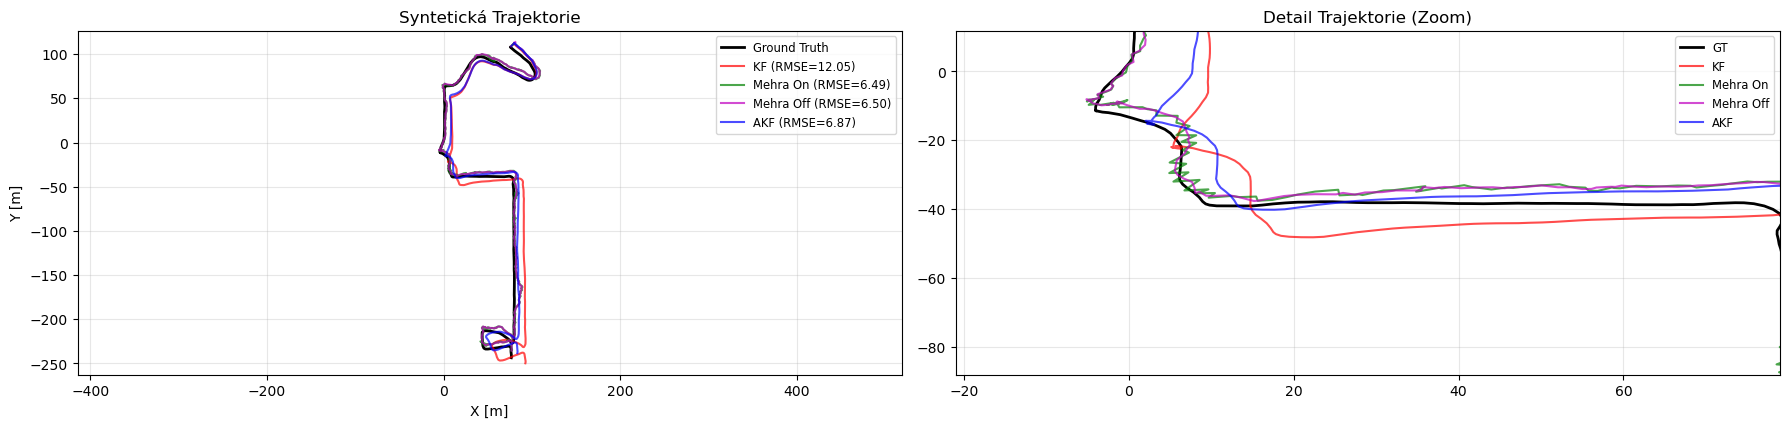


Generuji detailní grafy vývoje Kalmanovy matice K...


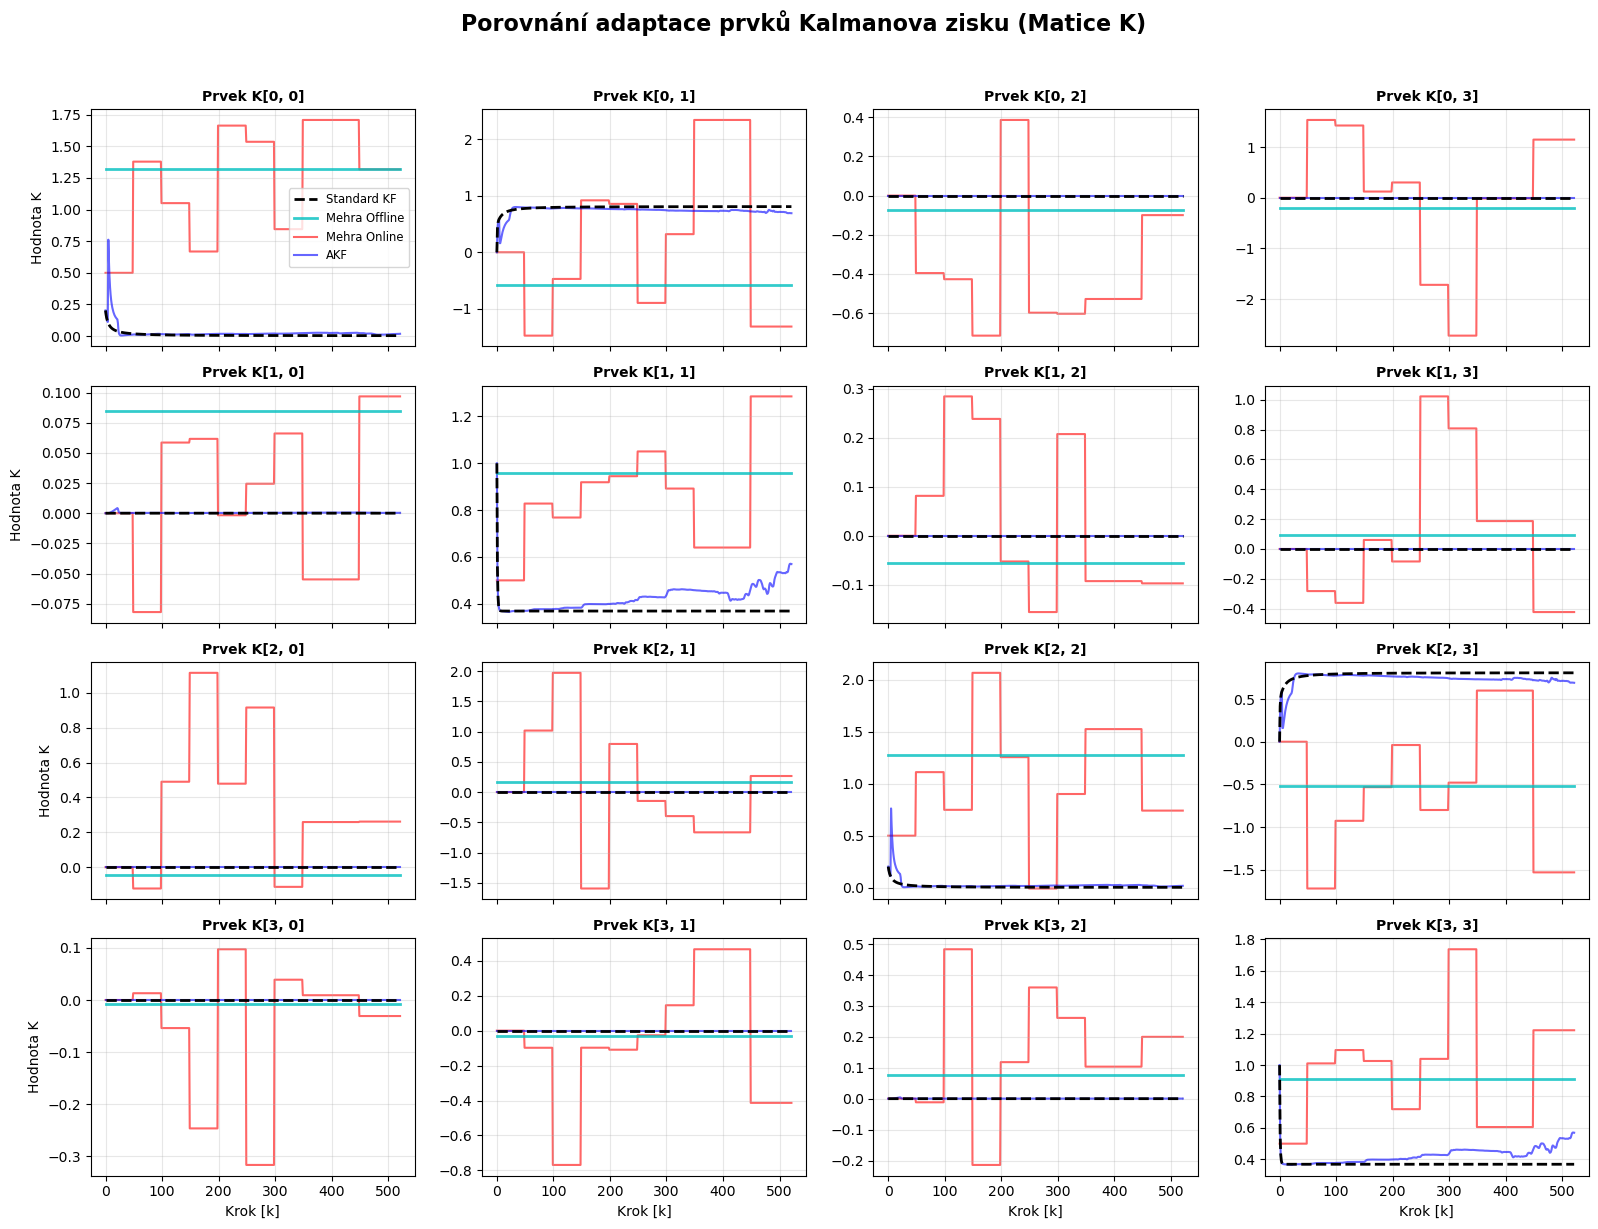

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from MDM.MDM_functions import MDM_nullO_LTI, Ksi_fun, baseMatrix_fun, Upsilon_2_fun, kron2_vec, kron2_mat

# Vynutíme CPU
device = torch.device("cpu")
print(f"Běžím na zařízení: {device}")

# ==============================================================================
# 1. DEFINICE SYSTÉMU A NAČTENÍ DAT
# ==============================================================================
import Systems
import torch
import math
import Systems 

# Nastavení zařízení
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#########################
### Design Parameters ###
### (OPTIMALIZOVANÉ)  ###
#########################

# 1. Rozměry
# Stav: [px, vx, py, vy]
m = 4 
n = 4 
delta_t = 1.0 

# 2. Dynamika (F)
# x_{t+1} = x_t + v_t * dt
F_dim = torch.tensor([[1.0, delta_t],
                      [0.0, 1.0]], dtype=torch.float64)

# ZMĚNA: .float() nahrazeno .double() (nebo definováno rovnou v dtype)
F_design = torch.block_diag(F_dim, F_dim).to(device)

# 3. Měření (H)
H_design = torch.eye(n, dtype=torch.float64).to(device)

# ==========================================
# 4. Šum procesu (Q) - OPTIMALIZOVÁNO
# ==========================================
# grid search:
q_scale = 0.00012224

Q_block_val = torch.tensor([
    [(delta_t**3)/3, (delta_t**2)/2],
    [(delta_t**2)/2,  delta_t      ]
], dtype=torch.float64) * q_scale

# ZMĚNA: .float() nahrazeno
Q_design = torch.block_diag(Q_block_val, Q_block_val).to(device)


# ==========================================
# 5. Šum měření (R) - OPTIMALIZOVÁNO
# ==========================================
#grid search:
var_gps = 39.275433
var_odo = 0.000566

R_design = torch.tensor([
    [var_gps, 0.0,     0.0,     0.0],
    [0.0,     var_odo, 0.0,     0.0],
    [0.0,     0.0,     var_gps, 0.0],
    [0.0,     0.0,     0.0,     var_odo]
], dtype=torch.float64).to(device)

# 6. Počáteční podmínky
m1x_0 = torch.zeros(m, 1, dtype=torch.float64).to(device)
m2x_0 = torch.diag(torch.tensor([10.0, 1.0, 10.0, 1.0], dtype=torch.float64)).to(device) 

print("\nInicializuji systém dle OPTIMALIZOVANÝCH parametrů (NCLT)...")
print(f"Dimenze stavu: {m}, Dimenze měření: {n}")
print(f"Q scale: {q_scale}")
print(f"R diagonal: {torch.diagonal(R_design)}")

# === INICIALIZACE SYSTÉMŮ ===

sys_true = Systems.DynamicSystem(
    state_dim=m, obs_dim=n,
    Ex0=m1x_0, P0=m2x_0,
    Q=Q_design, R=R_design,
    F=F_design, H=H_design,
    device=device
)

sys_model = Systems.DynamicSystem(
    state_dim=m, obs_dim=n,
    Ex0=m1x_0, P0=m2x_0,
    Q=Q_design, R=R_design,
    F=F_design, H=H_design,
    device=device
)

# Upravte cesty
test_path = '../preprocessed_NCLT_trajectory-2012-01-22-angle-update/test.pt' 

test_gt = torch.load(test_path)[0]['ground_truth'].to(device).double()
test_meas = torch.load(test_path)[0]['filtered_gps'].to(device).double()

m1x_0_test = test_gt[0].unsqueeze(1).double()
# ==============================================================================
# 2. SPUŠTĚNÍ FILTRŮ
# ==============================================================================

kf_filter = Filters.KalmanFilter(sys_true)
res_kf = kf_filter.process_sequence(test_meas, Ex0=m1x_0_test, P0=sys_true.P0)
print("KF dokončen.")


alpha_nominal = [0.000132, 39.32, 0.00057]

akf_filter = Filters.AdaptiveKalmanFilter_online(
    sys_model, 
    mdm_L=6, 
    mdm_version=1, 
    lambda_rls=0.99, 
    init_sigma_rls_value=0.5, 
    
    alpha_nom=alpha_nominal
)

res_akf,_,_ = akf_filter.process_sequence_adaptively(test_meas, Ex0=m1x_0_test, P0=sys_true.P0)
# print("AKF dokončen.")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

akf_mehra_online = AdaptiveKalmanFilter_mehra(sys_true, window_size=50)
res_akf_mehra = akf_mehra_online.process_sequence(test_meas, Ex0=m1x_0_test, P0=sys_true.P0)
print("AKF Mehra (Online) dokončen.")

akf_mehra_offline = Filters.AdaptiveKalmanFilter_mehra_offline(sys_true, num_iterations=10)
res_akf_mehra_offline = akf_mehra_offline.process_sequence(test_meas, Ex0=m1x_0_test, P0=sys_true.P0)
print("AKF Mehra (Offline) dokončen.")


# ==============================================================================
# 3. VYHODNOCENÍ METRIK
# ==============================================================================
x_gt_np = test_gt.detach().cpu().numpy()
y_meas_np = test_meas.detach().cpu().numpy()

x_est_kf = res_kf['x_filtered'].detach().cpu().numpy()
x_est_mehra_on = res_akf_mehra['x_filtered'].detach().cpu().numpy()
x_est_mehra_off = res_akf_mehra_offline['x_filtered'].detach().cpu().numpy()
x_est_akf = res_akf['x_filtered'].detach().cpu().numpy()
def calc_metrics(est, gt):
    mse_x = np.mean((est[:, 0] - gt[:, 0])**2)
    mse_y = np.mean((est[:, 2] - gt[:, 2])**2)
    total_mse = mse_x + mse_y
    rmse = np.sqrt(total_mse)
    return total_mse, rmse

mse_kf, rmse_kf = calc_metrics(x_est_kf, x_gt_np)
mse_mehra_on, rmse_mehra_on = calc_metrics(x_est_mehra_on, x_gt_np)
mse_mehra_off, rmse_mehra_off = calc_metrics(x_est_mehra_off, x_gt_np)
mse_akf, rmse_akf = calc_metrics(x_est_akf, x_gt_np)

print("\n" + "="*60)
print(f"VÝSLEDKY NA SYNTETICKÝCH DATECH:")
print(f"Standardní KF     -> MSE: {mse_kf:.4f} | RMSE: {rmse_kf:.4f} m")
print(f"AKF Mehra Online  -> MSE: {mse_mehra_on:.4f} | RMSE: {rmse_mehra_on:.4f} m")
print(f"AKF               -> MSE: {mse_akf:.4f} | RMSE: {rmse_akf:.4f} m")
print(f"AKF Mehra Offline -> MSE: {mse_mehra_off:.4f} | RMSE: {rmse_mehra_off:.4f} m")
print("="*60)


# ==============================================================================
# 5. VYKRESLENÍ GRAFŮ (TRAJEKTORIE A ŠUMY)
# ==============================================================================
plt.figure(figsize=(18, 12))

# 1. Trajektorie X-Y
plt.subplot(3, 2, 1)
plt.plot(x_gt_np[:, 0], x_gt_np[:, 2], 'k-', linewidth=2, label='Ground Truth')
plt.plot(x_est_kf[:, 0], x_est_kf[:, 2], 'r-', linewidth=1.5, alpha=0.7, label=f'KF (RMSE={rmse_kf:.2f})')
plt.plot(x_est_mehra_on[:, 0], x_est_mehra_on[:, 2], 'g-', linewidth=1.5, alpha=0.7, label=f'Mehra On (RMSE={rmse_mehra_on:.2f})')
plt.plot(x_est_mehra_off[:, 0], x_est_mehra_off[:, 2], 'm-', linewidth=1.5, alpha=0.7, label=f'Mehra Off (RMSE={rmse_mehra_off:.2f})')
plt.plot(x_est_akf[:, 0], x_est_akf[:, 2], 'b-', linewidth=1.5, alpha=0.7, label=f'AKF (RMSE={rmse_akf:.2f})')
plt.title("Syntetická Trajektorie")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.legend(fontsize='small')
plt.grid(True, alpha=0.3)
plt.axis('equal')

# 2. Detail Trajektorie
plt.subplot(3, 2, 2)
mid = len(x_gt_np)//2
span = 50
plt.plot(x_gt_np[:, 0], x_gt_np[:, 2], 'k-', linewidth=2, label='GT')
plt.plot(x_est_kf[:, 0], x_est_kf[:, 2], 'r-', alpha=0.7, label='KF')
plt.plot(x_est_mehra_on[:, 0], x_est_mehra_on[:, 2], 'g-', alpha=0.7, label='Mehra On')
plt.plot(x_est_mehra_off[:, 0], x_est_mehra_off[:, 2], 'm-', alpha=0.7, label='Mehra Off')
plt.plot(x_est_akf[:, 0], x_est_akf[:, 2], 'b-', alpha=0.7, label='AKF')
plt.xlim(x_gt_np[mid, 0]-span, x_gt_np[mid, 0]+span)
plt.ylim(x_gt_np[mid, 2]-span, x_gt_np[mid, 2]+span)
plt.title("Detail Trajektorie (Zoom)")
plt.legend(fontsize='small')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ==============================================================================
# 6. VIZUALIZACE VÝVOJE KALMANOVA ZISKU (MATICE K)
# ==============================================================================
print("\nGeneruji detailní grafy vývoje Kalmanovy matice K...")

K_kf = res_kf['Kalman_gain'].detach().cpu().numpy()
K_mehra_on = res_akf_mehra['Kalman_gain'].detach().cpu().numpy()
K_mehra_off = res_akf_mehra_offline['Kalman_gain'].detach().cpu().numpy()
K_akf = res_akf['Kalman_gain'].detach().cpu().numpy()

seq_len_K = K_kf.shape[0]
nx = K_kf.shape[1]
nz = K_kf.shape[2]
t_full = np.arange(seq_len_K)

fig_K, axes_K = plt.subplots(nx, nz, figsize=(4 * nz, 3 * nx), sharex=True)

if nx == 1 and nz == 1:
    axes_K = np.array([[axes_K]])
elif nx == 1:
    axes_K = axes_K[np.newaxis, :]
elif nz == 1:
    axes_K = axes_K[:, np.newaxis]

for i in range(nx):
    for j in range(nz):
        ax = axes_K[i, j]
        
        ax.plot(t_full, K_kf[:, i, j], 'k--', label='Standard KF', linewidth=2, zorder=4)
        ax.plot(t_full, K_mehra_off[:, i, j], 'c-', label='Mehra Offline', linewidth=2, alpha=0.8, zorder=3)
        ax.plot(t_full, K_mehra_on[:, i, j], 'r-', label='Mehra Online', linewidth=1.5, alpha=0.6, zorder=1)
        ax.plot(t_full, K_akf[:, i, j], 'b-', label='AKF', linewidth=1.5, alpha=0.6, zorder=2)

        ax.set_title(f'Prvek K[{i}, {j}]', fontweight='bold', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        if j == 0:
            ax.set_ylabel('Hodnota K')
        if i == nx - 1:
            ax.set_xlabel('Krok [k]')
        if i == 0 and j == 0:
            ax.legend(loc='best', fontsize='small')

plt.suptitle('Porovnání adaptace prvků Kalmanova zisku (Matice K)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Generuji grafy vývoje odhadnutých parametrů Q a R (q, r_gps, r_odo)...
  (Znovu spouštím MDM pro extrakci historie Q a R...)


Processing sequence adaptively: 100%|██████████| 522/522 [00:16<00:00, 30.94it/s]



KONTROLA KONVERGENCE MDM ALGORITMU K NOMINÁLNÍM HODNOTÁM:
1. Šum procesu (q_scale):
   Nominální (Skutečná): 0.000122
   Odhad MDM (Konec):    0.001235
   Chyba odhadu:         910.05 %
----------------------------------------------------------------------
2. Šum GPS (var_gps):
   Nominální (Skutečná): 39.275433
   Odhad MDM (Konec):    3.624725
   Chyba odhadu:         90.77 %
----------------------------------------------------------------------
3. Šum Odometrie (var_odo):
   Nominální (Skutečná): 0.000566
   Odhad MDM (Konec):    0.001634
   Chyba odhadu:         188.74 %


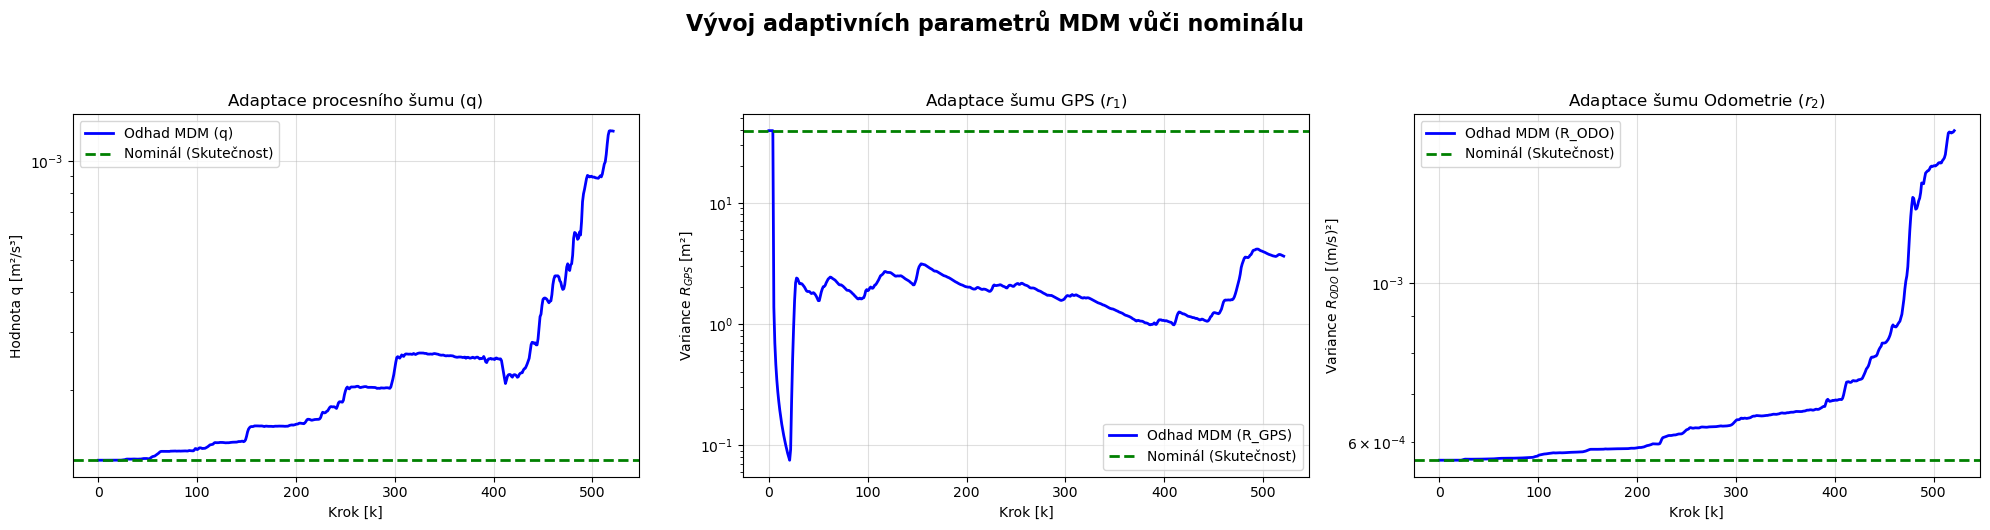

In [17]:
# ==============================================================================
# 7. VYKRESLENÍ VÝVOJE MATIC Q A R V ČASE A SROVNÁNÍ S NOMINÁLEM
# ==============================================================================
print("\nGeneruji grafy vývoje odhadnutých parametrů Q a R (q, r_gps, r_odo)...")

# Musíme zavolat res_akf znovu, protože jsme minule vyhodili _, _ (Q_hist, R_hist)
# Jen pro jistotu, kdybyste zapomněli změnit definici ve svém bloku výše,
# spustíme to tu znovu a vytáhneme si Q a R historie.
print("  (Znovu spouštím MDM pro extrakci historie Q a R...)")
akf_filter.kf.reset(m1x_0_test, sys_true.P0)
_, Q_hist, R_hist = akf_filter.process_sequence_adaptively(test_meas, Ex0=m1x_0_test, P0=sys_true.P0)

# Výpočet základu (template) pro získání čistého skaláru q
T_sampling = delta_t
template_val_00 = (T_sampling**3) / 3.0

# Extrakce hodnot z historie do NumPy polí
q_est_values = np.array([q[0, 0].item() for q in Q_hist]) / template_val_00
r_gps_hist = np.array([r[0, 0].item() for r in R_hist]) 
r_odo_hist = np.array([r[1, 1].item() for r in R_hist]) 

# Časová osa (jen pro délku historie, protože buffer na začátku chvilku nabíhá)
t_akf = np.arange(len(q_est_values))

# --- 7a. VÝPIS DO KONZOLE (Srovnání odhadu s nominálem) ---
q_final = q_est_values[-1]
r_gps_final = r_gps_hist[-1]
r_odo_final = r_odo_hist[-1]

print("\n" + "="*70)
print("KONTROLA KONVERGENCE MDM ALGORITMU K NOMINÁLNÍM HODNOTÁM:")
print("="*70)
print(f"1. Šum procesu (q_scale):")
print(f"   Nominální (Skutečná): {q_scale:.6f}")
print(f"   Odhad MDM (Konec):    {q_final:.6f}")
print(f"   Chyba odhadu:         {abs(q_scale - q_final) / q_scale * 100:.2f} %")
print("-" * 70)
print(f"2. Šum GPS (var_gps):")
print(f"   Nominální (Skutečná): {var_gps:.6f}")
print(f"   Odhad MDM (Konec):    {r_gps_final:.6f}")
print(f"   Chyba odhadu:         {abs(var_gps - r_gps_final) / var_gps * 100:.2f} %")
print("-" * 70)
print(f"3. Šum Odometrie (var_odo):")
print(f"   Nominální (Skutečná): {var_odo:.6f}")
print(f"   Odhad MDM (Konec):    {r_odo_final:.6f}")
print(f"   Chyba odhadu:         {abs(var_odo - r_odo_final) / var_odo * 100:.2f} %")
print("="*70)

# --- 7b. VYKRESLENÍ GRAFŮ ---
fig_params, axes = plt.subplots(1, 3, figsize=(20, 5))
fig_params.suptitle("Vývoj adaptivních parametrů MDM vůči nominálu", fontsize=16, fontweight='bold', y=1.05)

# Graf 1: Šum modelu (q)
axes[0].plot(t_akf, q_est_values, 'b-', linewidth=2, label='Odhad MDM (q)')
axes[0].axhline(q_scale, color='g', linestyle='--', linewidth=2, label='Nominál (Skutečnost)')
axes[0].set_title('Adaptace procesního šumu (q)')
axes[0].set_ylabel('Hodnota q [m²/s³]')
axes[0].set_xlabel('Krok [k]')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Graf 2: Šum GPS (R_GPS)
axes[1].plot(t_akf, r_gps_hist, 'b-', linewidth=2, label='Odhad MDM (R_GPS)')
axes[1].axhline(var_gps, color='g', linestyle='--', linewidth=2, label='Nominál (Skutečnost)')
axes[1].set_title('Adaptace šumu GPS ($r_1$)')
axes[1].set_ylabel('Variance $R_{GPS}$ [m²]')
axes[1].set_xlabel('Krok [k]')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

# Graf 3: Šum Odometrie (R_ODO)
axes[2].plot(t_akf, r_odo_hist, 'b-', linewidth=2, label='Odhad MDM (R_ODO)')
axes[2].axhline(var_odo, color='g', linestyle='--', linewidth=2, label='Nominál (Skutečnost)')
axes[2].set_title('Adaptace šumu Odometrie ($r_2$)')
axes[2].set_ylabel('Variance $R_{ODO}$ [(m/s)²]')
axes[2].set_xlabel('Krok [k]')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# Val+Train test

Běžím na zařízení: cpu
Délka spojené trénovací trasy (Train+Val): 4686 kroků
Délka testovací trasy: 522 kroků

--- FÁZE 1: UČENÍ NA KOMPLETNÍCH DATECH (Train + Val s Gatingem) ---
Epocha 1/10...


AKF MDM Gated:   0%|          | 0/4686 [00:00<?, ?it/s]

Epocha 2/10...


Epocha 3/10...


Epocha 4/10...


...

Epocha 9/10...


Epocha 10/10...



🌟 ZLATÝ STANDARD NALEZEN PŘÍMO Z HRUBÝCH DAT 🌟
Q (scale): 0.020685
R (GPS):   6.9450
R (ODO):   0.060431

--- FÁZE 2: TESTOVÁNÍ NA OSTRÉ TRAJEKTORII ---
Spouštím Standardní KF Baseline (s Gatingem)...


Spouštím AKF MDM (s Gatingem)...



VÝSLEDKY NA TESTOVACÍ TRAJEKTORII - Režim: POUZE POLOHA (X, Y)
Cílové (Ideální) ANEES: ≈ 2.00
--------------------------------------------------------------------------------
Standardní KF Gated (Baseline)  -> MSE:  35.0972 | RMSE:   5.9243 m | ANEES:  54.2985
AKF MDM Gated (Adaptivní)       -> MSE:  37.5456 | RMSE:   6.1274 m | ANEES: 115.3448


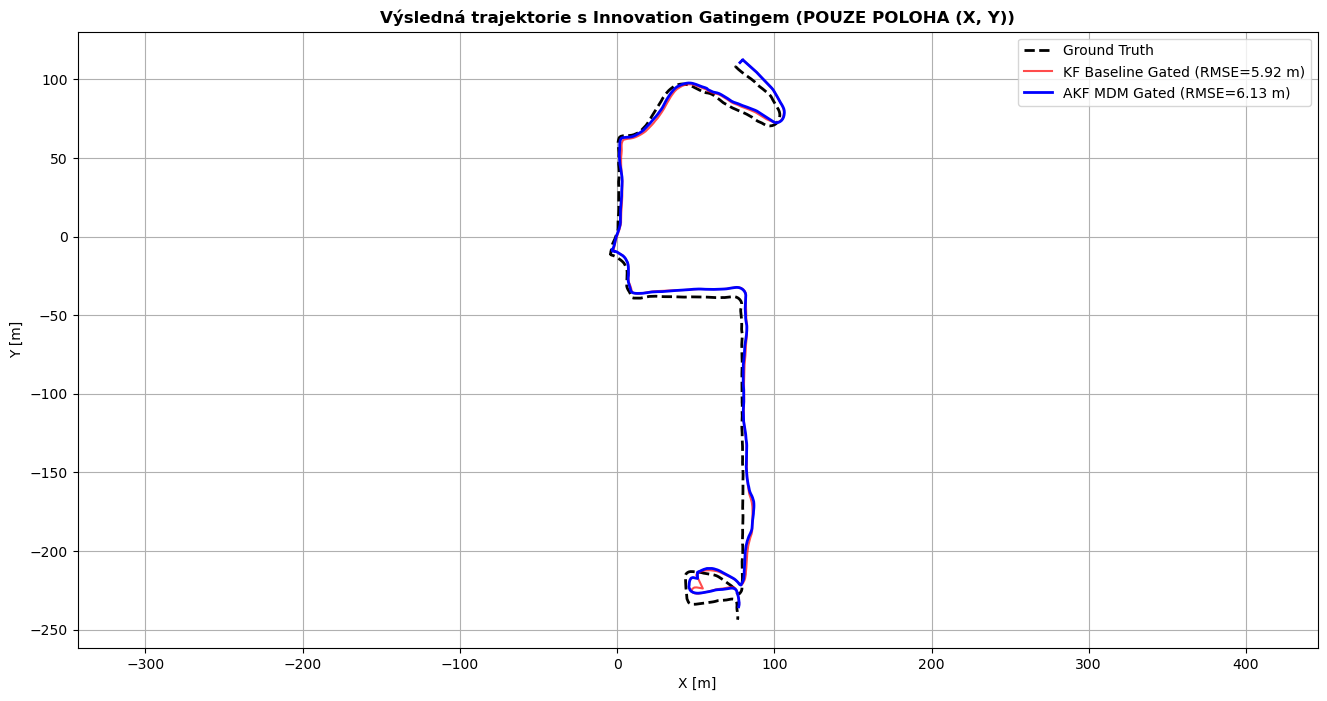

In [38]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from MDM.MDM_functions import MDM_nullO_LTI, Ksi_fun, baseMatrix_fun, Upsilon_2_fun, kron2_vec, kron2_mat

# Vynutíme CPU
device = torch.device("cpu")
print(f"Běžím na zařízení: {device}")

# ==============================================================================
# 0. KONFIGURACE VYHODNOCENÍ
# ==============================================================================
# True = Počítá MSE, RMSE a ANEES POUZE pro polohu (X a Y). 
# False = Počítá MSE, RMSE a ANEES pro celý vektor (X, Vx, Y, Vy).
EVALUATE_POSITION_ONLY = True 
# ==============================================================================

# ==============================================================================
# 1. UPRAVENÉ TŘÍDY FILTRŮ PŘÍMO VE SKRIPTU (S PARCIÁLNÍM INNOVATION GATINGEM)
# ==============================================================================
class KalmanFilterGated:
    def __init__(self, model):
        self.device = model.Q.device
        self.dtype = model.F.dtype
        self.model = model
        self.F, self.H, self.Q, self.R = model.F, model.H, model.Q, model.R
        self.state_dim = self.F.shape[0]
        self.obs_dim = self.H.shape[0]
        self.I = torch.eye(self.state_dim, device=self.device, dtype=self.dtype)
        self.reset(model.Ex0, model.P0)

    def reset(self, Ex0, P0):
        # Ex0 je nyní dynamicky předáváno na začátku každé sekvence
        self.x_predict_current = Ex0.clone().detach().reshape(self.state_dim, 1)
        self.P_predict_current = P0.clone().detach()

    def step(self, y_t, gate_threshold=9.21): # 9.21 = Chi-Sq 99% limit pro 2 DOF
        rejected = False
        if y_t is not None:
            y_t_vec = y_t.reshape(self.obs_dim, 1)
            inov = y_t_vec - self.H @ self.x_predict_current
            S = self.H @ self.P_predict_current @ self.H.T + self.R
            S_inv = torch.linalg.inv(S)
            
            # --- PARCIÁLNÍ GATING (Pouze na pozici X a Y) ---
            # X je index 0, Y je index 2
            inov_gps = torch.cat([inov[0:1], inov[2:3]], dim=0) # [2, 1]
            
            S_gps = torch.zeros((2, 2), device=self.device, dtype=self.dtype)
            S_gps[0, 0] = S[0, 0]; S_gps[0, 1] = S[0, 2]
            S_gps[1, 0] = S[2, 0]; S_gps[1, 1] = S[2, 2]
            
            S_gps_inv = torch.linalg.inv(S_gps)
            mah_sq_gps = (inov_gps.T @ S_gps_inv @ inov_gps).item()
            
            if mah_sq_gps > gate_threshold:
                rejected = True

        if y_t is None or rejected:
            # PREDICT ONLY (Měření zahozeno nebo chybí)
            x_filtered = self.x_predict_current
            P_filtered = self.P_predict_current
            K = torch.zeros((self.state_dim, self.obs_dim), device=self.device, dtype=self.dtype)
        else:
            # STANDARD UPDATE
            K = self.P_predict_current @ self.H.T @ S_inv
            x_filtered = self.x_predict_current + K @ inov
            I_KH = self.I - K @ self.H
            P_filtered = I_KH @ self.P_predict_current @ I_KH.T + K @ self.R @ K.T

        # PREDICT PRO DALŠÍ KROK
        x_predict_next = self.F @ x_filtered
        P_predict_next = self.F @ P_filtered @ self.F.T + self.Q
        
        self.x_predict_current = x_predict_next
        self.P_predict_current = P_predict_next

        return x_filtered, P_filtered, K, rejected

    def process_sequence(self, y_seq, Ex0, P0, gate_threshold=9.21):
        seq_len = y_seq.shape[0]
        self.reset(Ex0, P0)
        x_hist = torch.zeros(seq_len, self.state_dim, device=self.device, dtype=self.dtype)
        P_hist = torch.zeros(seq_len, self.state_dim, self.state_dim, device=self.device, dtype=self.dtype)
        
        for k in tqdm(range(seq_len), desc="Standard KF Gated", leave=False):
            x_f, P_f, _, _ = self.step(y_seq[k], gate_threshold)
            x_hist[k] = x_f.squeeze()
            P_hist[k] = P_f
            
        return {'x_filtered': x_hist, 'P_filtered': P_hist}


class AdaptiveKalmanFilter_online_Gated:
    def __init__(self, model, mdm_L=6, mdm_version=1, lambda_rls=0.99, init_sigma_rls_value=0.1, alpha_nom=None):
        self.kf = KalmanFilterGated(model)
        self.device, self.dtype = model.Q.device, model.Q.dtype
        self.np_dtype = np.float32 if self.dtype == torch.float32 else np.float64
        self.mdm_L, self.mdm_version, self.lambda_rls = mdm_L, mdm_version, lambda_rls
        self.nw, self.nv = self.kf.F.shape[0], self.kf.H.shape[0]
        
        self.F_np = self.kf.F.cpu().numpy().astype(self.np_dtype)
        self.H_np = self.kf.H.cpu().numpy().astype(self.np_dtype)
        self.E_np = np.eye(self.nw, dtype=self.np_dtype)
        self.D_np = np.eye(self.nv, dtype=self.np_dtype)
        self.nz_np = np.array([self.nv])
        
        self.Ksi, self.H_rls_norm, self.weights, self.HTH, self.HT = None, None, None, None, None
        
        T = 1.0
        self.Q_template = np.array([[T**3/3, T**2/2, 0, 0], [T**2/2, T, 0, 0], [0, 0, T**3/3, T**2/2], [0, 0, T**2/2, T]], dtype=self.np_dtype)
        self.vec_Q_template = self.Q_template[np.triu_indices(self.nw)][:, np.newaxis]
        self.n_params_Q_full, self.n_params_Q_reduced = (self.nw * (self.nw + 1)) // 2, 1
        self.n_params_R_full, self.n_params_R_reduced = (self.nv * (self.nv + 1)) // 2, 2
        
        self.T_R_matrix = np.zeros((self.n_params_R_full, self.n_params_R_reduced), dtype=self.np_dtype)
        self.T_R_matrix[0, 0] = self.T_R_matrix[7, 0] = self.T_R_matrix[4, 1] = self.T_R_matrix[9, 1] = 1.0 
        
        Q0, R0 = model.Q.cpu().numpy(), model.R.cpu().numpy()
        self.alpha_est = np.array([Q0[0,0] / self.Q_template[0,0], R0[0,0], R0[1,1]], dtype=self.np_dtype)
        self.alpha_nom = np.array(alpha_nom, dtype=self.np_dtype)

        sigma_q = (self.alpha_nom[0] * init_sigma_rls_value)**2 + 1e-12
        sigma_r1 = (self.alpha_nom[1] * init_sigma_rls_value)**2 + 1e-12
        sigma_r2 = (self.alpha_nom[2] * init_sigma_rls_value)**2 + 1e-12
        self.Sigma_RLS = np.diag([sigma_q, sigma_r1, sigma_r2]).astype(self.np_dtype)
        
        self.z_buffer, self.u_buffer = [], []
        self.Upsilon_2 = None

    def _get_upsilon(self):
        if self.Upsilon_2 is None:
            w2b, v2b = [baseMatrix_fun(self.nw, 1)], [baseMatrix_fun(self.nv, 1)]
            self.Upsilon_2 = Upsilon_2_fun(w2b, v2b, self.mdm_L)
        return self.Upsilon_2

    def step_adaptive(self, y_t, gate_threshold=9.21):
        x_filt, P_filt, K, rejected = self.kf.step(y_t, gate_threshold)
        
        if rejected:
            self.z_buffer = []
            self.u_buffer = []
            return x_filt, P_filt, K, self.kf.Q, self.kf.R

        y_np = y_t.cpu().numpy().squeeze()
        if y_np.ndim == 0: y_np = np.expand_dims(y_np, axis=0)
        u_np = np.zeros(1, dtype=self.np_dtype)

        self.z_buffer.append(y_np)
        self.u_buffer.append(u_np)
        
        if len(self.z_buffer) > self.mdm_L:
            self.z_buffer.pop(0)
            self.u_buffer.pop(0)

        if len(self.z_buffer) == self.mdm_L:
            try:
                z_window = np.array(self.z_buffer, dtype=self.np_dtype)
                u_window = np.array(self.u_buffer, dtype=self.np_dtype)
                G_np = np.zeros((self.nw, 1), dtype=self.np_dtype)

                r_list, Awv_matrix = MDM_nullO_LTI(self.mdm_L, self.F_np, G_np, self.E_np, self.nz_np, self.H_np, self.D_np, z_window, u_window, self.mdm_version)
                r_k = r_list[0]
                
                if self.H_rls_norm is None:
                    self.Ksi = Ksi_fun(r_k.shape[0])
                    H_full = self.Ksi @ kron2_mat(Awv_matrix) @ self._get_upsilon()
                    H_rls = np.hstack([H_full[:, :self.n_params_Q_full] @ self.vec_Q_template, H_full[:, self.n_params_Q_full:] @ self.T_R_matrix])
                    self.weights = np.abs(H_rls @ self.alpha_nom).flatten() + 1e-12
                    self.H_rls_norm = H_rls / self.weights[:, np.newaxis]
                    self.HT = self.H_rls_norm.T
                    self.HTH = self.HT @ self.H_rls_norm

                y_rls_norm = (self.Ksi @ kron2_vec(r_k)).flatten() / self.weights
                
                P_next_unscaled = np.linalg.inv(np.linalg.inv(self.Sigma_RLS) + self.HTH)
                self.Sigma_RLS = P_next_unscaled / self.lambda_rls
                self.alpha_est += (P_next_unscaled @ self.HT) @ (y_rls_norm - self.H_rls_norm @ self.alpha_est)
                
                Q_new = max(self.alpha_est[0], 1e-10) * self.Q_template
                r1, r2 = max(self.alpha_est[1], 1e-10), max(self.alpha_est[2], 1e-10)
                R_new = np.diag([r1, r2, r1, r2])
                
                self.kf.Q = torch.from_numpy(Q_new).to(self.device).to(self.dtype)
                self.kf.R = torch.from_numpy(R_new).to(self.device).to(self.dtype)
                
            except Exception as e:
                pass

        return x_filt, P_filt, K, self.kf.Q, self.kf.R

    def process_sequence_adaptively(self, y_seq, Ex0, P0, gate_threshold=9.21):
        seq_len = y_seq.shape[0]
        self.kf.reset(Ex0, P0)
        self.z_buffer, self.u_buffer = [], []
        x_hist = torch.zeros(seq_len, self.nw, device=self.device, dtype=self.dtype)
        P_hist = torch.zeros(seq_len, self.nw, self.nw, device=self.device, dtype=self.dtype)
        Q_hist, R_hist = [], []

        for k in tqdm(range(seq_len), desc="AKF MDM Gated", leave=False):
            x, P, K, Q_curr, R_curr = self.step_adaptive(y_seq[k], gate_threshold)
            x_hist[k], P_hist[k] = x.squeeze(), P
            Q_hist.append(Q_curr.clone().detach())
            R_hist.append(R_curr.clone().detach())
            
        return {'x_filtered': x_hist, 'P_filtered': P_hist}, Q_hist, R_hist

# ==============================================================================
# 2. DEFINICE SYSTÉMU A NAČTENÍ DAT
# ==============================================================================
import Systems

m = 4; n = 4; delta_t = 1.0 
F_dim = torch.tensor([[1.0, delta_t], [0.0, 1.0]], dtype=torch.float64)
F_design = torch.block_diag(F_dim, F_dim).to(device)
H_design = torch.eye(n, dtype=torch.float64).to(device)

q_scale_init, var_gps_init, var_odo_init = 0.000132, 39.32, 0.00057
Q_block_val = torch.tensor([[(delta_t**3)/3, (delta_t**2)/2], [(delta_t**2)/2,  delta_t]], dtype=torch.float64) * q_scale_init
Q_design = torch.block_diag(Q_block_val, Q_block_val).to(device)
R_design = torch.diag(torch.tensor([var_gps_init, var_odo_init, var_gps_init, var_odo_init], dtype=torch.float64)).to(device)

# Počáteční podmínky (Dummy pro systém, při spuštění se přepíší přesnými)
m1x_0 = torch.zeros(m, 1, dtype=torch.float64).to(device)
m2x_0 = torch.diag(torch.tensor([10.0, 1.0, 10.0, 1.0], dtype=torch.float64)).to(device)

sys_model = Systems.DynamicSystem(state_dim=m, obs_dim=n, Ex0=m1x_0, P0=m2x_0, Q=Q_design, R=R_design, F=F_design, H=H_design, device=device)

# --- NAČTENÍ DAT (Spojení Train a Val) ---
train_path = '../preprocessed_NCLT_trajectory-2012-01-22-angle-update/train.pt' 
val_path = '../preprocessed_NCLT_trajectory-2012-01-22-angle-update/val.pt' 
test_path = '../preprocessed_NCLT_trajectory-2012-01-22-angle-update/test.pt' 

train_gt_raw = torch.load(train_path)[0]['ground_truth'].to(device).double()
train_meas_raw = torch.load(train_path)[0]['filtered_gps'].to(device).double()

val_gt_raw = torch.load(val_path)[0]['ground_truth'].to(device).double()
val_meas_raw = torch.load(val_path)[0]['filtered_gps'].to(device).double()

test_gt = torch.load(test_path)[0]['ground_truth'].to(device).double()
test_meas = torch.load(test_path)[0]['filtered_gps'].to(device).double()

# SPOJENÍ TRAIN A VAL
train_gt = torch.cat((train_gt_raw, val_gt_raw), dim=0)
train_meas = torch.cat((train_meas_raw, val_meas_raw), dim=0)

print(f"Délka spojené trénovací trasy (Train+Val): {len(train_meas)} kroků")
print(f"Délka testovací trasy: {len(test_meas)} kroků")

m1x_0_train = train_gt[0].unsqueeze(1)
m1x_0_test = test_gt[0].unsqueeze(1)

# ==============================================================================
# 3. FÁZE TRÉNINKU (NA CELÉ SPOJENÉ SADĚ)
# ==============================================================================
print("\n--- FÁZE 1: UČENÍ NA KOMPLETNÍCH DATECH (Train + Val s Gatingem) ---")
T_sampling = 1.0
template_val_00 = (T_sampling**3) / 3.0
NUM_EPOCHS = 10
current_alpha = [q_scale_init, var_gps_init, var_odo_init]

for epoch in range(NUM_EPOCHS):
    print(f"Epocha {epoch+1}/{NUM_EPOCHS}...")
    akf_train = AdaptiveKalmanFilter_online_Gated(
        sys_model, mdm_L=8, lambda_rls=0.999, init_sigma_rls_value=0.1, alpha_nom=current_alpha
    )
    
    _, Q_hist_tr, R_hist_tr = akf_train.process_sequence_adaptively(train_meas, Ex0=m1x_0_train, P0=m2x_0, gate_threshold=50.0)
    
    current_alpha = [
        Q_hist_tr[-1][0, 0].item() / template_val_00,
        R_hist_tr[-1][0, 0].item(),
        R_hist_tr[-1][1, 1].item()
    ]

baseline_q, baseline_r_gps, baseline_r_odo = current_alpha
print("\n🌟 ZLATÝ STANDARD NALEZEN PŘÍMO Z HRUBÝCH DAT 🌟")
print(f"Q (scale): {baseline_q:.6f}")
print(f"R (GPS):   {baseline_r_gps:.4f}")
print(f"R (ODO):   {baseline_r_odo:.6f}")

# Aktualizace modelu
Q_block_new = torch.tensor([[(delta_t**3)/3, (delta_t**2)/2], [(delta_t**2)/2,  delta_t]], dtype=torch.float64) * baseline_q
sys_model.Q = torch.block_diag(Q_block_new, Q_block_new).to(device)
sys_model.R = torch.diag(torch.tensor([baseline_r_gps, baseline_r_odo, baseline_r_gps, baseline_r_odo], dtype=torch.float64)).to(device)

# ==============================================================================
# 4. FÁZE TESTOVÁNÍ NA OSTRÝCH DATECH 
# ==============================================================================
print("\n--- FÁZE 2: TESTOVÁNÍ NA OSTRÉ TRAJEKTORII ---")

print("Spouštím Standardní KF Baseline (s Gatingem)...")
kf_baseline = KalmanFilterGated(sys_model)
res_kf = kf_baseline.process_sequence(test_meas, Ex0=m1x_0_test, P0=m2x_0, gate_threshold=9.21)

print("Spouštím AKF MDM (s Gatingem)...")
akf_filter = AdaptiveKalmanFilter_online_Gated(
    sys_model, mdm_L=8, lambda_rls=1.0, init_sigma_rls_value=0.01, alpha_nom=current_alpha
)
res_akf, Q_hist_test, R_hist_test = akf_filter.process_sequence_adaptively(test_meas, Ex0=m1x_0_test, P0=m2x_0, gate_threshold=9.21)

# ==============================================================================
# 5. VYHODNOCENÍ METRIK (S PŘEPÍNAČEM) A VIZUALIZACE
# ==============================================================================
x_est_kf = res_kf['x_filtered'].detach().cpu().numpy()
P_est_kf = res_kf['P_filtered'].detach().cpu().numpy()

x_est_akf = res_akf['x_filtered'].detach().cpu().numpy()
P_est_akf = res_akf['P_filtered'].detach().cpu().numpy()

gt_test_np = test_gt.detach().cpu().numpy()

# Dynamický výpočet MSE, RMSE a ANEES podle přepínače
def calc_metrics_dynamic(est, P_est, gt):
    # Pro korektní výpočet ANEES přeskakujeme nultý krok (inicializaci)
    est_eval = est[1:]
    gt_eval = gt[1:]
    P_eval = P_est[1:]
    
    if EVALUATE_POSITION_ONLY:
        # 1. MSE a RMSE pouze pro polohu (X a Y)
        mse_x = np.mean((est_eval[:, 0] - gt_eval[:, 0])**2)
        mse_y = np.mean((est_eval[:, 2] - gt_eval[:, 2])**2)
        total_mse = mse_x + mse_y
        
        # 2. ANEES pouze pro polohu
        err = np.stack([est_eval[:, 0] - gt_eval[:, 0], est_eval[:, 2] - gt_eval[:, 2]], axis=1) # [N, 2]
        
        # Vytěžení 2x2 submatice z P_filtered pro X a Y (indexy 0 a 2)
        P_pos = np.zeros((len(P_eval), 2, 2))
        P_pos[:, 0, 0] = P_eval[:, 0, 0]
        P_pos[:, 0, 1] = P_eval[:, 0, 2]
        P_pos[:, 1, 0] = P_eval[:, 2, 0]
        P_pos[:, 1, 1] = P_eval[:, 2, 2]
        
        anees_vals = []
        for t in range(len(err)):
            try:
                inv_P = np.linalg.inv(P_pos[t])
                anees_vals.append(err[t].T @ inv_P @ err[t])
            except np.linalg.LinAlgError:
                pass # Pokud matice P není invertibilní
        anees = np.mean(anees_vals) if anees_vals else np.nan
        
    else:
        # 1. MSE a RMSE pro celý stavový vektor (X, Vx, Y, Vy)
        mse_x = np.mean((est_eval[:, 0] - gt_eval[:, 0])**2)
        mse_vx = np.mean((est_eval[:, 1] - gt_eval[:, 1])**2)
        mse_y = np.mean((est_eval[:, 2] - gt_eval[:, 2])**2)
        mse_vy = np.mean((est_eval[:, 3] - gt_eval[:, 3])**2)
        total_mse = mse_x + mse_vx + mse_y + mse_vy
        
        # 2. ANEES pro celý stavový vektor
        err = est_eval - gt_eval # [N, 4]
        anees_vals = []
        for t in range(len(err)):
            try:
                inv_P = np.linalg.inv(P_eval[t])
                anees_vals.append(err[t].T @ inv_P @ err[t])
            except np.linalg.LinAlgError:
                pass
        anees = np.mean(anees_vals) if anees_vals else np.nan

    return total_mse, np.sqrt(total_mse), anees

# Výpočet pro KF a AKF
mse_kf, rmse_kf, anees_kf = calc_metrics_dynamic(x_est_kf, P_est_kf, gt_test_np)
mse_akf, rmse_akf, anees_akf = calc_metrics_dynamic(x_est_akf, P_est_akf, gt_test_np)

print("\n" + "="*80)
eval_mode_str = "POUZE POLOHA (X, Y)" if EVALUATE_POSITION_ONLY else "CELÝ STAV (X, Vx, Y, Vy)"
target_anees = 2.0 if EVALUATE_POSITION_ONLY else float(m)
print(f"VÝSLEDKY NA TESTOVACÍ TRAJEKTORII - Režim: {eval_mode_str}")
print("="*80)
print(f"Cílové (Ideální) ANEES: ≈ {target_anees:.2f}")
print("-" * 80)
print(f"Standardní KF Gated (Baseline)  -> MSE: {mse_kf:8.4f} | RMSE: {rmse_kf:8.4f} m | ANEES: {anees_kf:8.4f}")
print(f"AKF MDM Gated (Adaptivní)       -> MSE: {mse_akf:8.4f} | RMSE: {rmse_akf:8.4f} m | ANEES: {anees_akf:8.4f}")
print("="*80)

# Vykreslení
fig = plt.figure(figsize=(16, 8))
plt.plot(gt_test_np[:, 0], gt_test_np[:, 2], 'k--', label='Ground Truth', linewidth=2)
plt.plot(x_est_kf[:, 0], x_est_kf[:, 2], 'r-', label=f'KF Baseline Gated (RMSE={rmse_kf:.2f} m)', alpha=0.7)
plt.plot(x_est_akf[:, 0], x_est_akf[:, 2], 'b-', label=f'AKF MDM Gated (RMSE={rmse_akf:.2f} m)', linewidth=2)
plt.title(f'Výsledná trajektorie s Innovation Gatingem ({eval_mode_str})', fontweight='bold')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()